# 1. Data Visualization

In [1]:
# link: https://pubmed.ncbi.nlm.nih.gov/31467953/

In [2]:
import pandas as pd

In [3]:
obesity = pd.read_csv("obesity.csv")

In [4]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
obesity.Gender.value_counts()

Gender
Male      1068
Female    1043
Name: count, dtype: int64

In [6]:
obesity.family_history_with_overweight.value_counts()

family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

In [7]:
obesity.CAEC.value_counts()

CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

In [8]:
obesity.SMOKE.value_counts()

SMOKE
no     2067
yes      44
Name: count, dtype: int64

In [9]:
obesity.SCC.value_counts()

SCC
no     2015
yes      96
Name: count, dtype: int64

In [10]:
obesity.CALC.value_counts()

CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

In [11]:
obesity.MTRANS.value_counts()

MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

In [12]:
obesity.NObeyesdad.value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [13]:
obesity.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

# 2. Data Analysis

## 2.1. Import libraries

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

## 2.2. Map target label

In [15]:
# change the target name from "NObeyesdad" to "target"
obesity.rename(columns={"NObeyesdad": "Target"}, inplace=True)

target_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}

obesity["Target"] = obesity["Target"].map(target_map)

## 2.3. Define features and target

In [16]:
X = obesity.drop(columns=['Target'])
y = obesity['Target']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

## 2.4. Divide to train test dataset

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 2.5 Create preprocessing data pipeline

In [18]:
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 2.6. Model pipeline

In [19]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

## 2.7. Train the modelcwith train dataset

In [20]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## 2.8. Evaluate the model with test dataset

In [21]:
y_pred = model.predict(X_test)

## 2.9  Confusion matrix as metrics for accuracy, f1, recall, precision


Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        54
           1       0.86      0.74      0.80        58
           2       0.73      0.76      0.75        58
           3       0.83      0.84      0.84        58
           4       0.92      0.84      0.88        70
           5       0.88      0.97      0.92        60
           6       0.97      0.98      0.98        65

    accuracy                           0.88       423
   macro avg       0.88      0.88      0.87       423
weighted avg       0.88      0.88      0.88       423

Accuracy: 0.8770685579196218


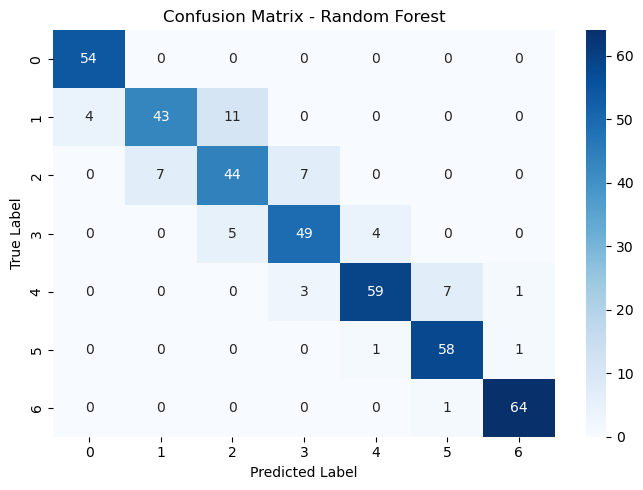

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Optional: Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 2.10. SHAP Analysis

### 2.10.1. import libraries nad setting publication grade images

In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

# Set publication-grade plot parameters
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 11
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['figure.dpi'] = 300

### 2.10.2. Define target names

In [24]:
class_names = [
    'Underweight',
    'Healthy', 
    'Overweight L1',
    'Overweight L2',
    'Obesity L1',
    'Obesity L2',
    'Obesity L3'
]

### 2.10.3. Data tranformations

In [25]:
# Step 1: Transform the data and get feature names
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Get feature names after transformation
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 
                       'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# Get categorical feature names after one-hot encoding
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Combine all feature names
feature_names = numerical_features + list(cat_feature_names)

# Convert to DataFrame for better handling
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

print(f"Total features after transformation: {len(feature_names)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features (after encoding): {len(cat_feature_names)}")

# Step 2: Create SHAP explainer
# For multiclass logistic regression, we use LinearExplainer directly with the model
print("\nCalculating SHAP values...")

Total features after transformation: 23
Numerical features: 8
Categorical features (after encoding): 15

Calculating SHAP values...


### 2.10.4. Multi class logistic regression

In [26]:
# Get the classifier
classifier = model.named_steps['classifier']

# For multiclass logistic regression, use a subset of training data as background
# Usingmasker for proper handling
background_data = shap.maskers.Independent(X_train_df, max_samples=100)

# Create LinearExplainer 
explainer = shap.LinearExplainer(classifier, background_data, feature_perturbation="interventional")

# Calculate SHAP values for test set
# This returns a list of length n_classes, each with shape (n_samples, n_features)
shap_values_raw = explainer.shap_values(X_test_df)

# Check what we got
print(f"Type of shap_values_raw: {type(shap_values_raw)}")
if isinstance(shap_values_raw, list):
    print(f"List length: {len(shap_values_raw)}")
    print(f"First element shape: {shap_values_raw[0].shape}")
    shap_values_list = shap_values_raw
elif isinstance(shap_values_raw, np.ndarray):
    print(f"Array shape: {shap_values_raw.shape}")
    # If it's (n_samples, n_features, n_classes), split it
    if len(shap_values_raw.shape) == 3:
        shap_values_list = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    # If it's (n_features, n_classes), transpose and split
    elif shap_values_raw.shape[0] == len(feature_names) and shap_values_raw.shape[1] == 7:
        # This means we got (n_features, n_classes) but need (n_samples, n_features) per class
        # Recalculate properly
        print("Recalculating with correct format...")
        explainer = shap.LinearExplainer(classifier, X_train_df.iloc[:100])
        shap_values_list = explainer.shap_values(X_test_df)
        print(f"After recalculation - List length: {len(shap_values_list)}, shape: {shap_values_list[0].shape}")
else:
    raise ValueError(f"Unexpected SHAP values type: {type(shap_values_raw)}")

print(f"Final format: {len(shap_values_list)} classes, each with shape {shap_values_list[0].shape}")

Type of shap_values_raw: <class 'numpy.ndarray'>
Array shape: (423, 23, 7)
Final format: 7 classes, each with shape (423, 23)


C:\Users\ekadw\anaconda3\envs\BookTimeSeries\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


### 2.10.5. Global feature importance


GENERATING GLOBAL FEATURE IMPORTANCE PLOTS


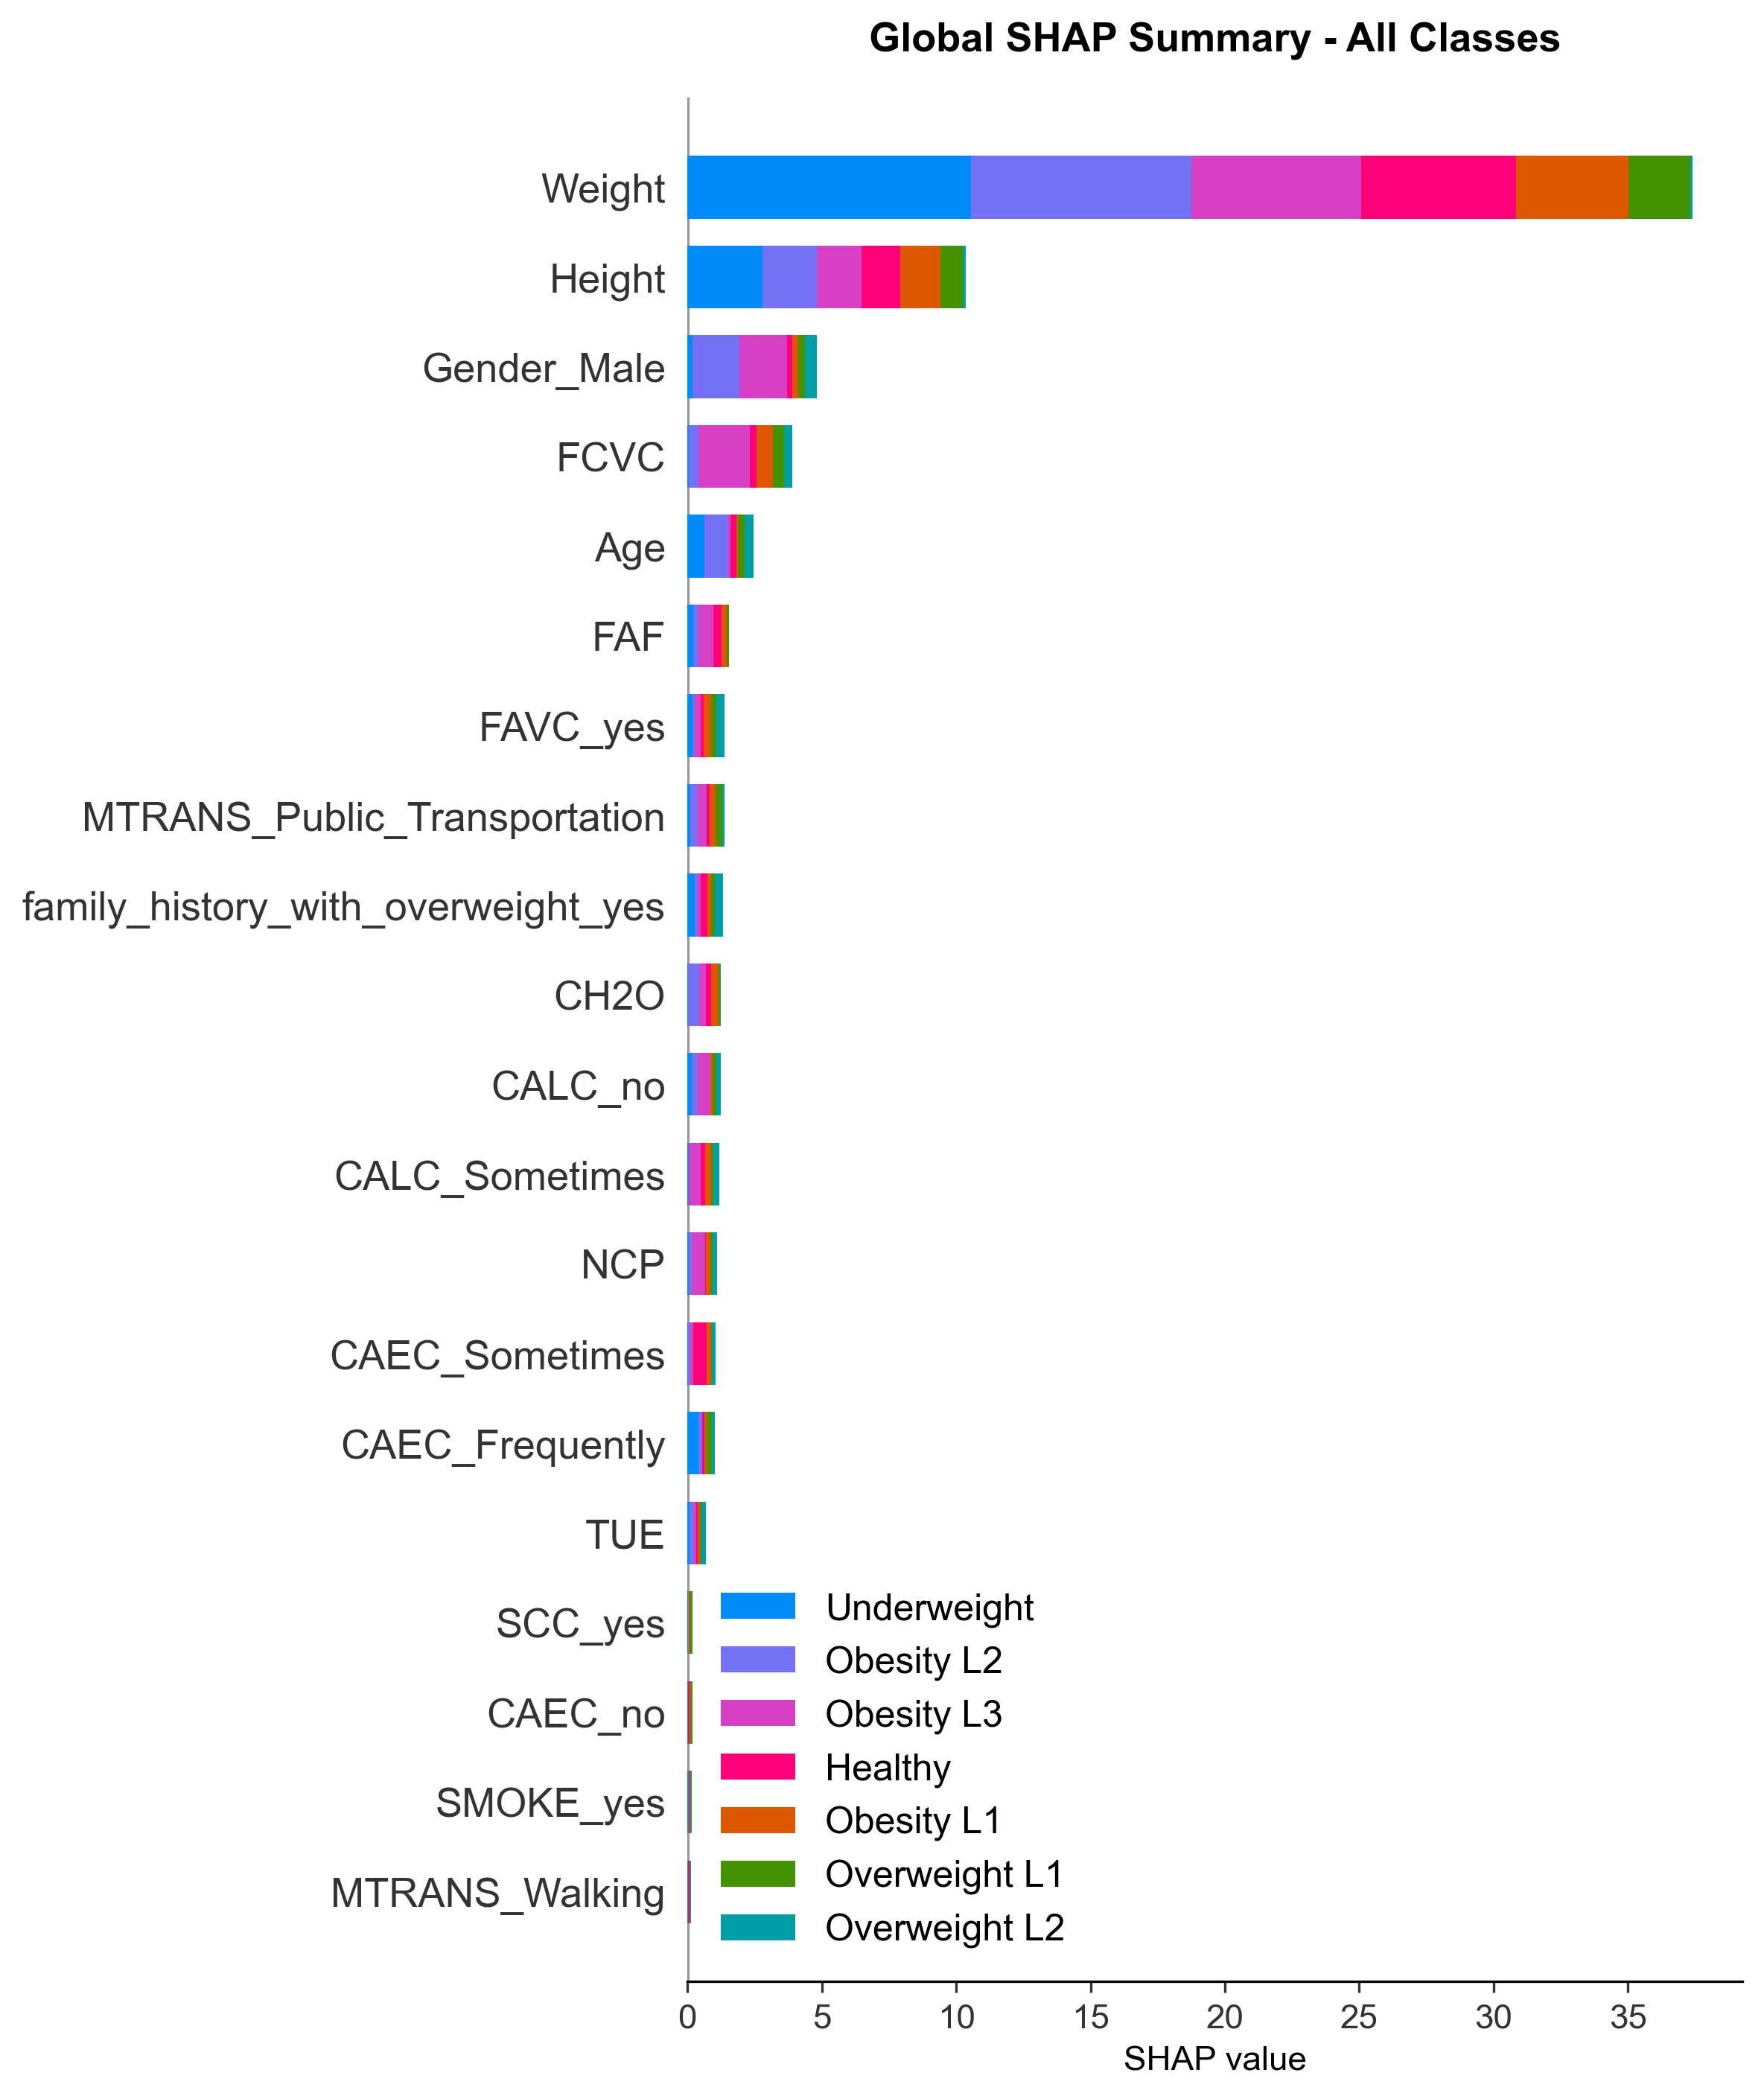

✓ Saved: shap_global_summary.png


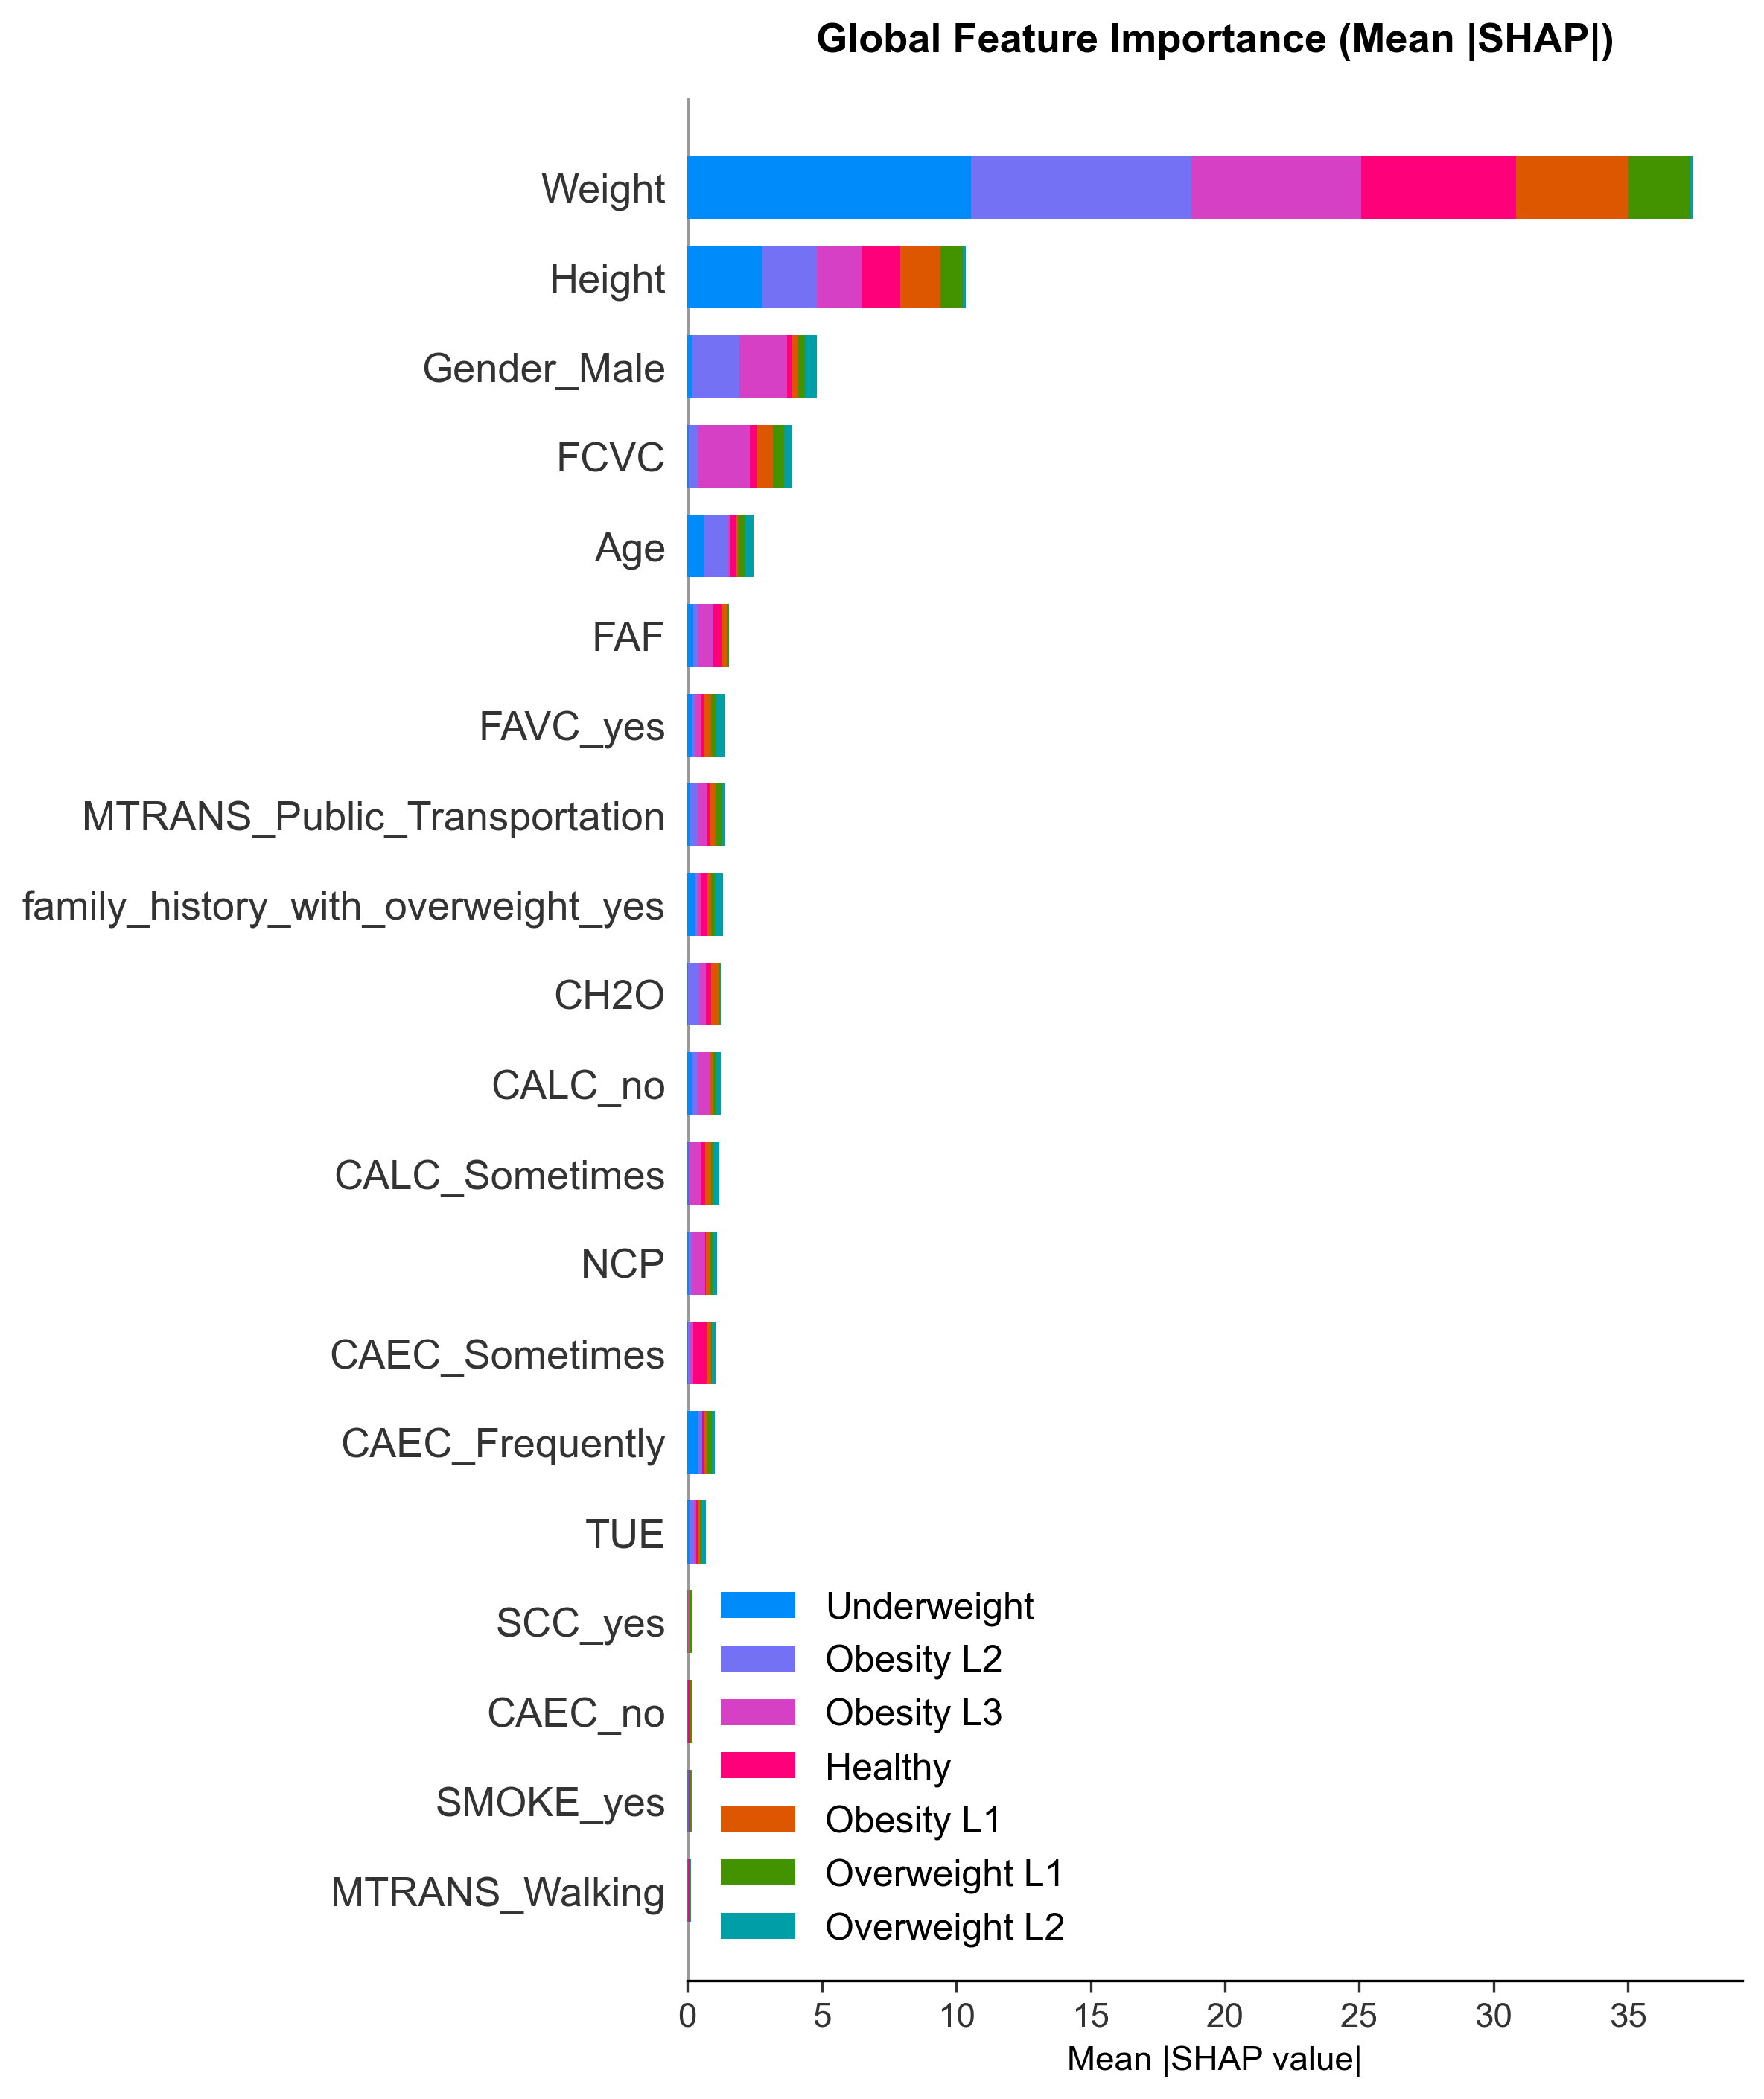

✓ Saved: shap_global_importance_bar.png


In [27]:
print("\n" + "="*80)
print("GENERATING GLOBAL FEATURE IMPORTANCE PLOTS")
print("="*80)

# Plot 1: Global summary plot (beeswarm) - shows feature importance across all classes
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values_list, 
    X_test_df,
    feature_names=feature_names,
    class_names=class_names,
    show=False,
    max_display=20
)
plt.title('Global SHAP Summary - All Classes', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('SHAP value', fontsize=11)
plt.tight_layout()
plt.savefig('shap_global_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_global_summary.png")

# Plot 2: Mean absolute SHAP values (bar plot) - overall feature importance
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values_list,
    X_test_df,
    feature_names=feature_names,
    plot_type="bar",
    class_names=class_names,
    show=False,
    max_display=20
)
plt.title('Global Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean |SHAP value|', fontsize=11)
plt.tight_layout()
plt.savefig('shap_global_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_global_importance_bar.png")

### 2.10.6. Per class SHAP analysis


GENERATING PER-CLASS SHAP PLOTS

Processing Class 0: Underweight


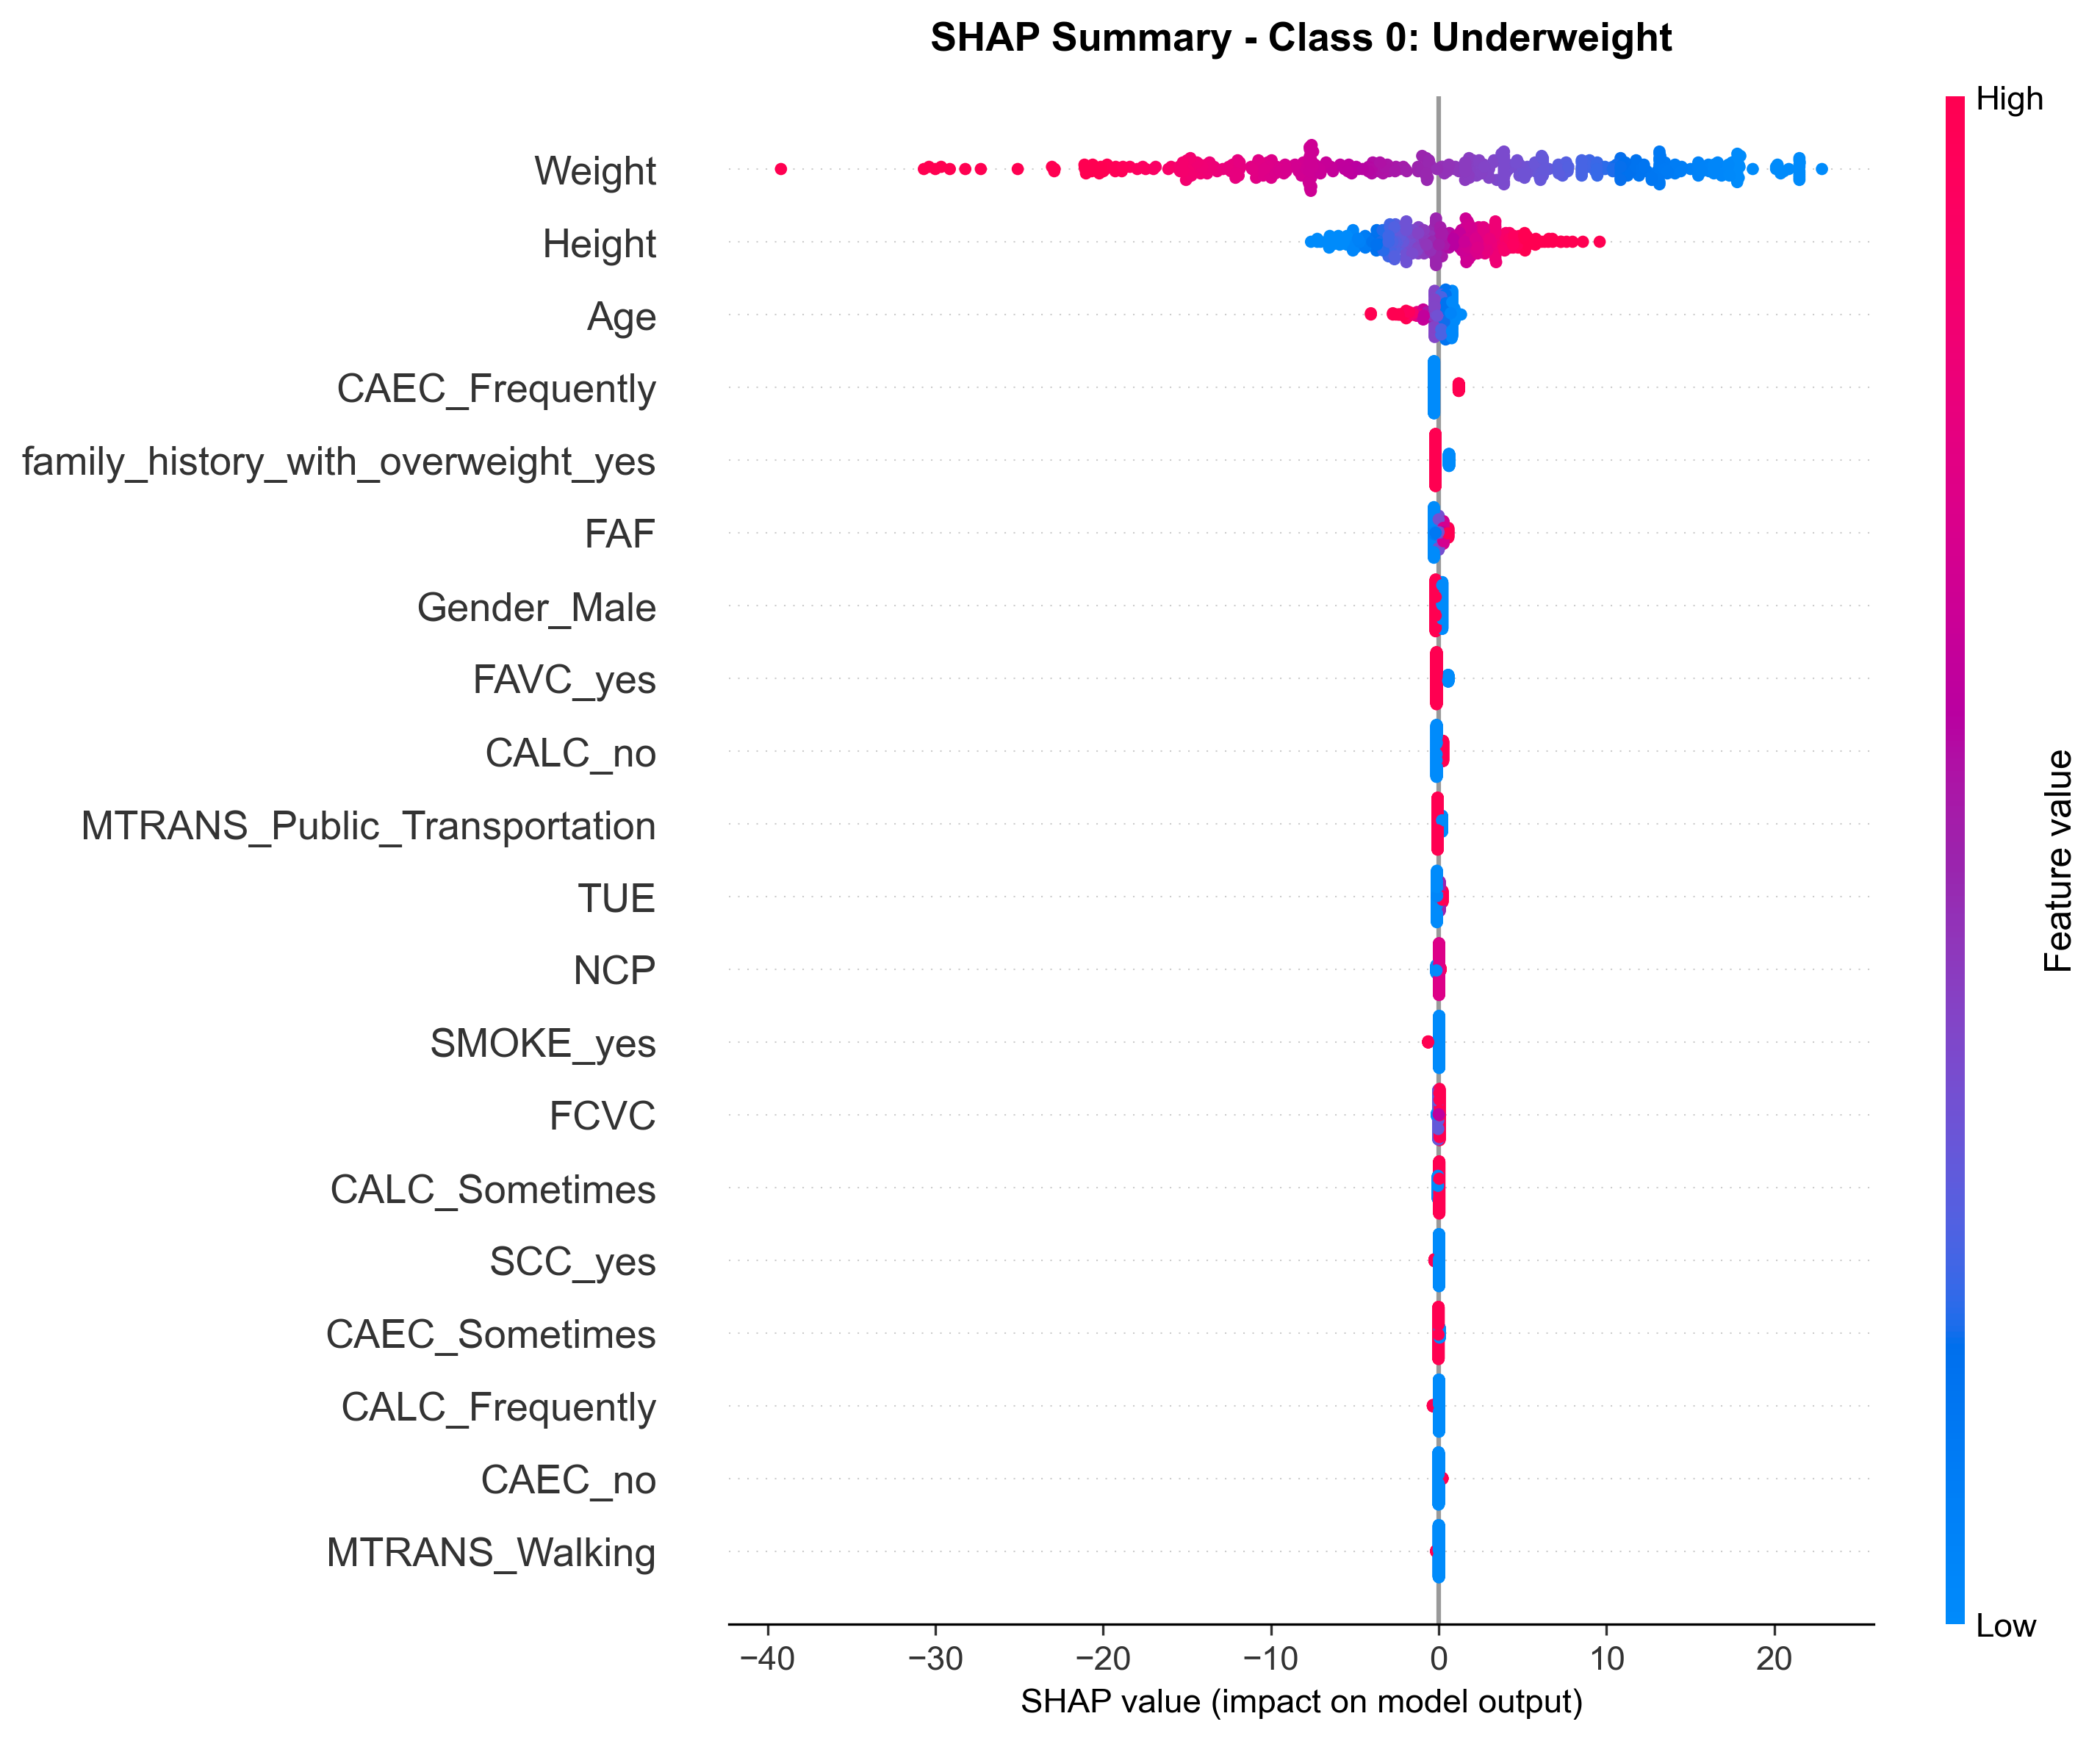

  ✓ Saved: shap_class_0_Underweight_summary.png


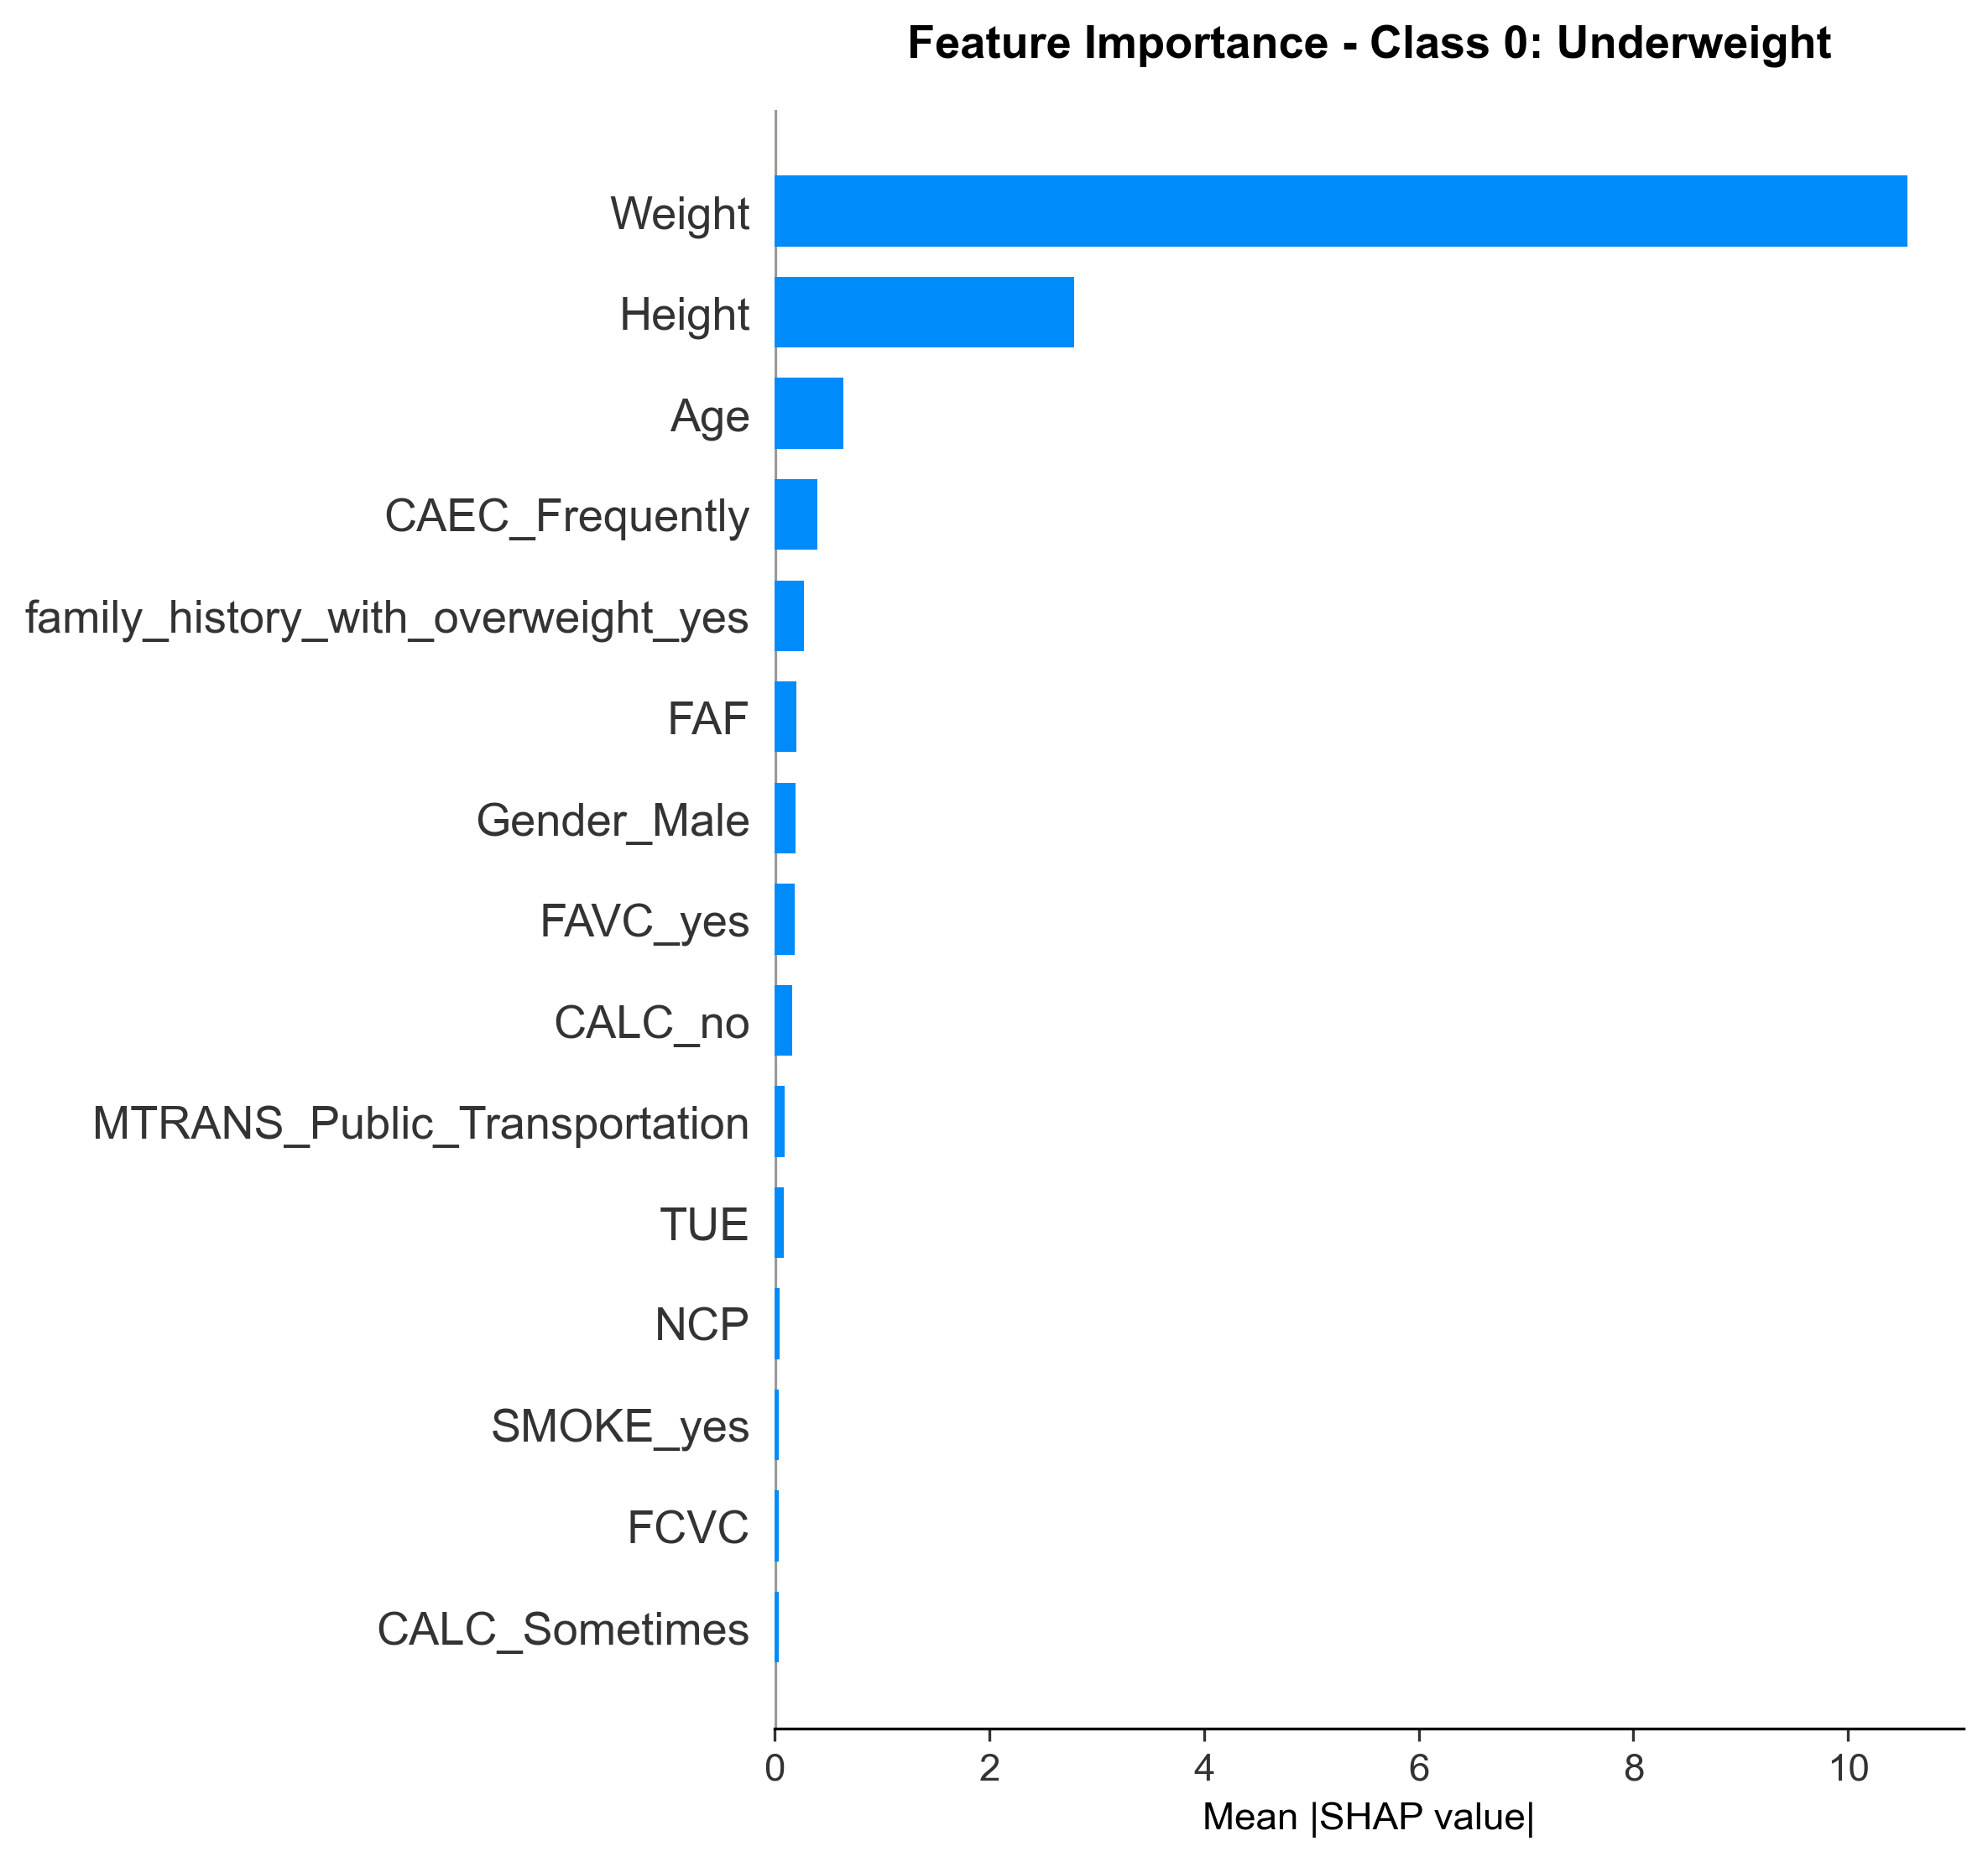

  ✓ Saved: shap_class_0_Underweight_bar.png

Processing Class 1: Healthy


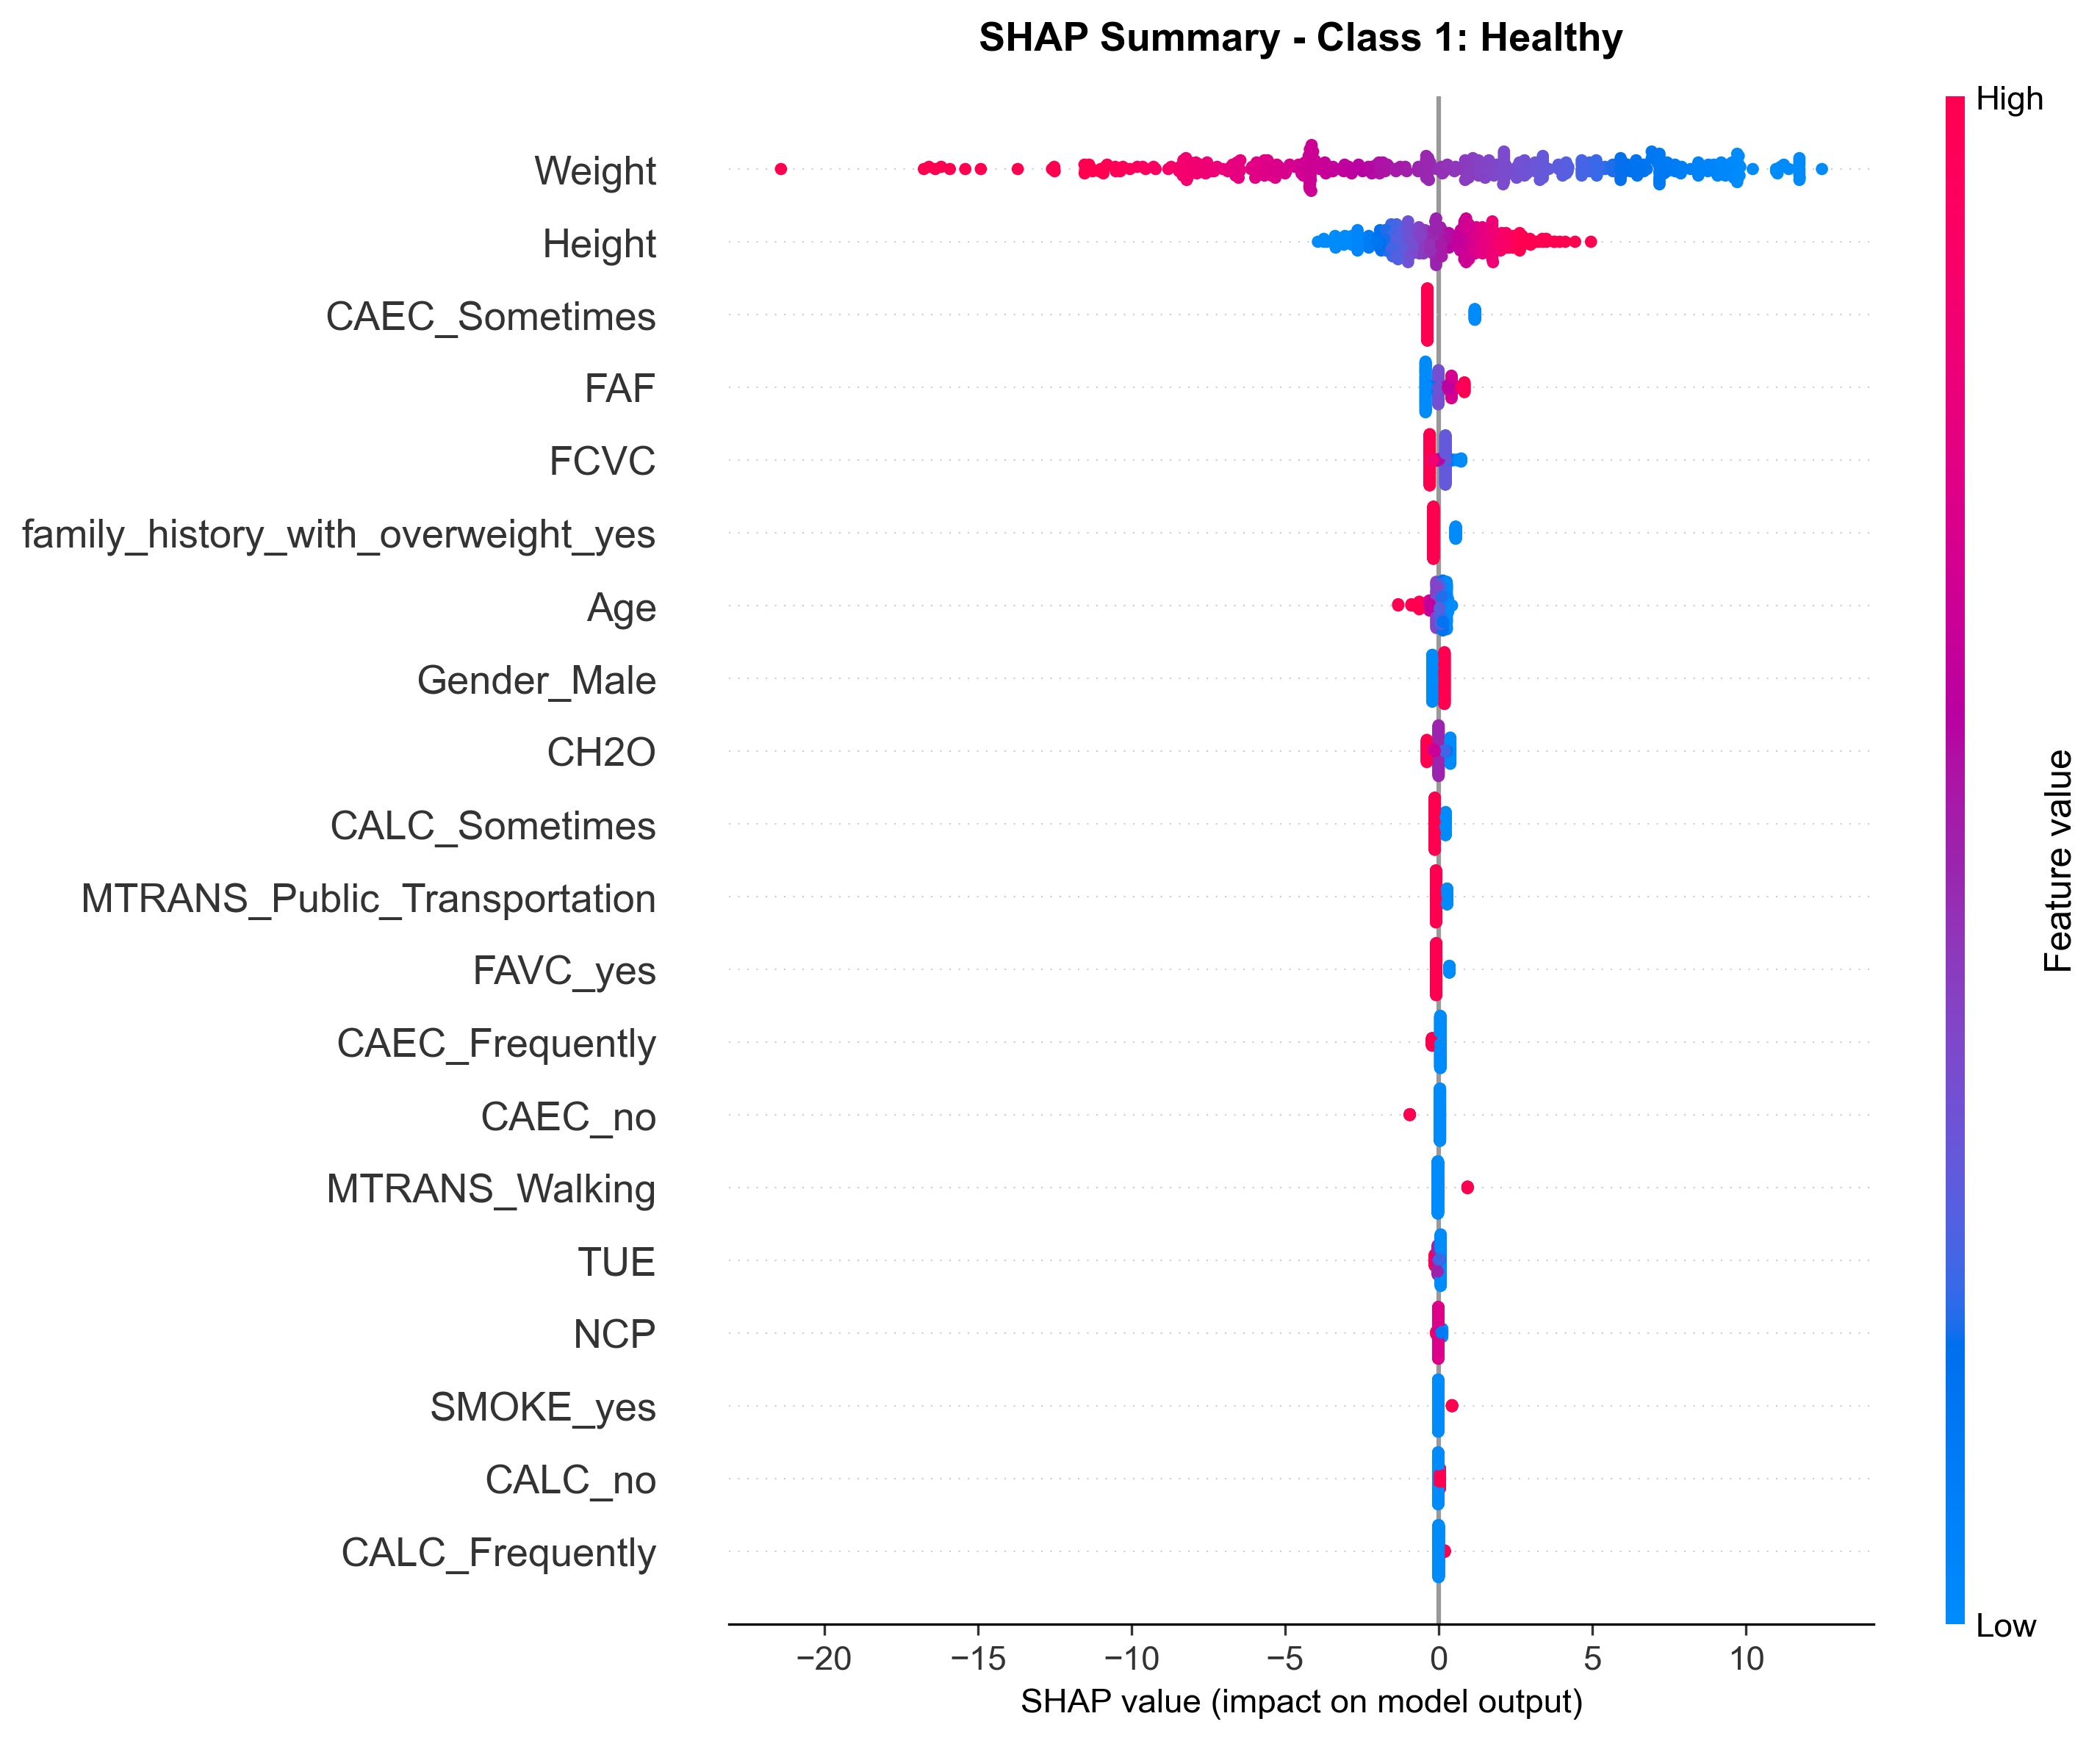

  ✓ Saved: shap_class_1_Healthy_summary.png


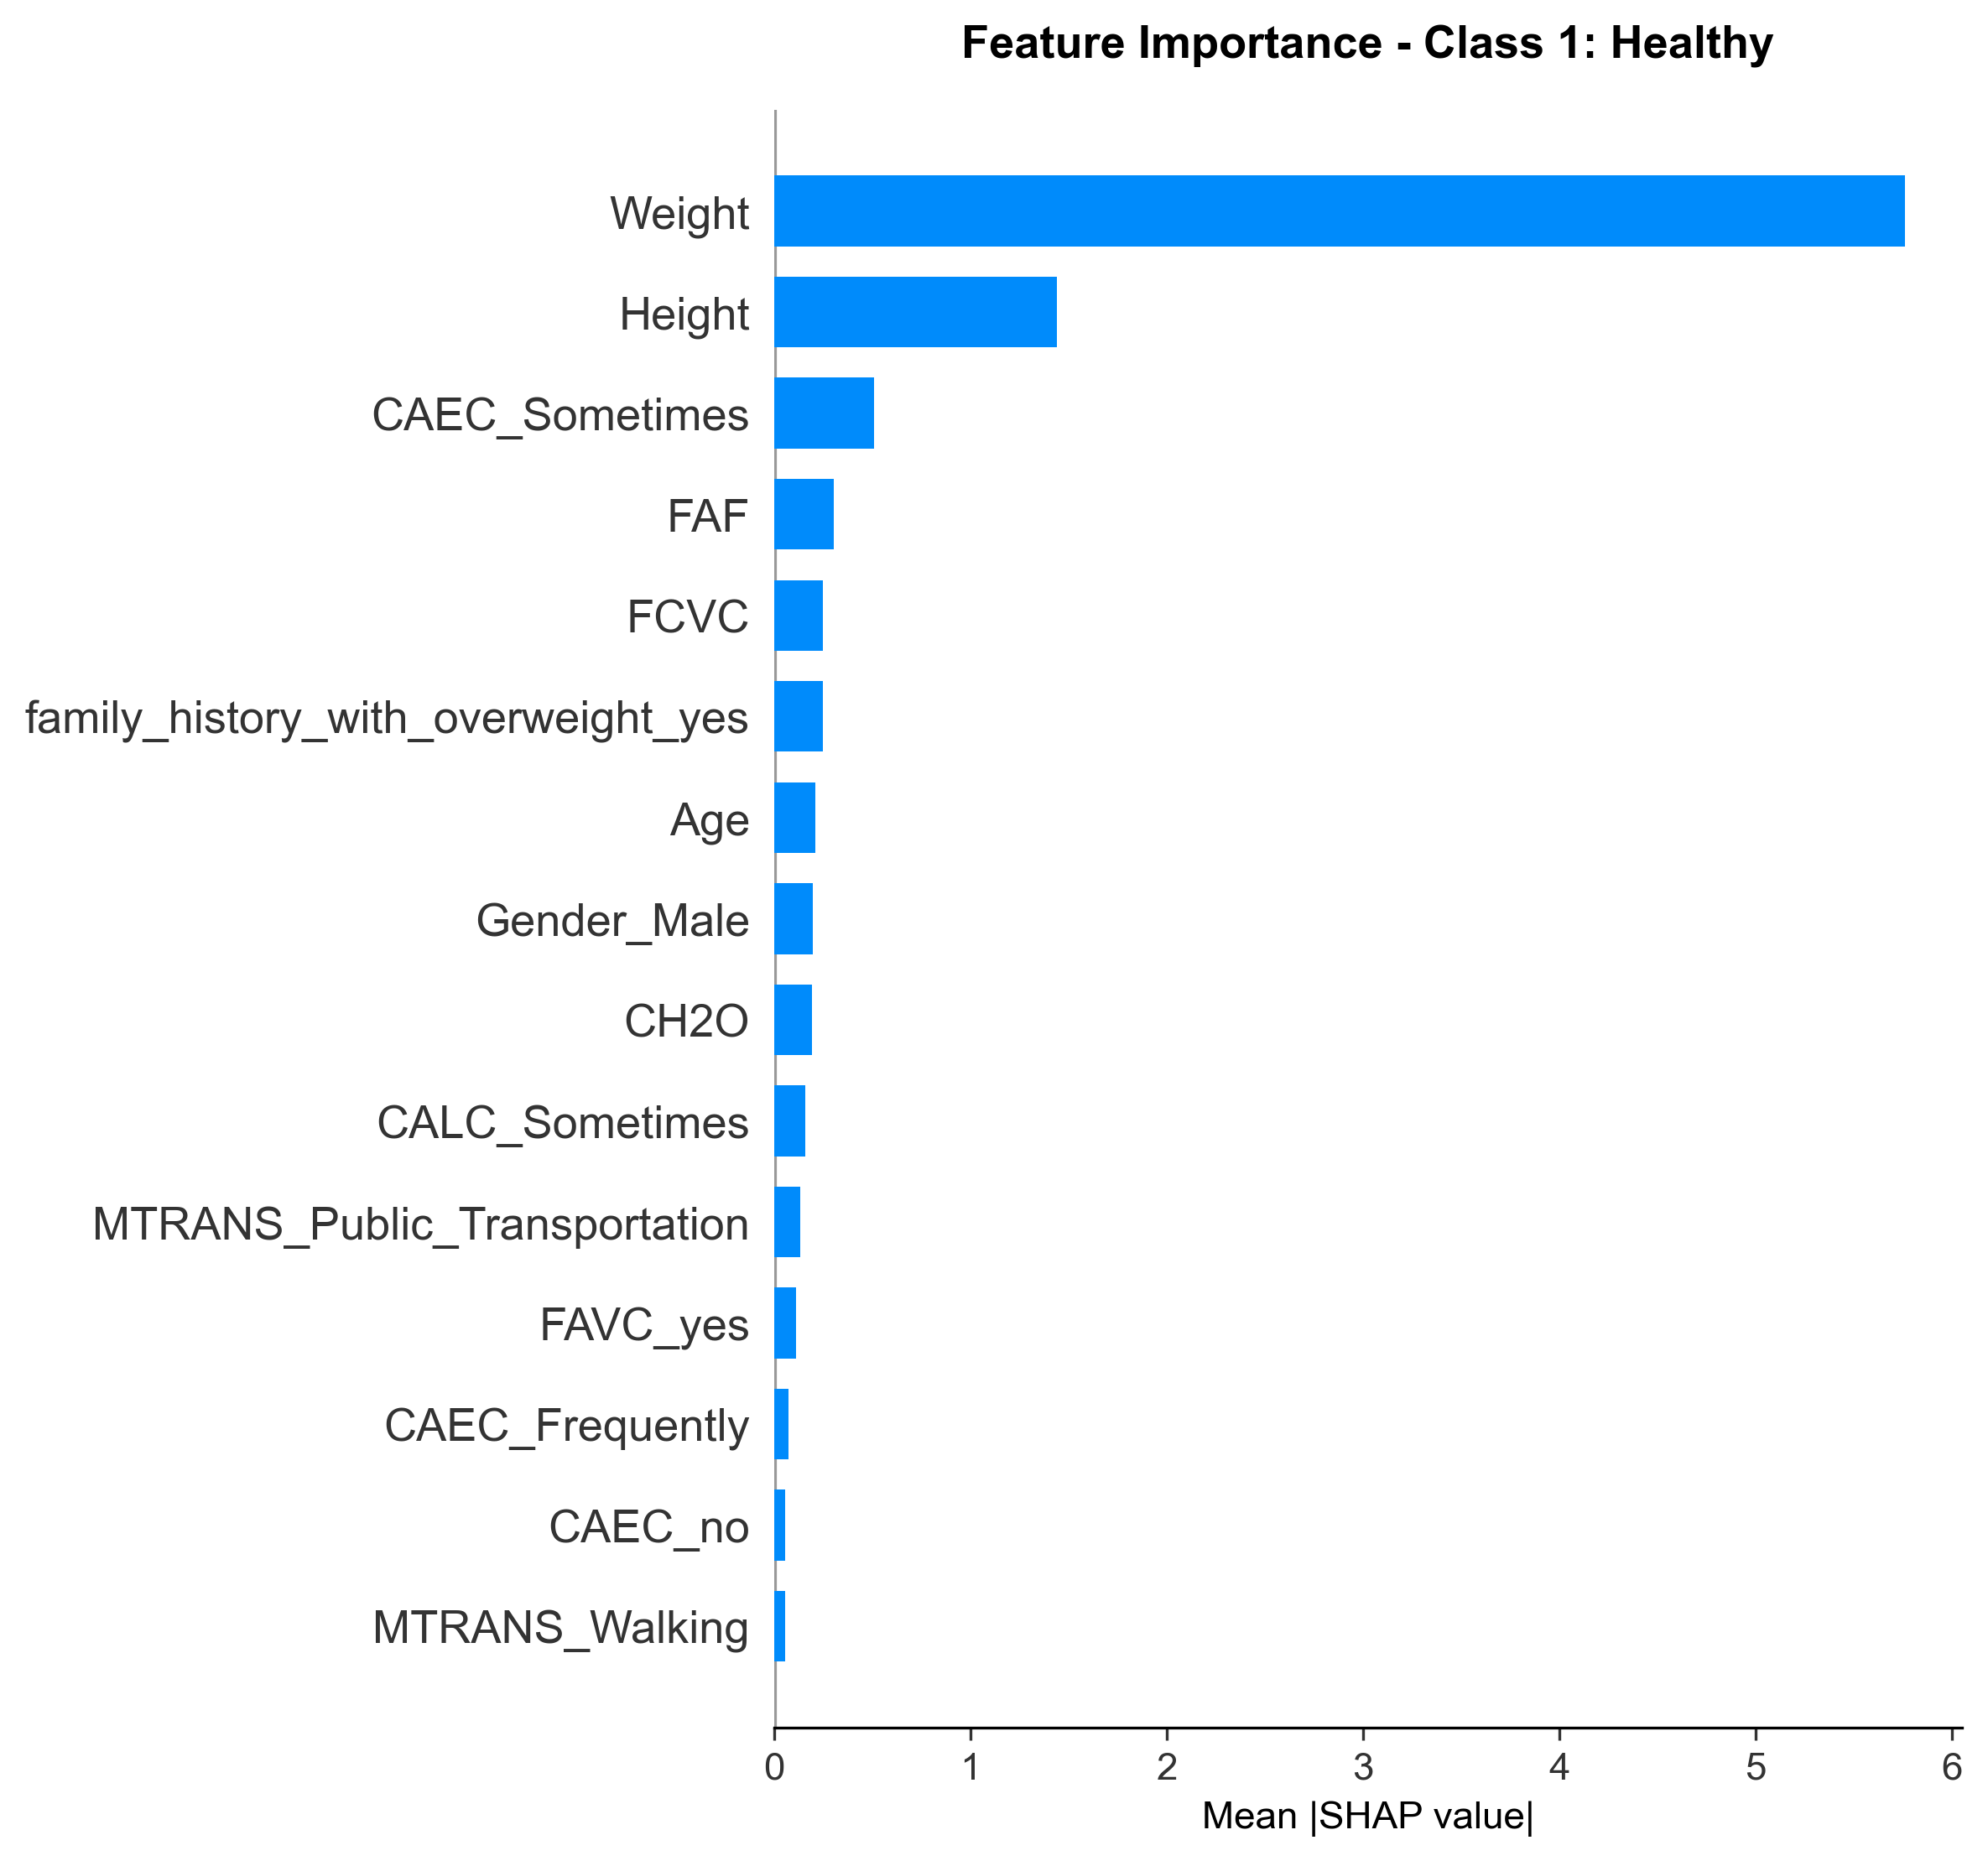

  ✓ Saved: shap_class_1_Healthy_bar.png

Processing Class 2: Overweight L1


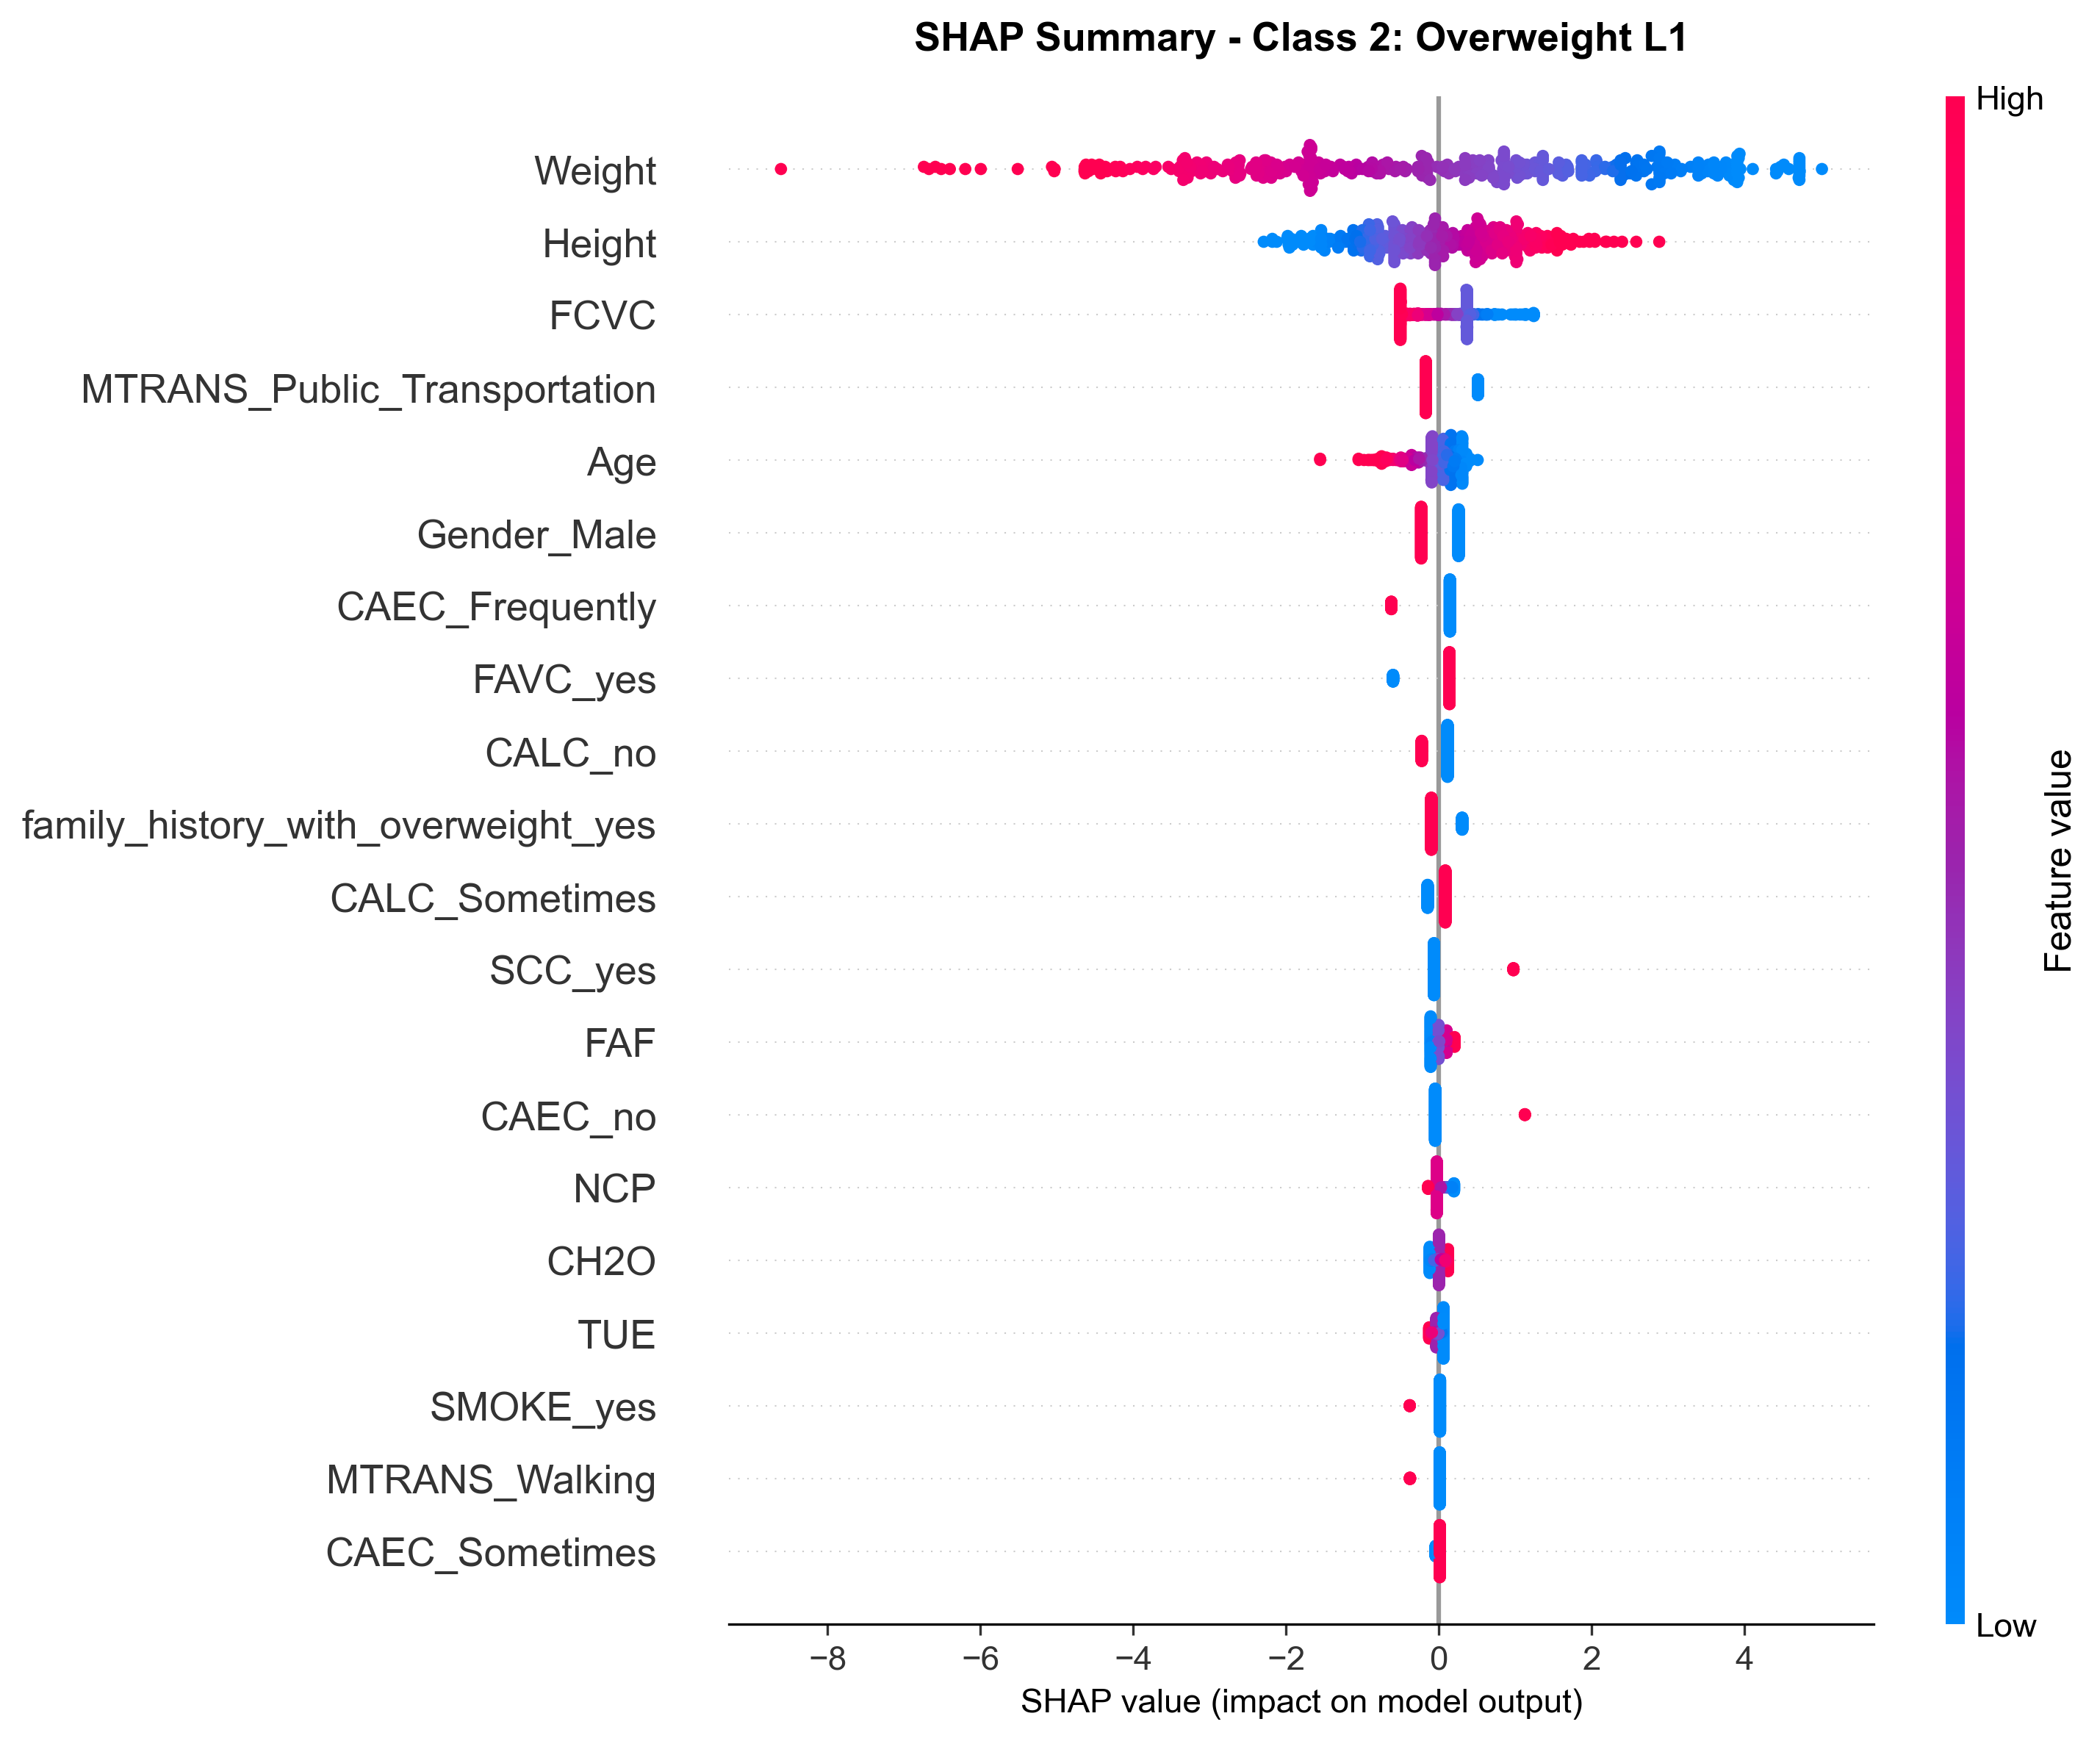

  ✓ Saved: shap_class_2_Overweight_L1_summary.png


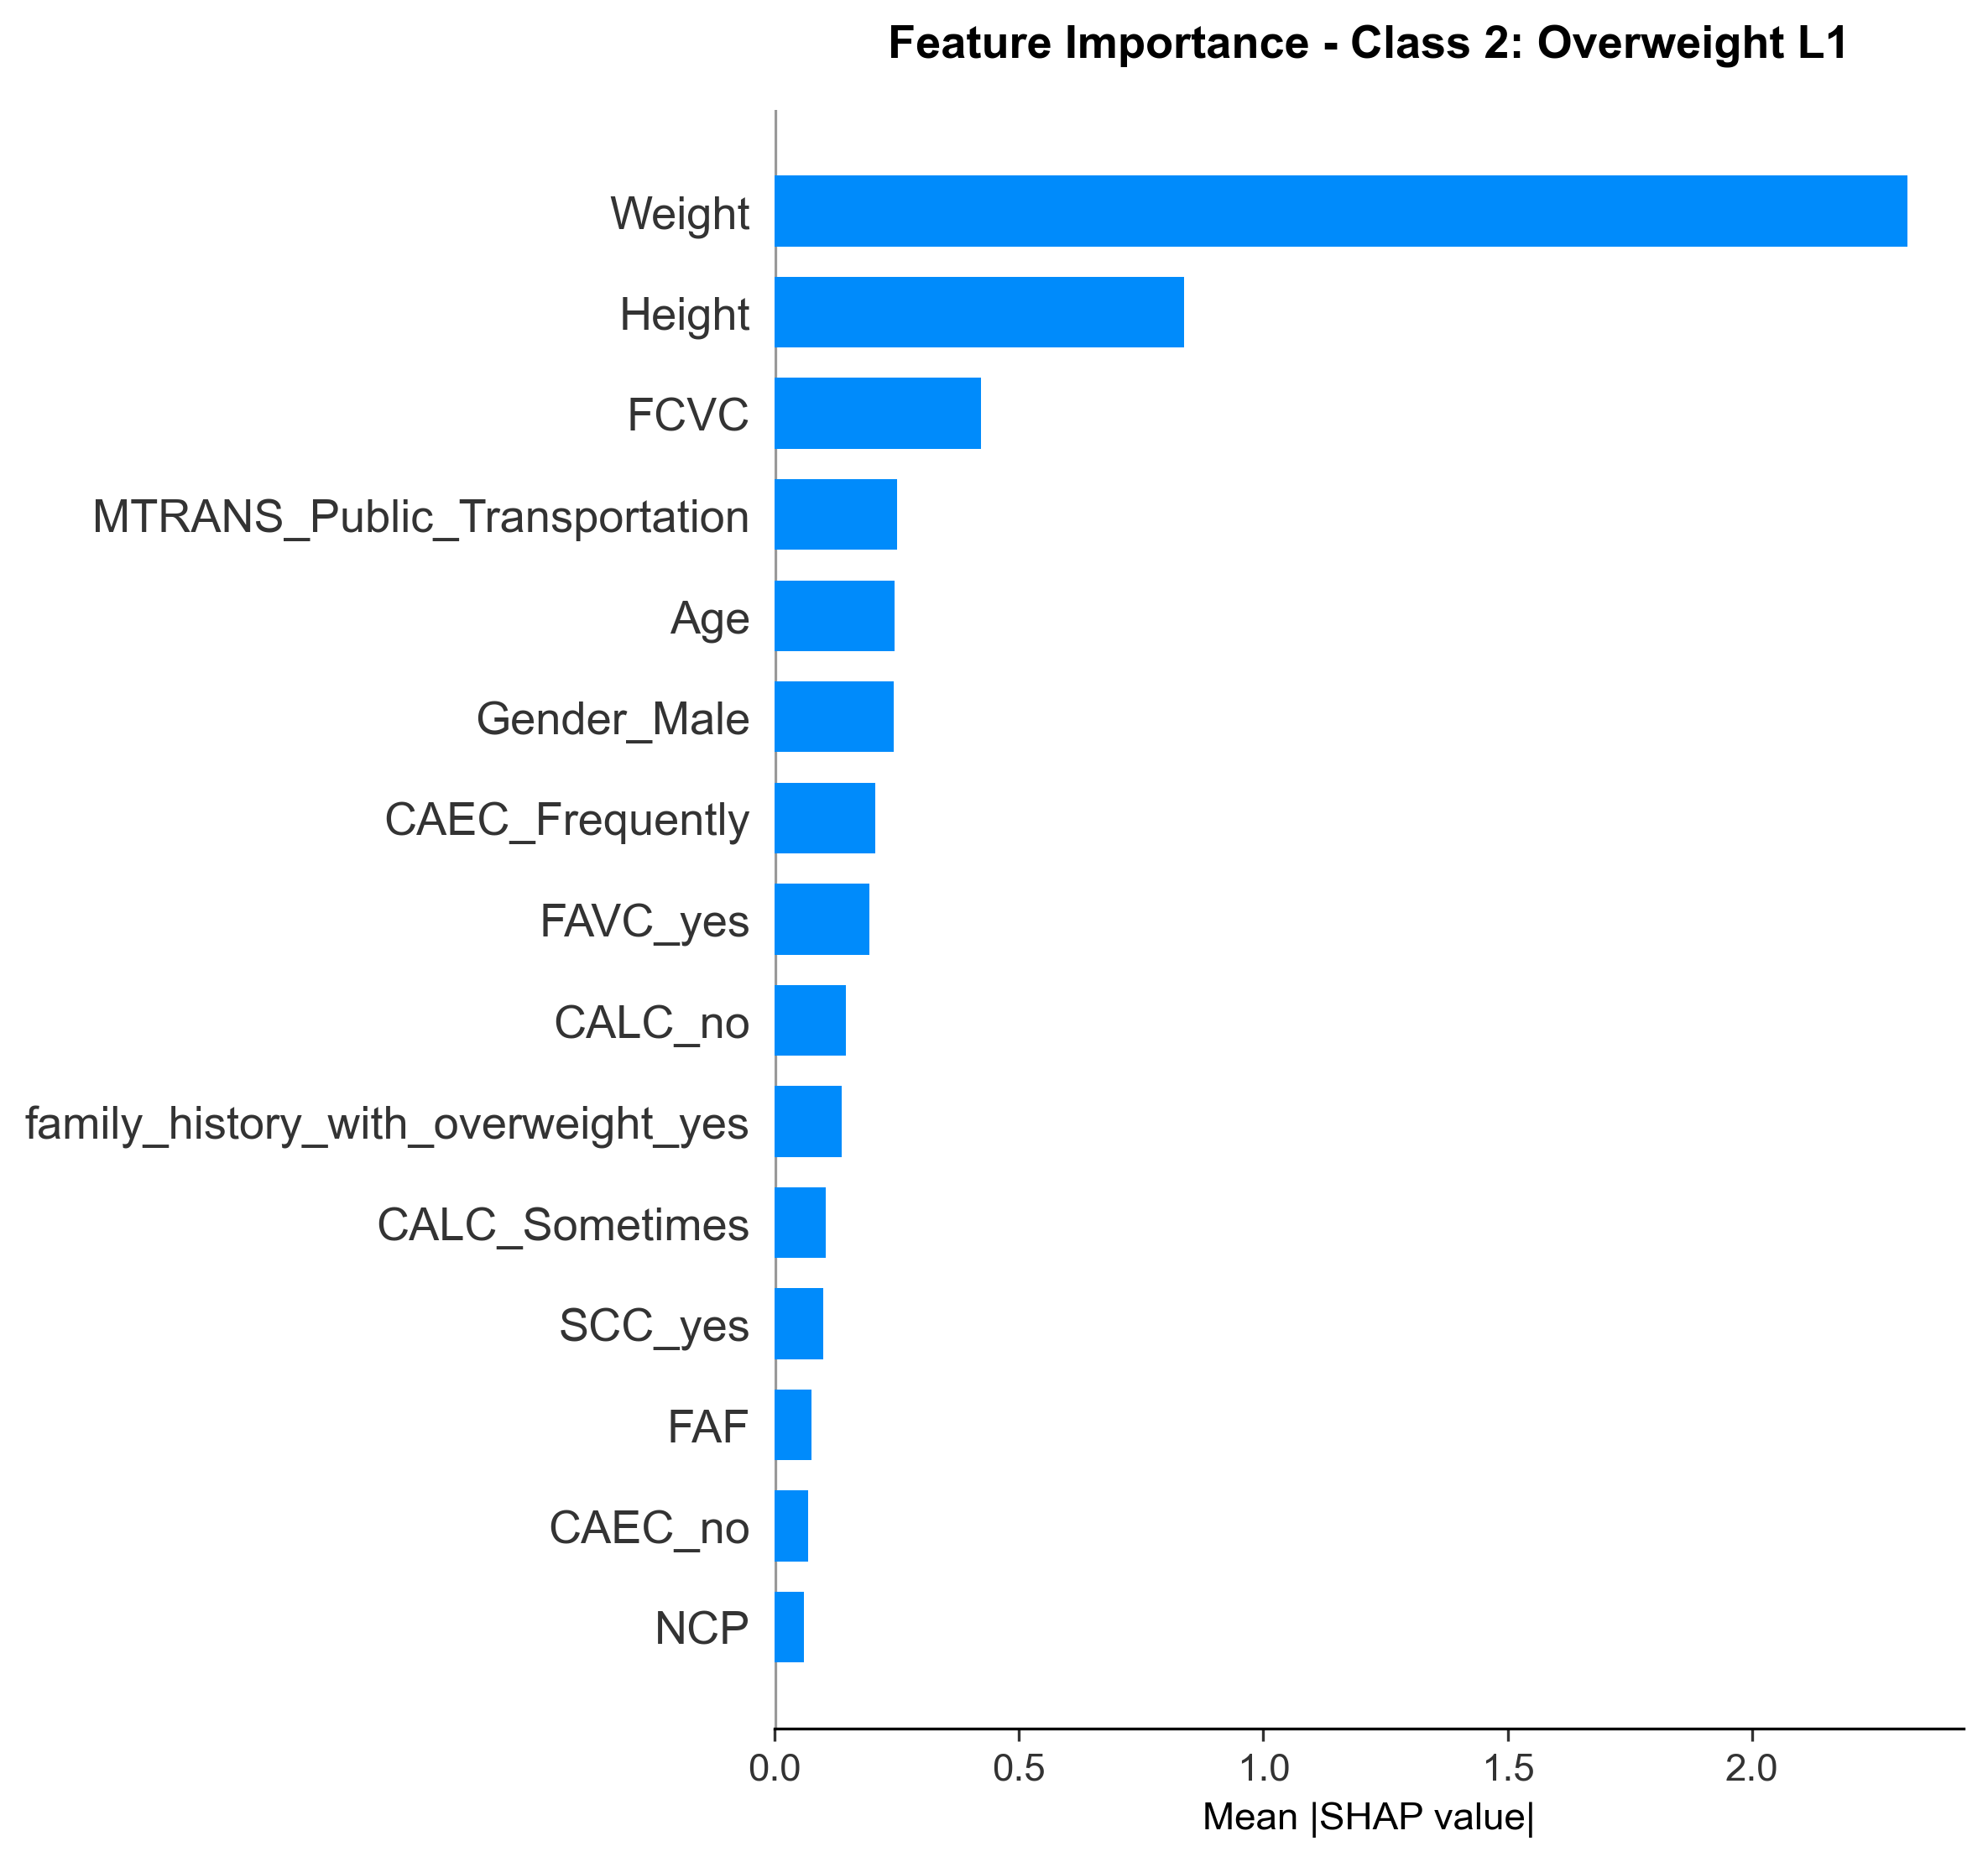

  ✓ Saved: shap_class_2_Overweight_L1_bar.png

Processing Class 3: Overweight L2


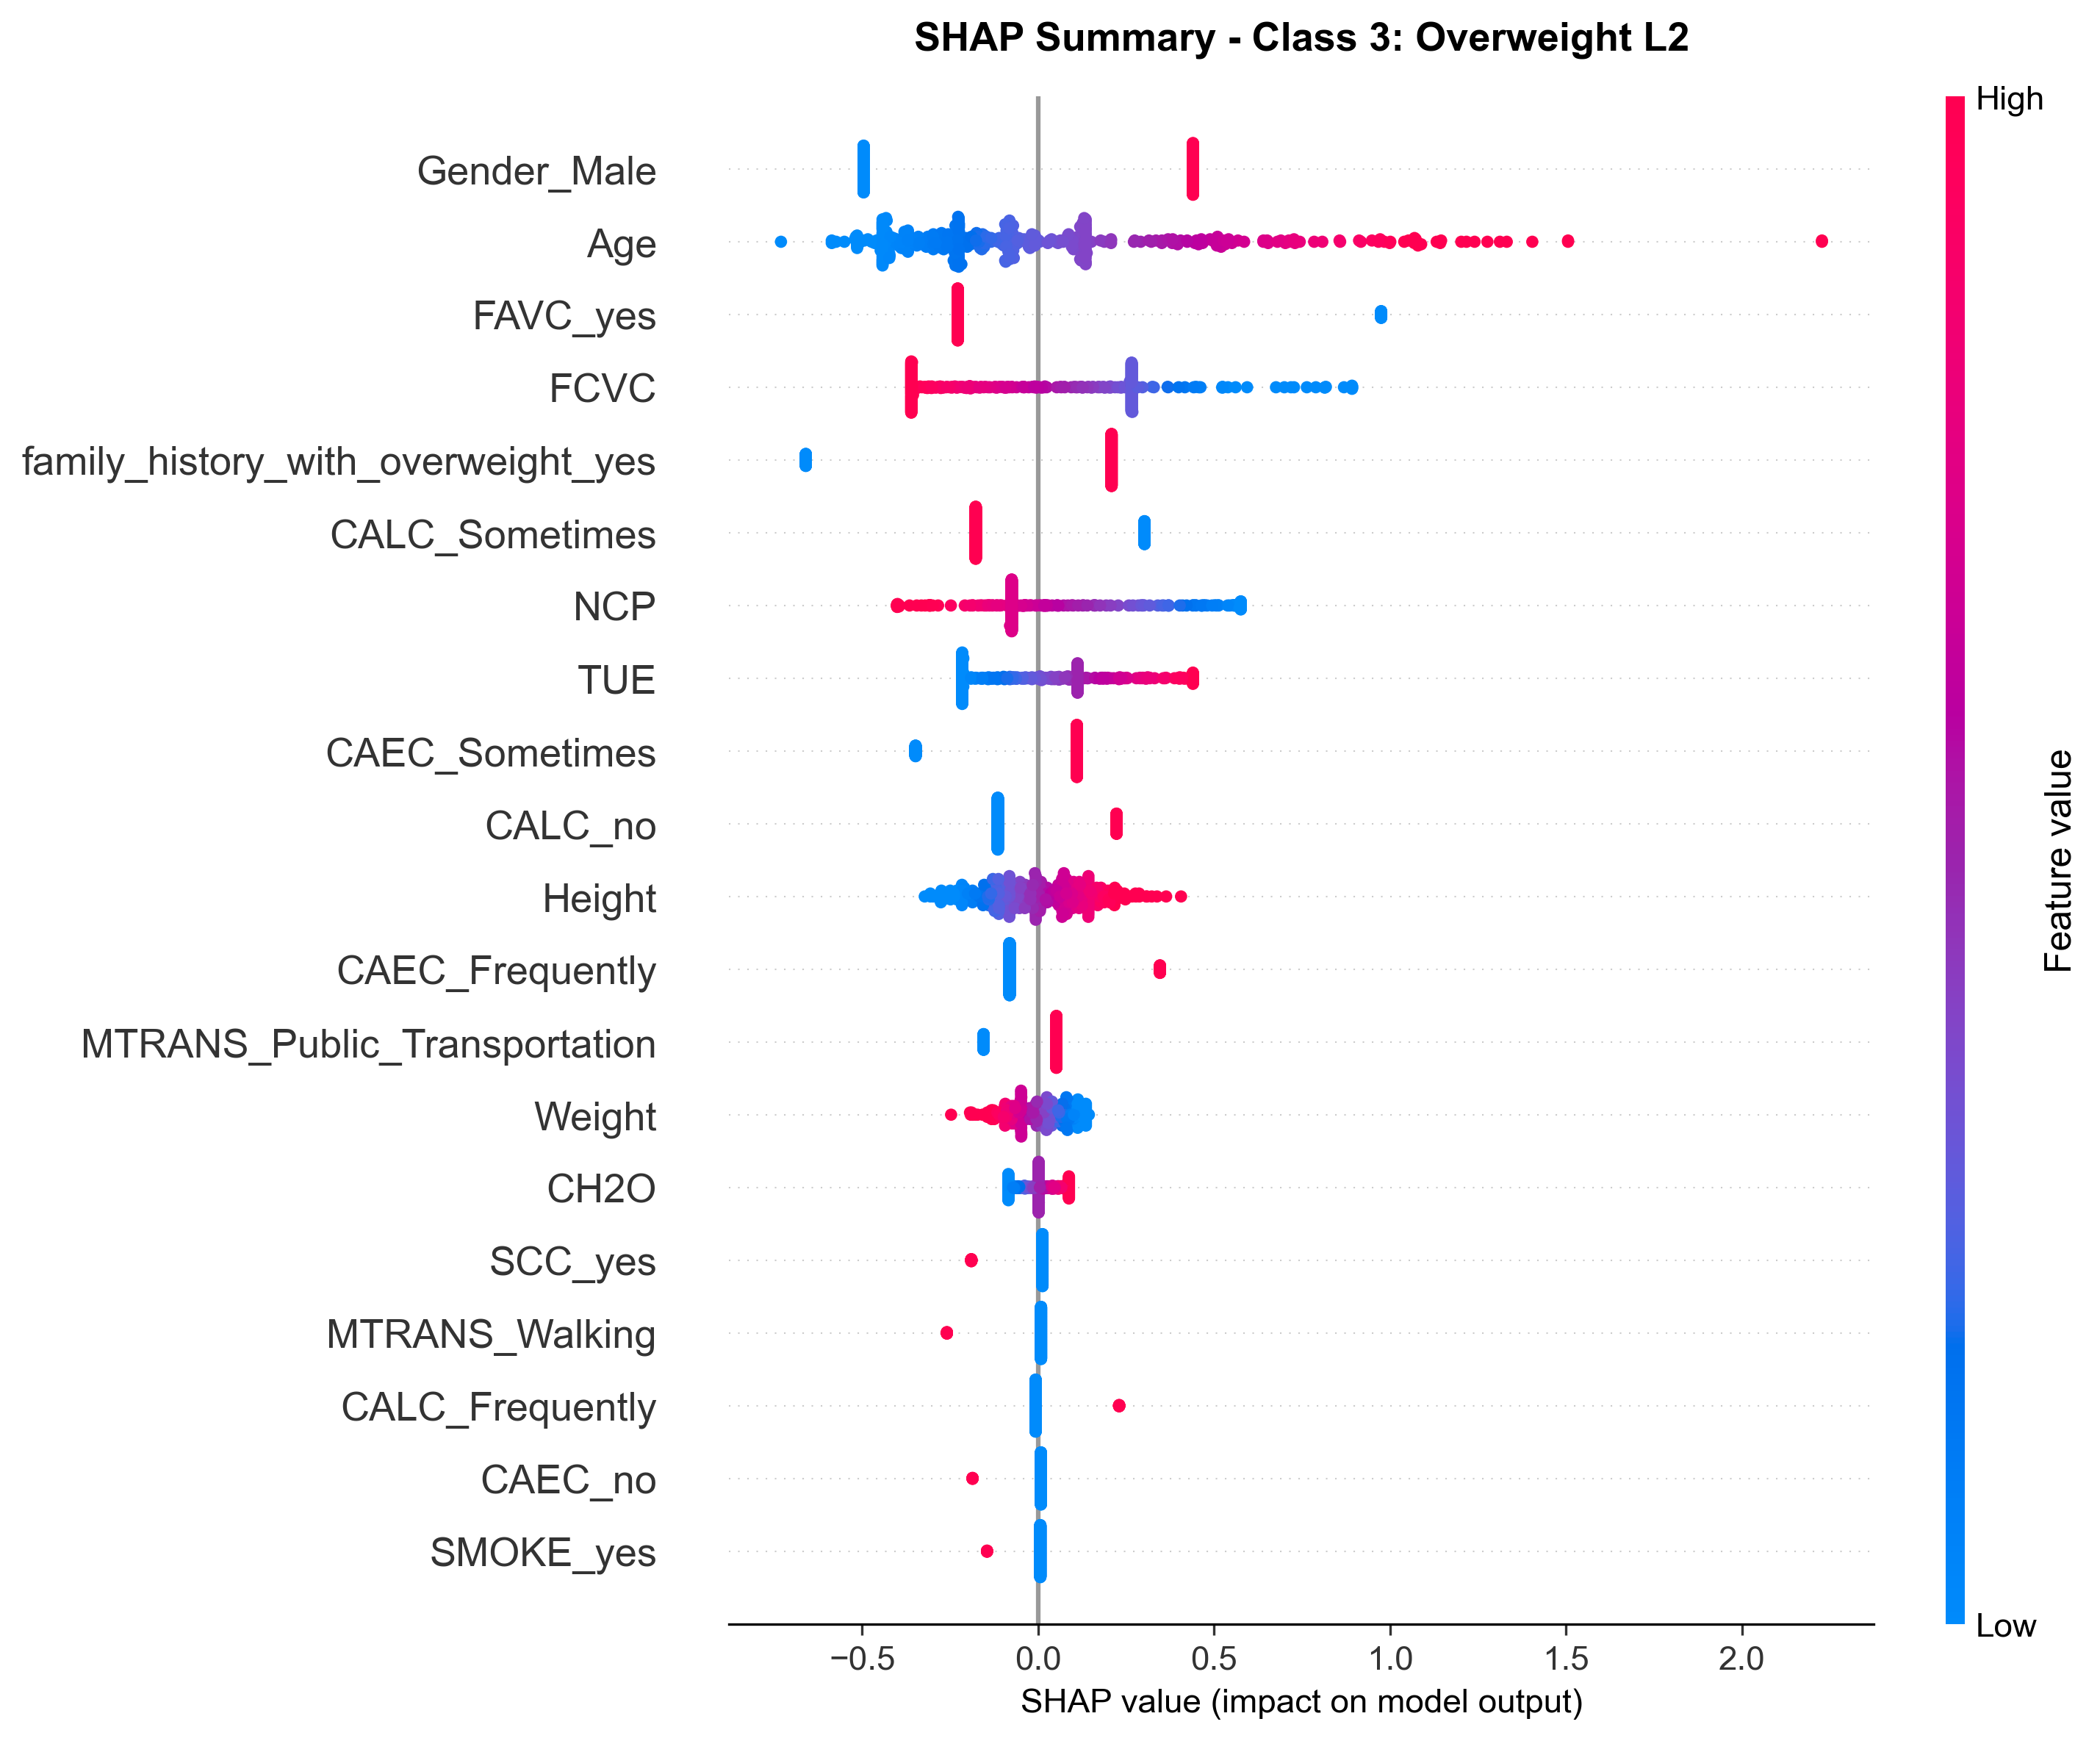

  ✓ Saved: shap_class_3_Overweight_L2_summary.png


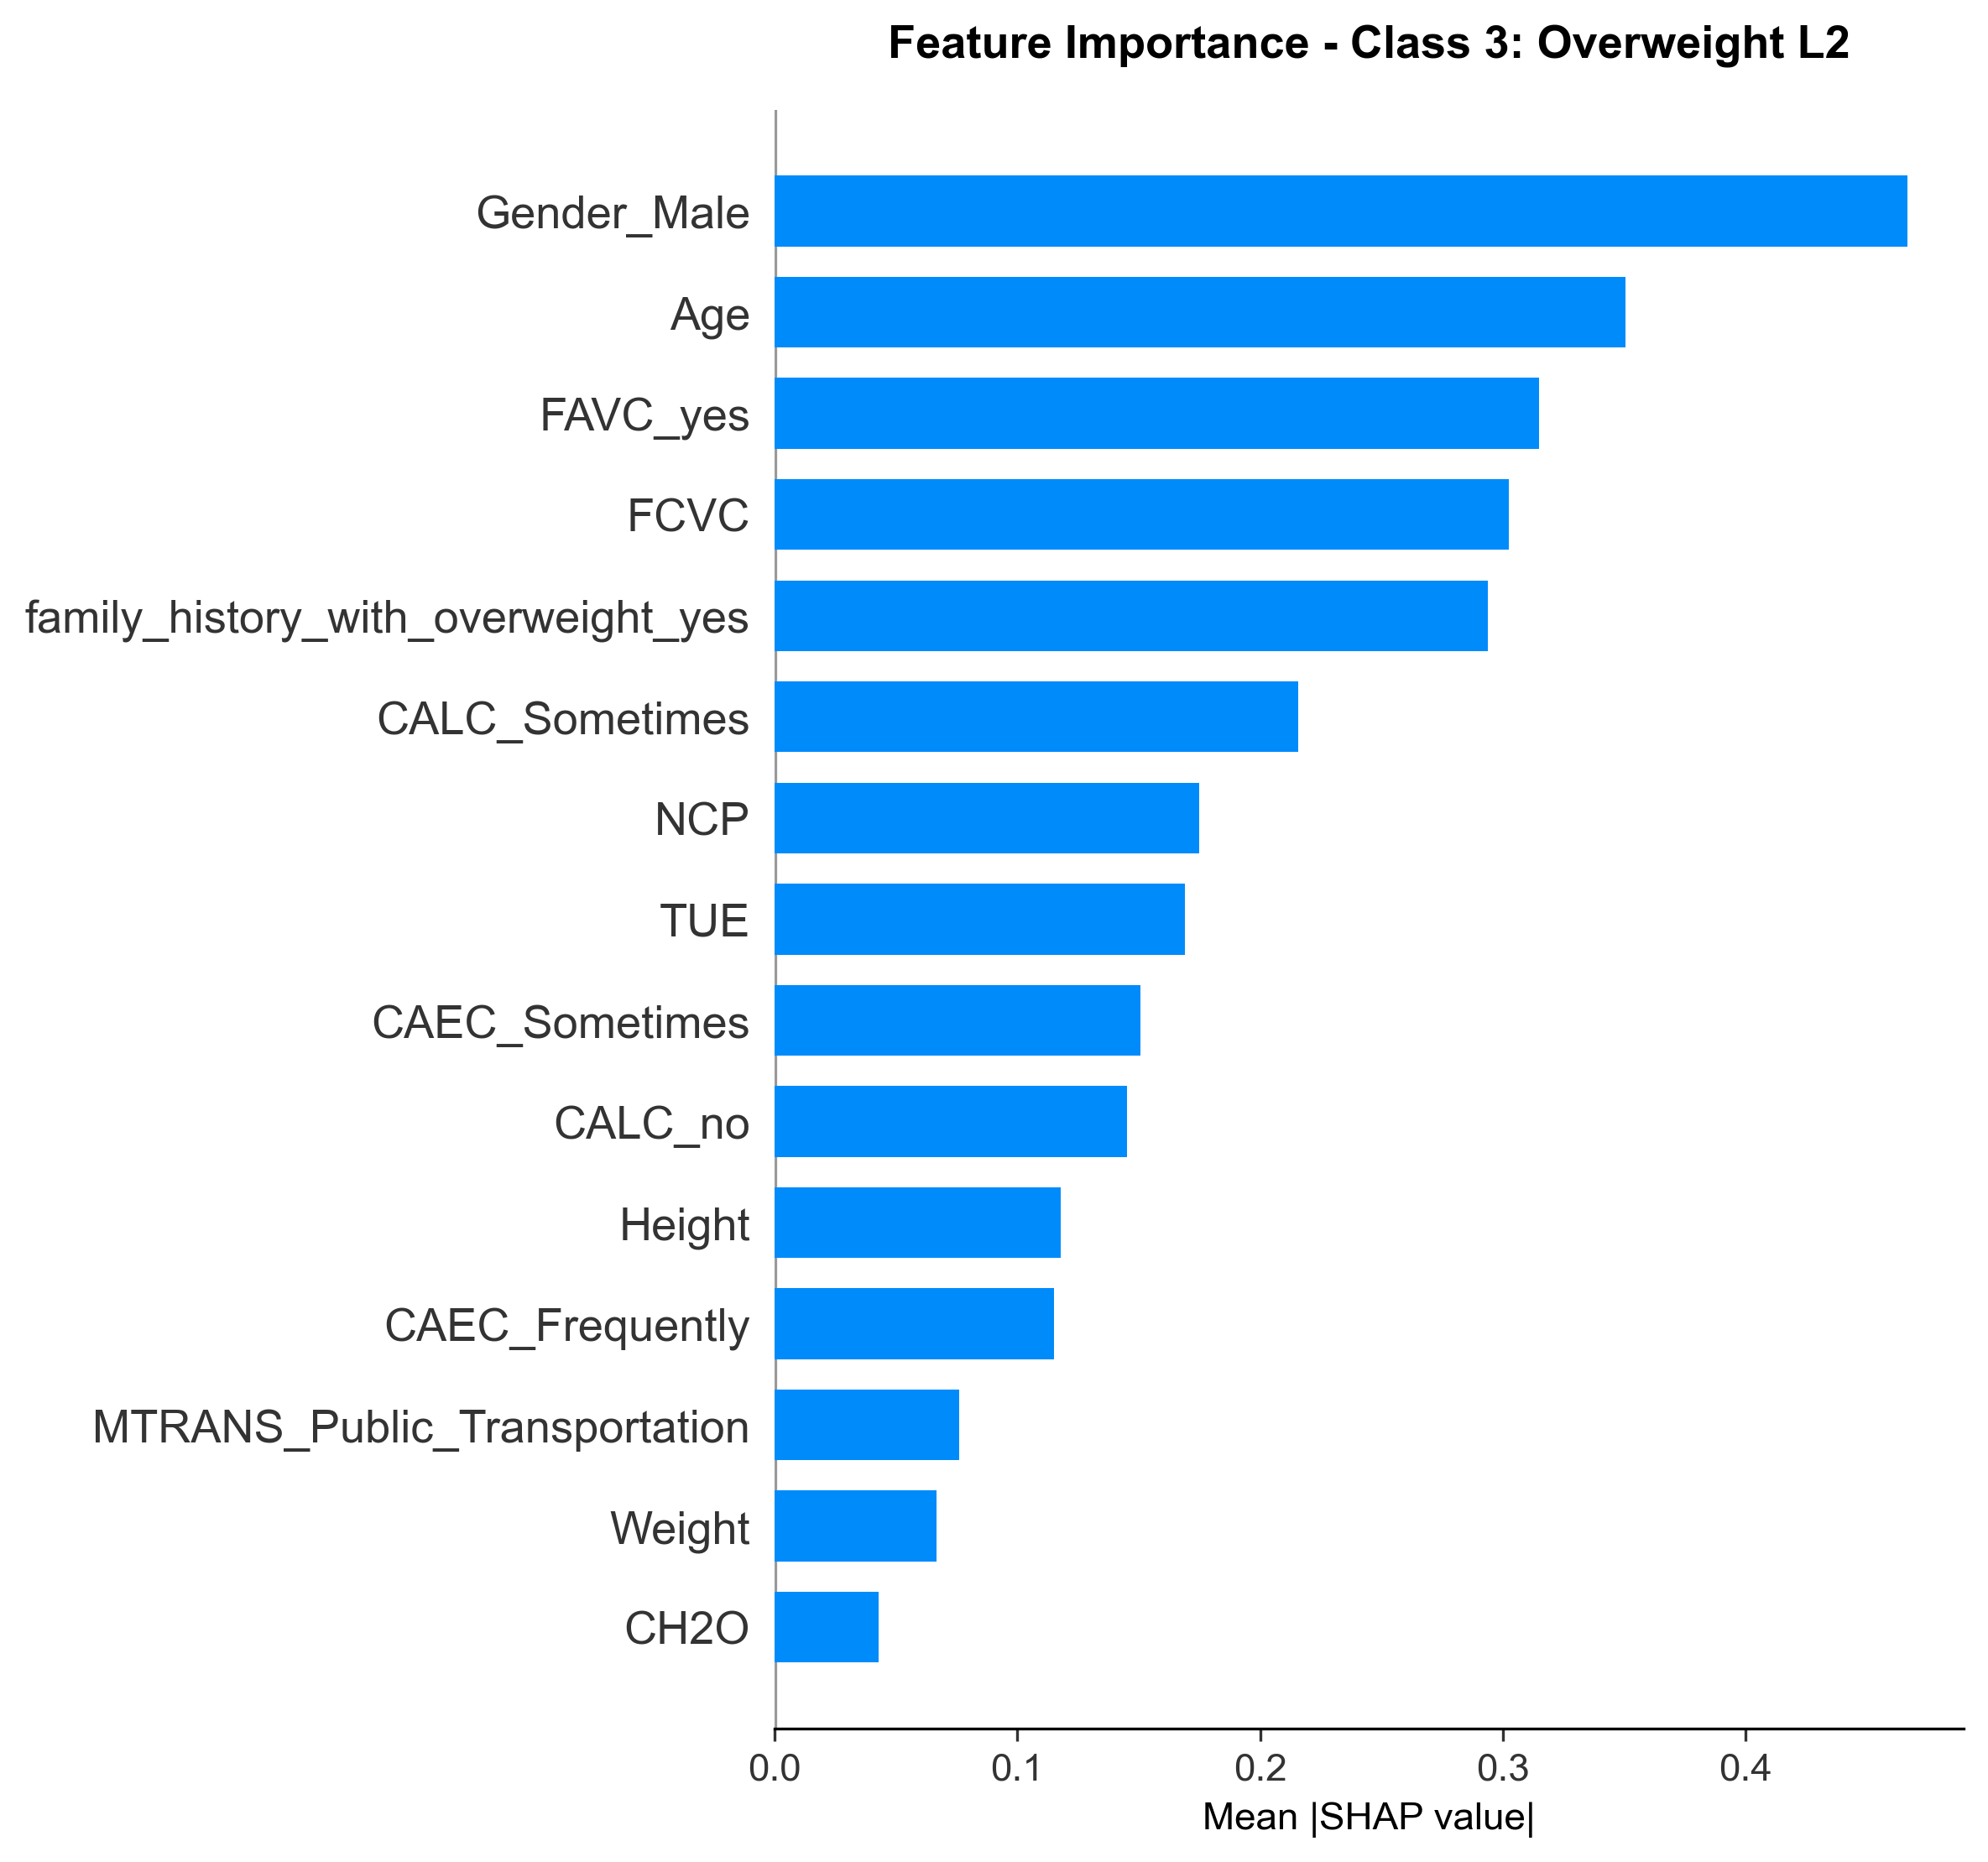

  ✓ Saved: shap_class_3_Overweight_L2_bar.png

Processing Class 4: Obesity L1


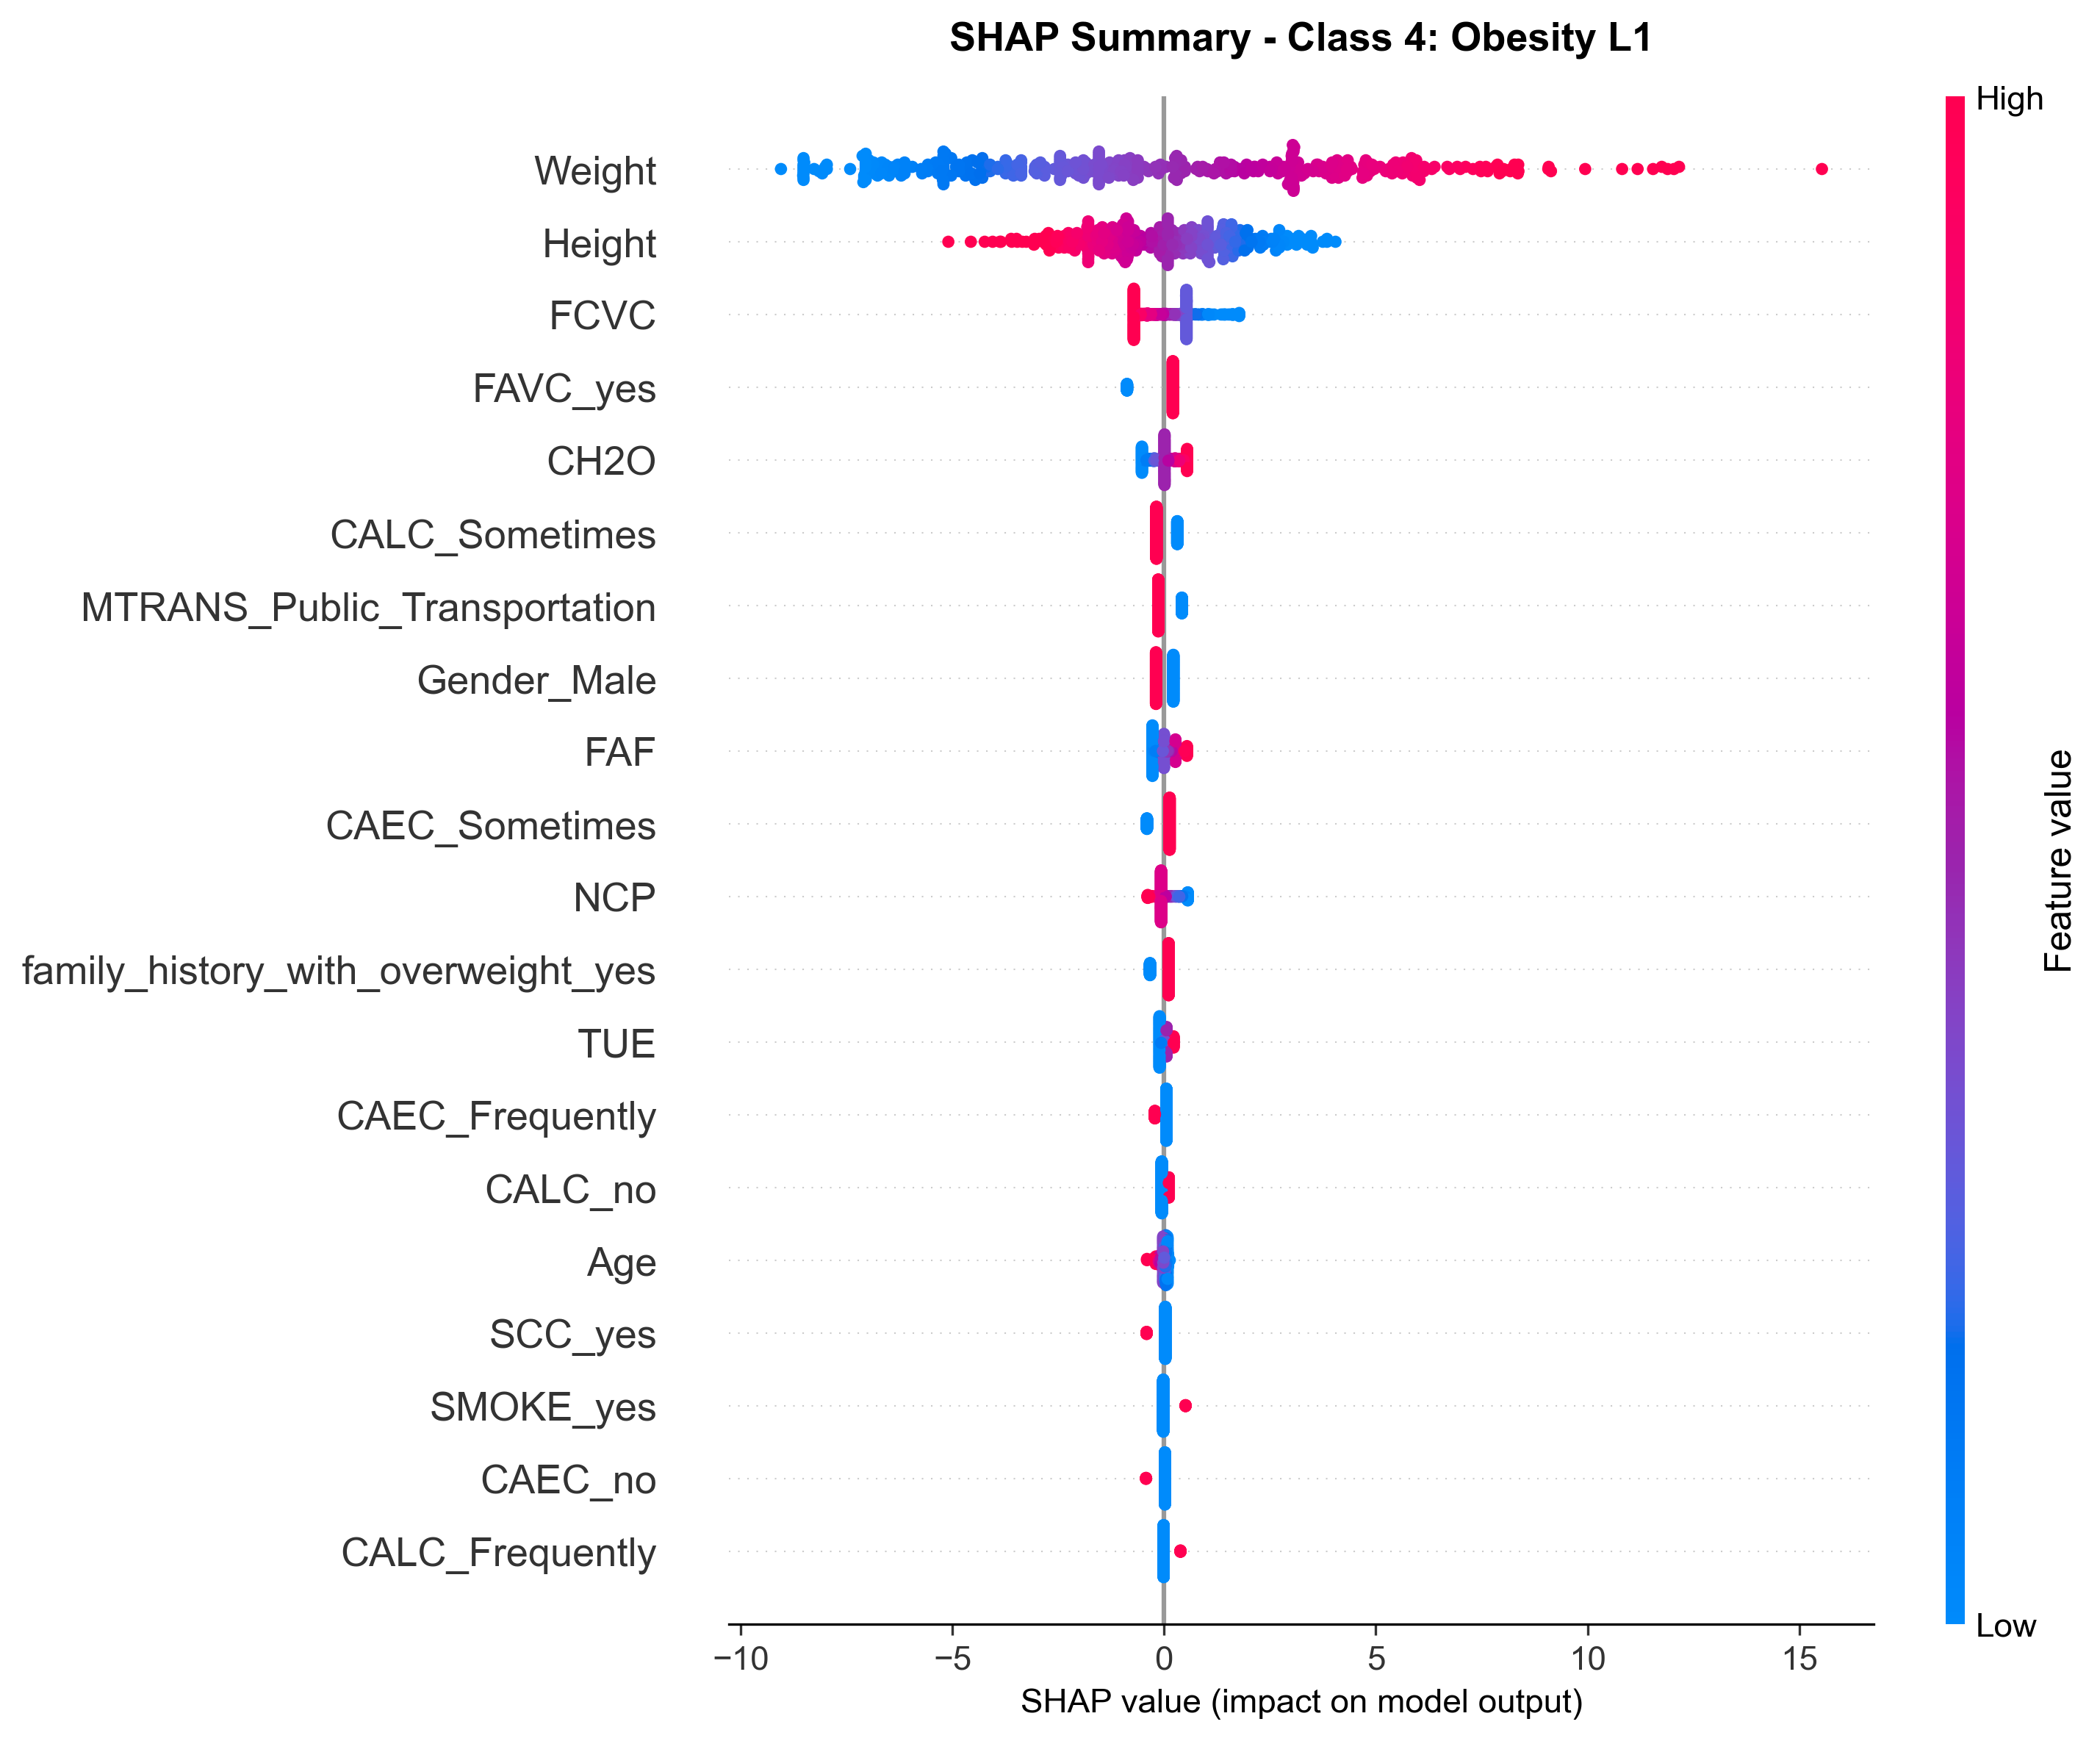

  ✓ Saved: shap_class_4_Obesity_L1_summary.png


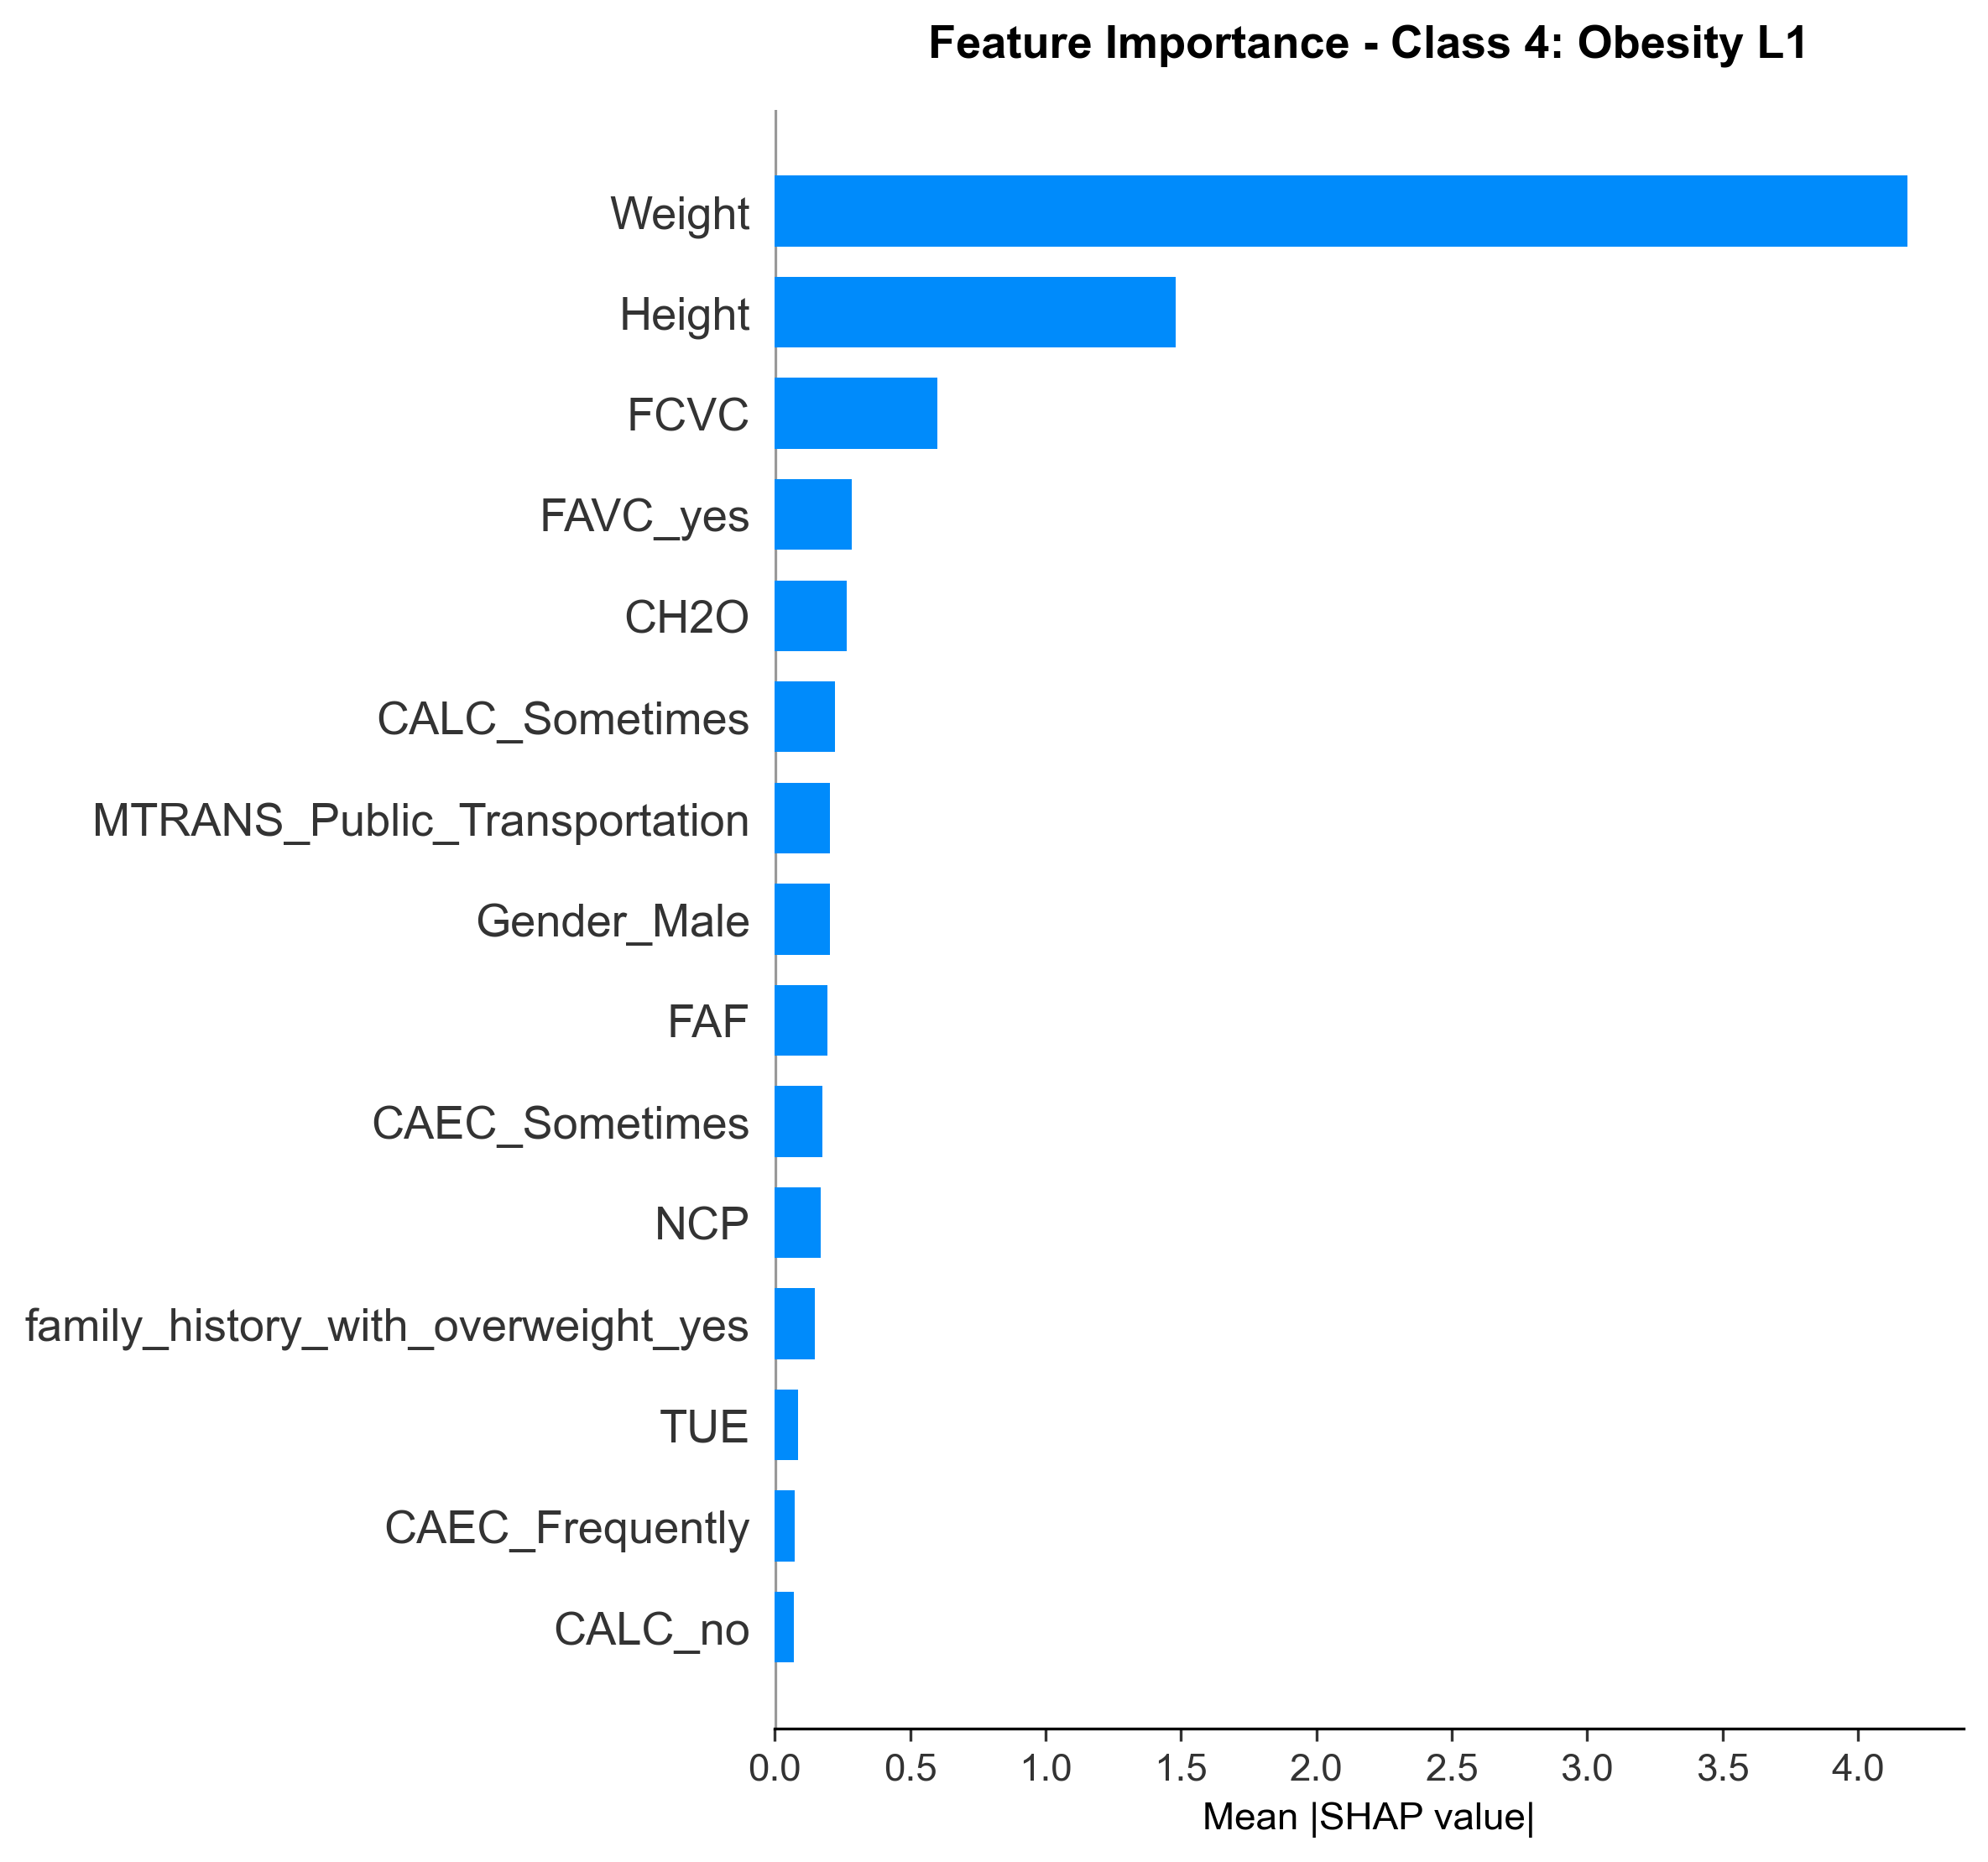

  ✓ Saved: shap_class_4_Obesity_L1_bar.png

Processing Class 5: Obesity L2


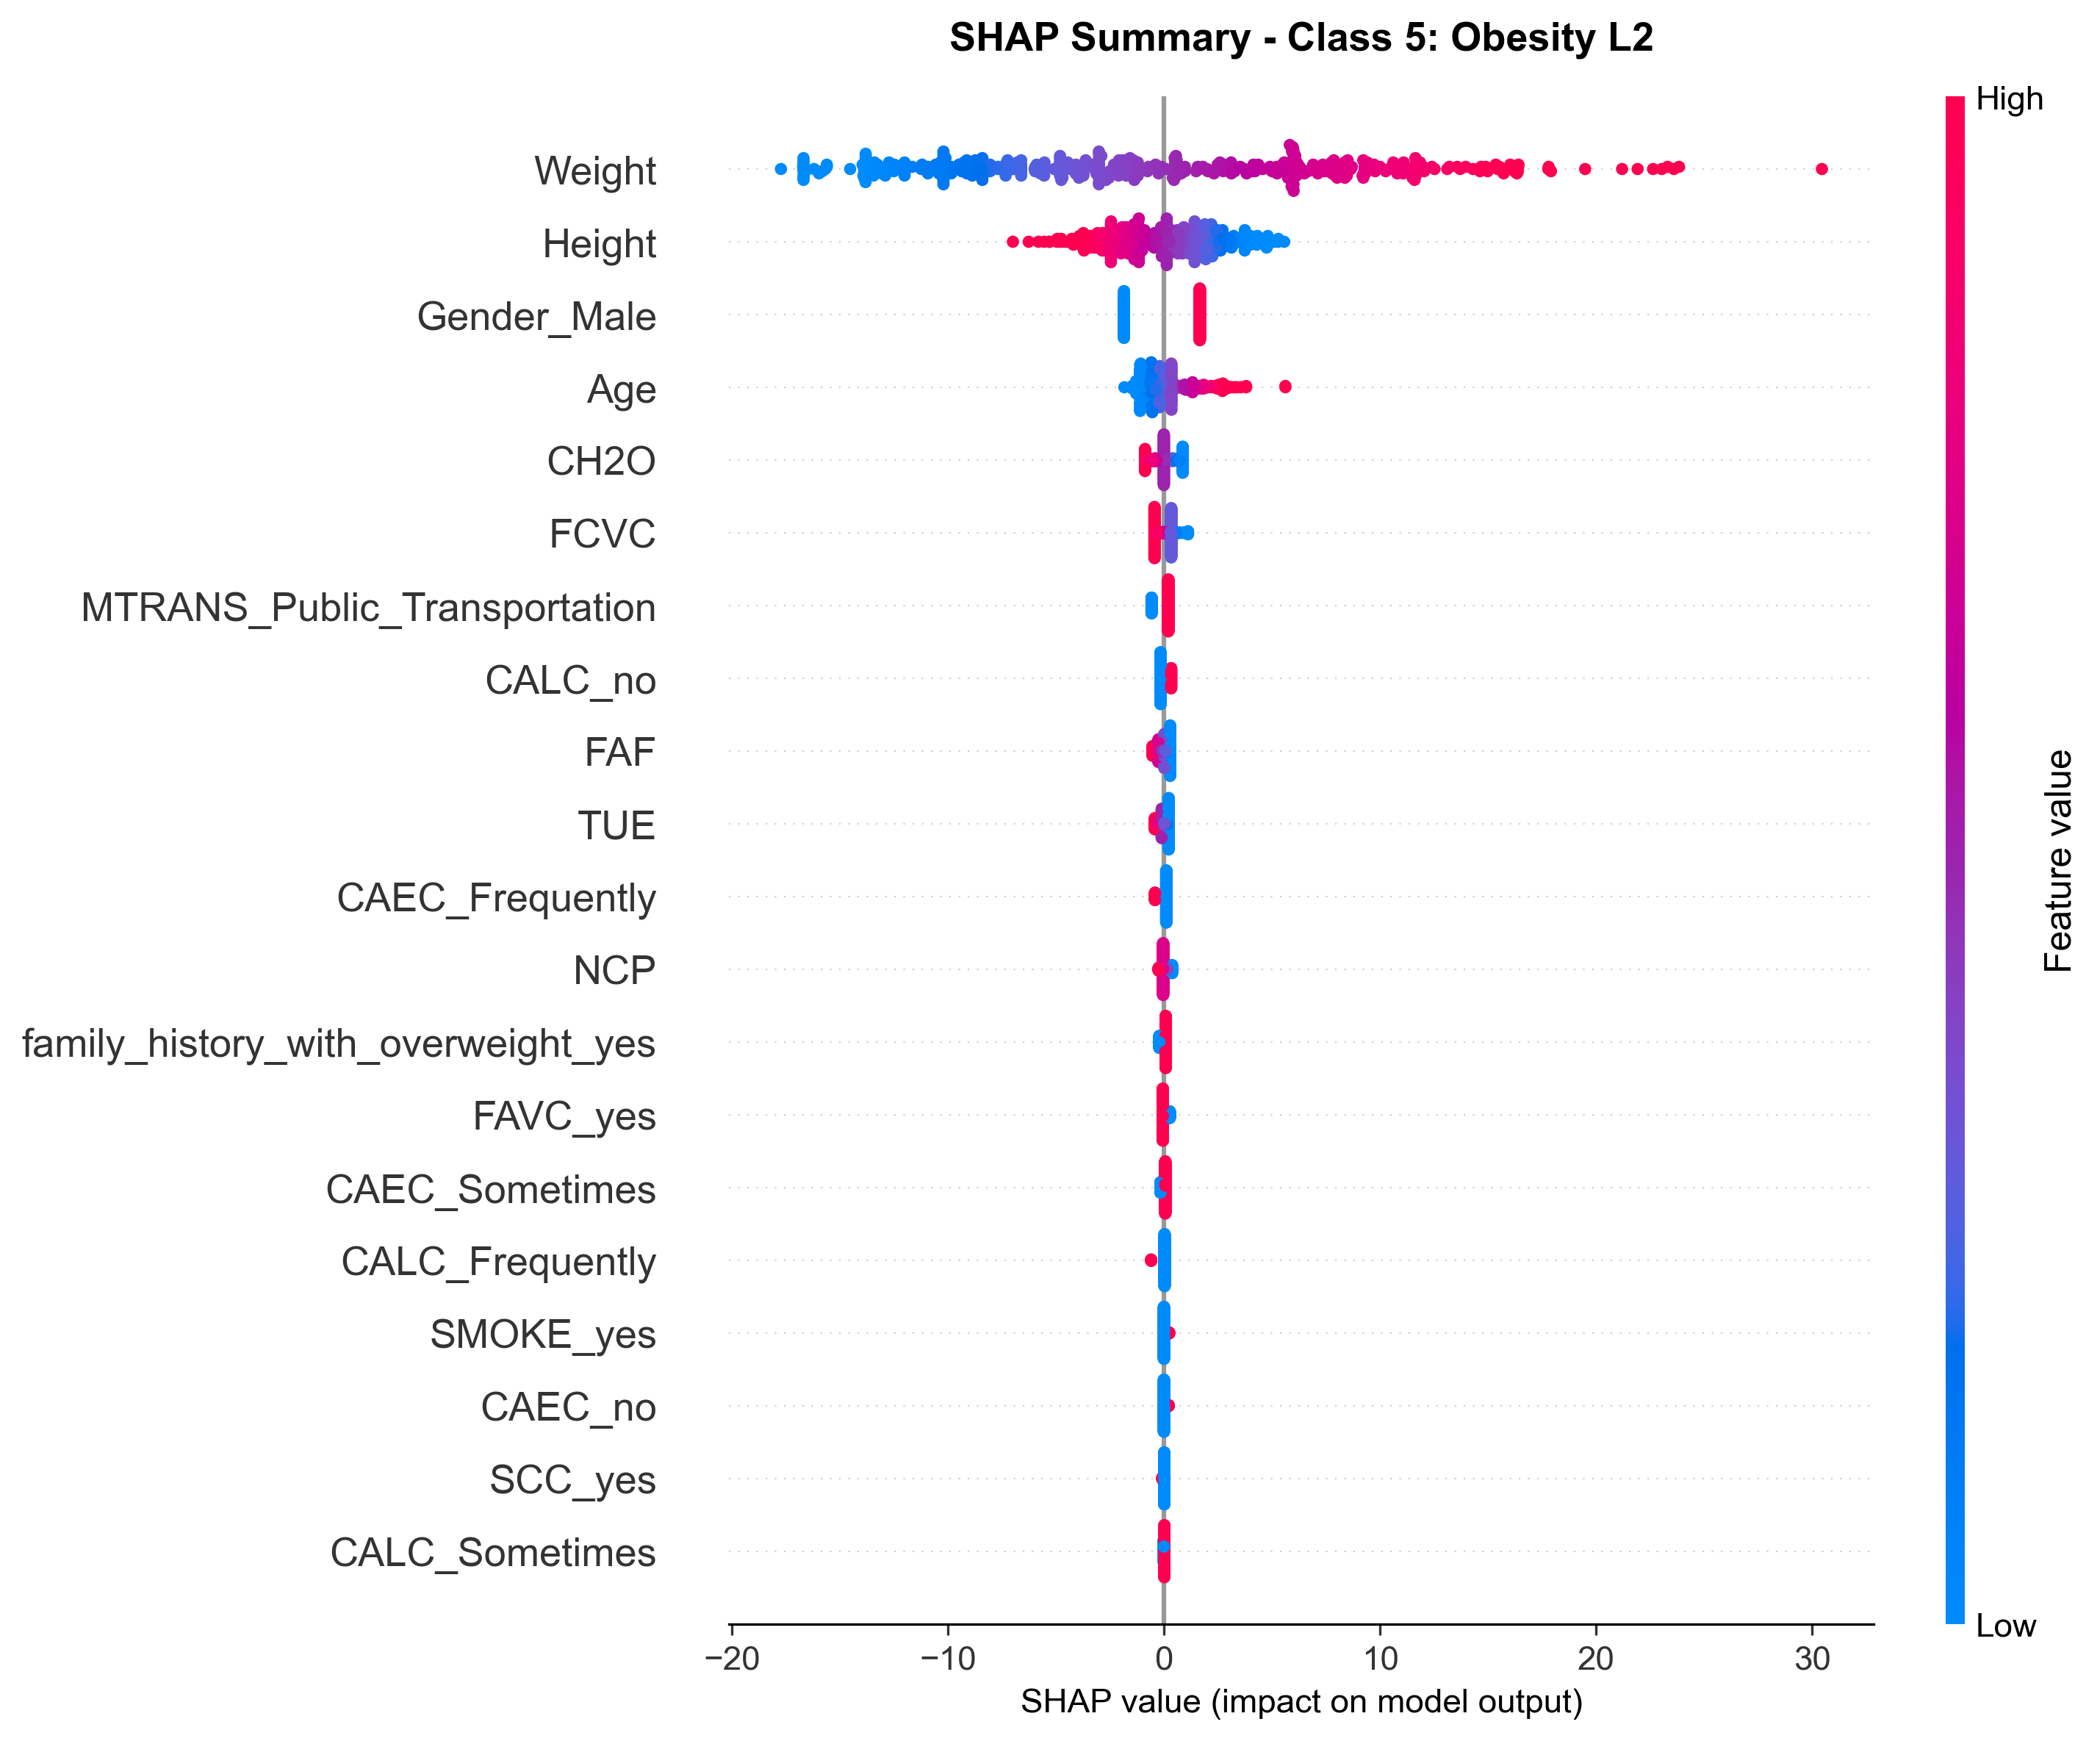

  ✓ Saved: shap_class_5_Obesity_L2_summary.png


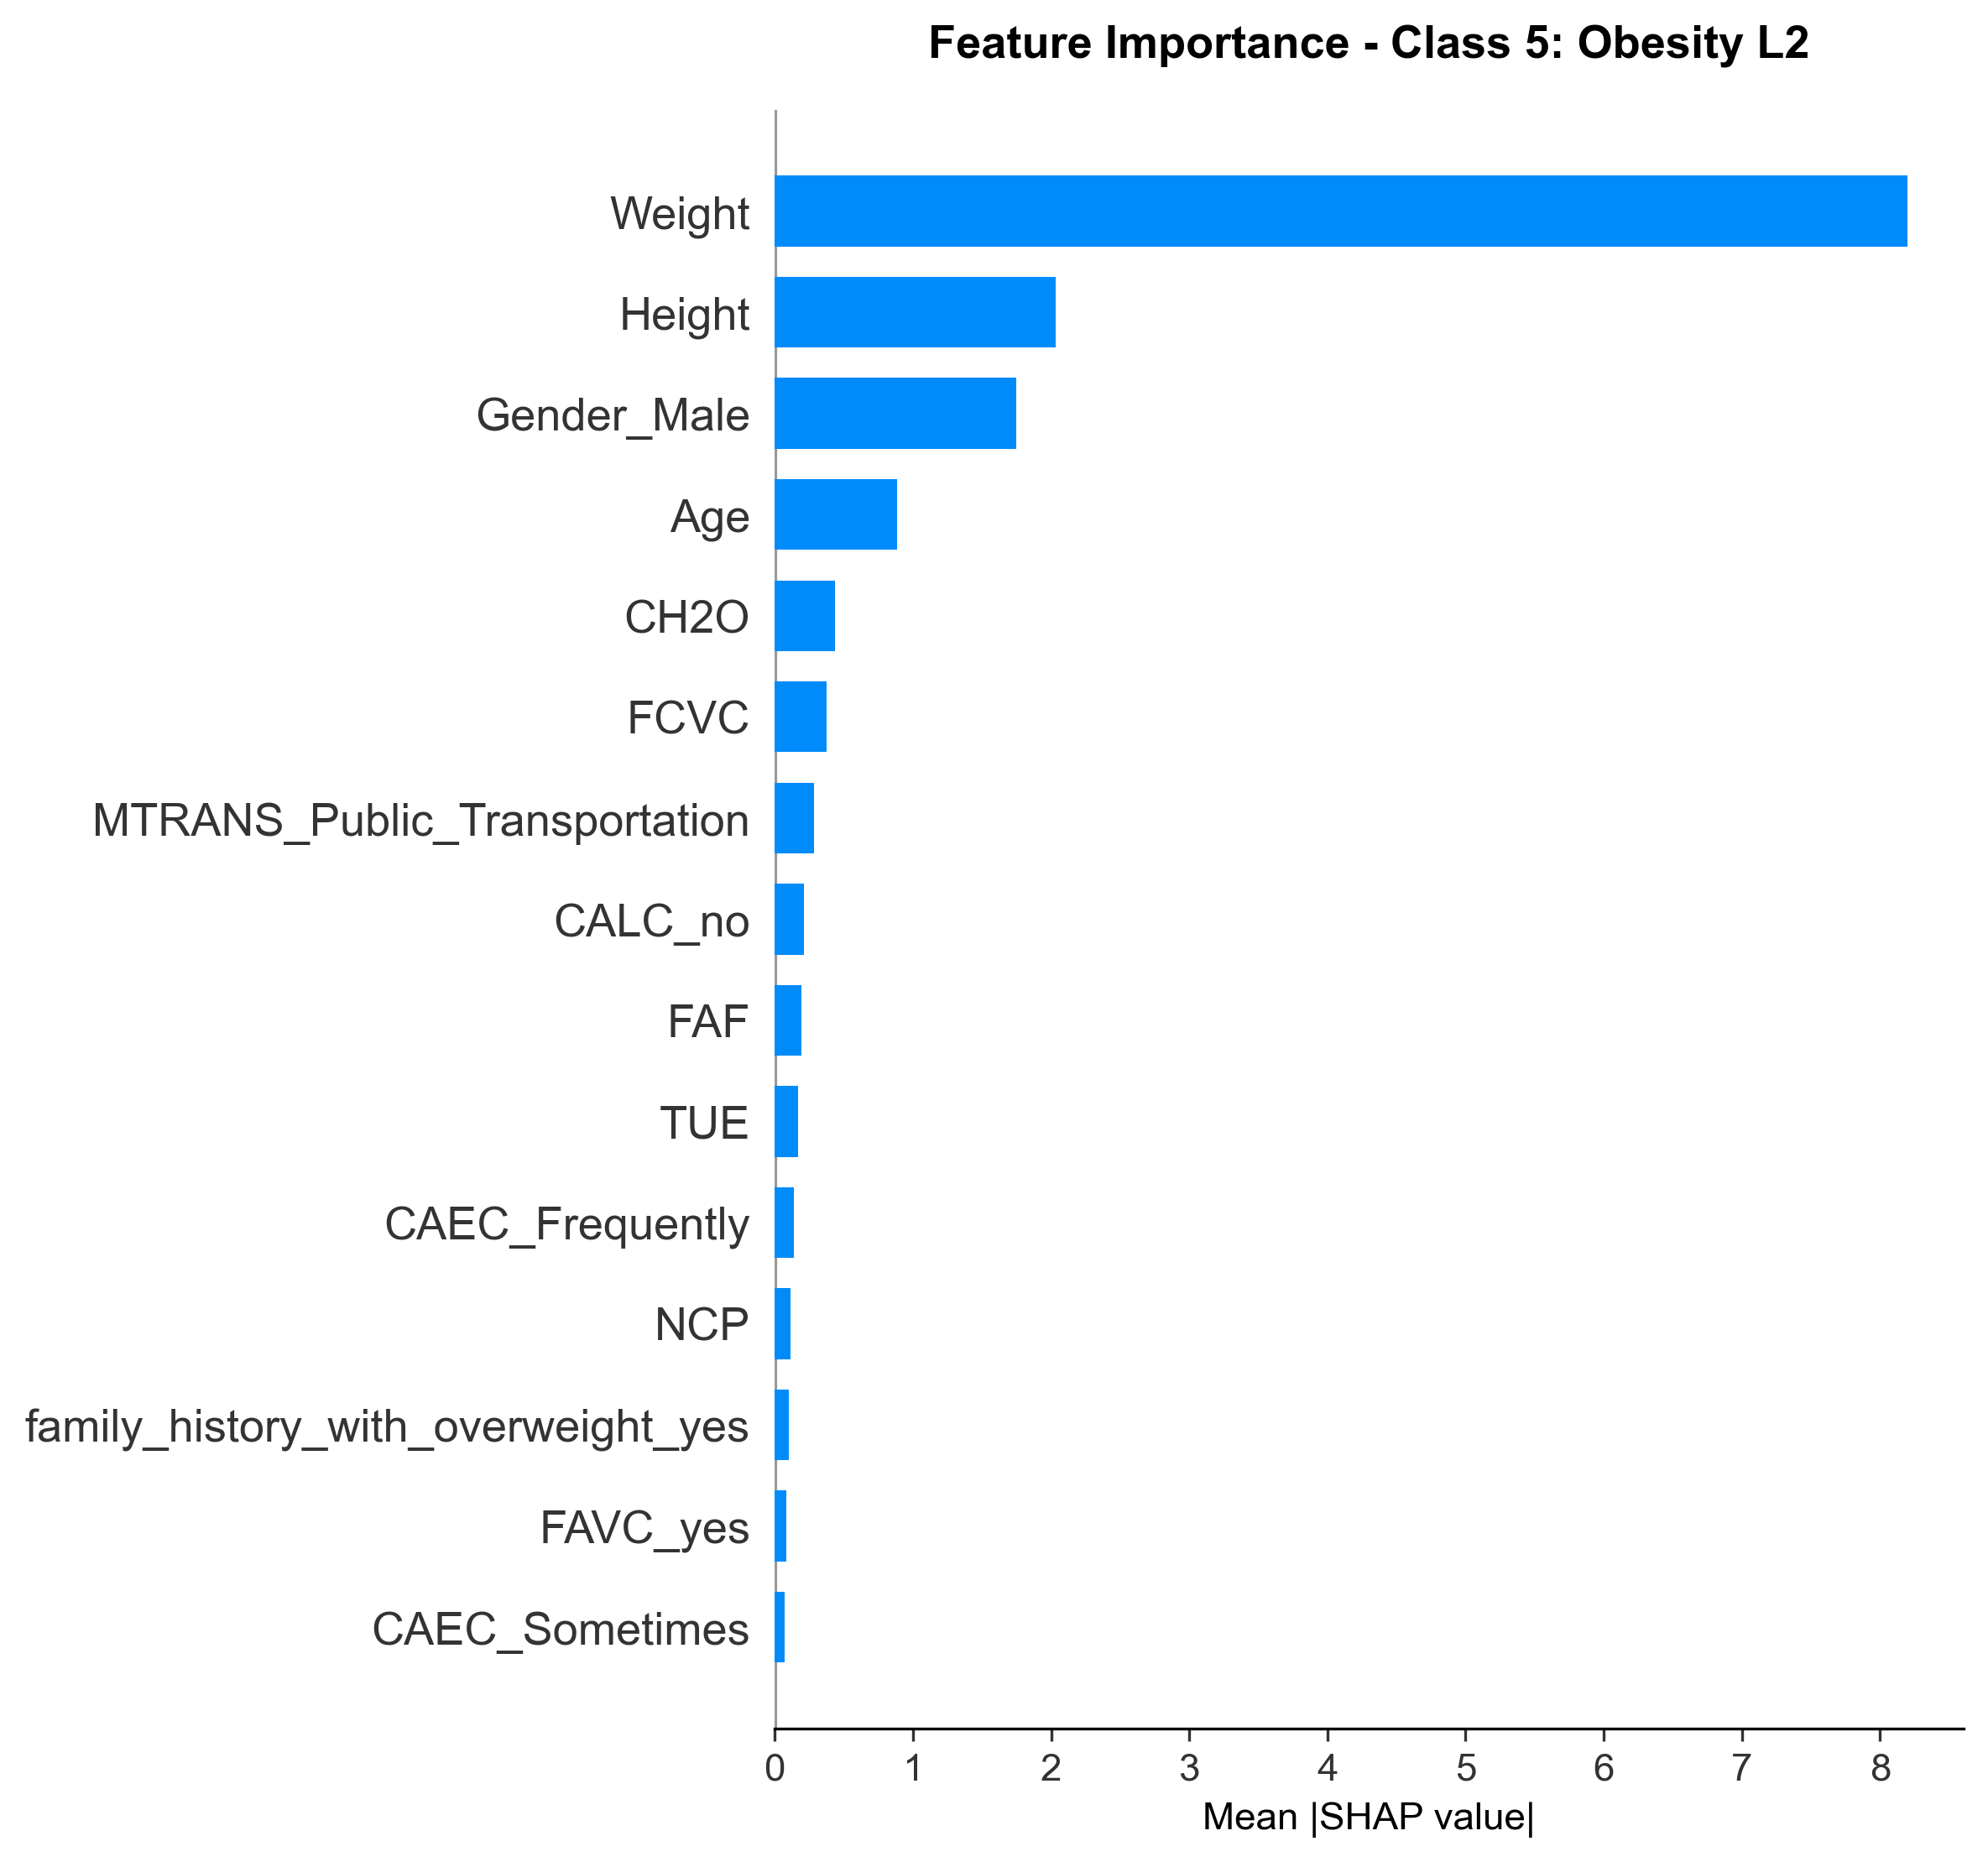

  ✓ Saved: shap_class_5_Obesity_L2_bar.png

Processing Class 6: Obesity L3


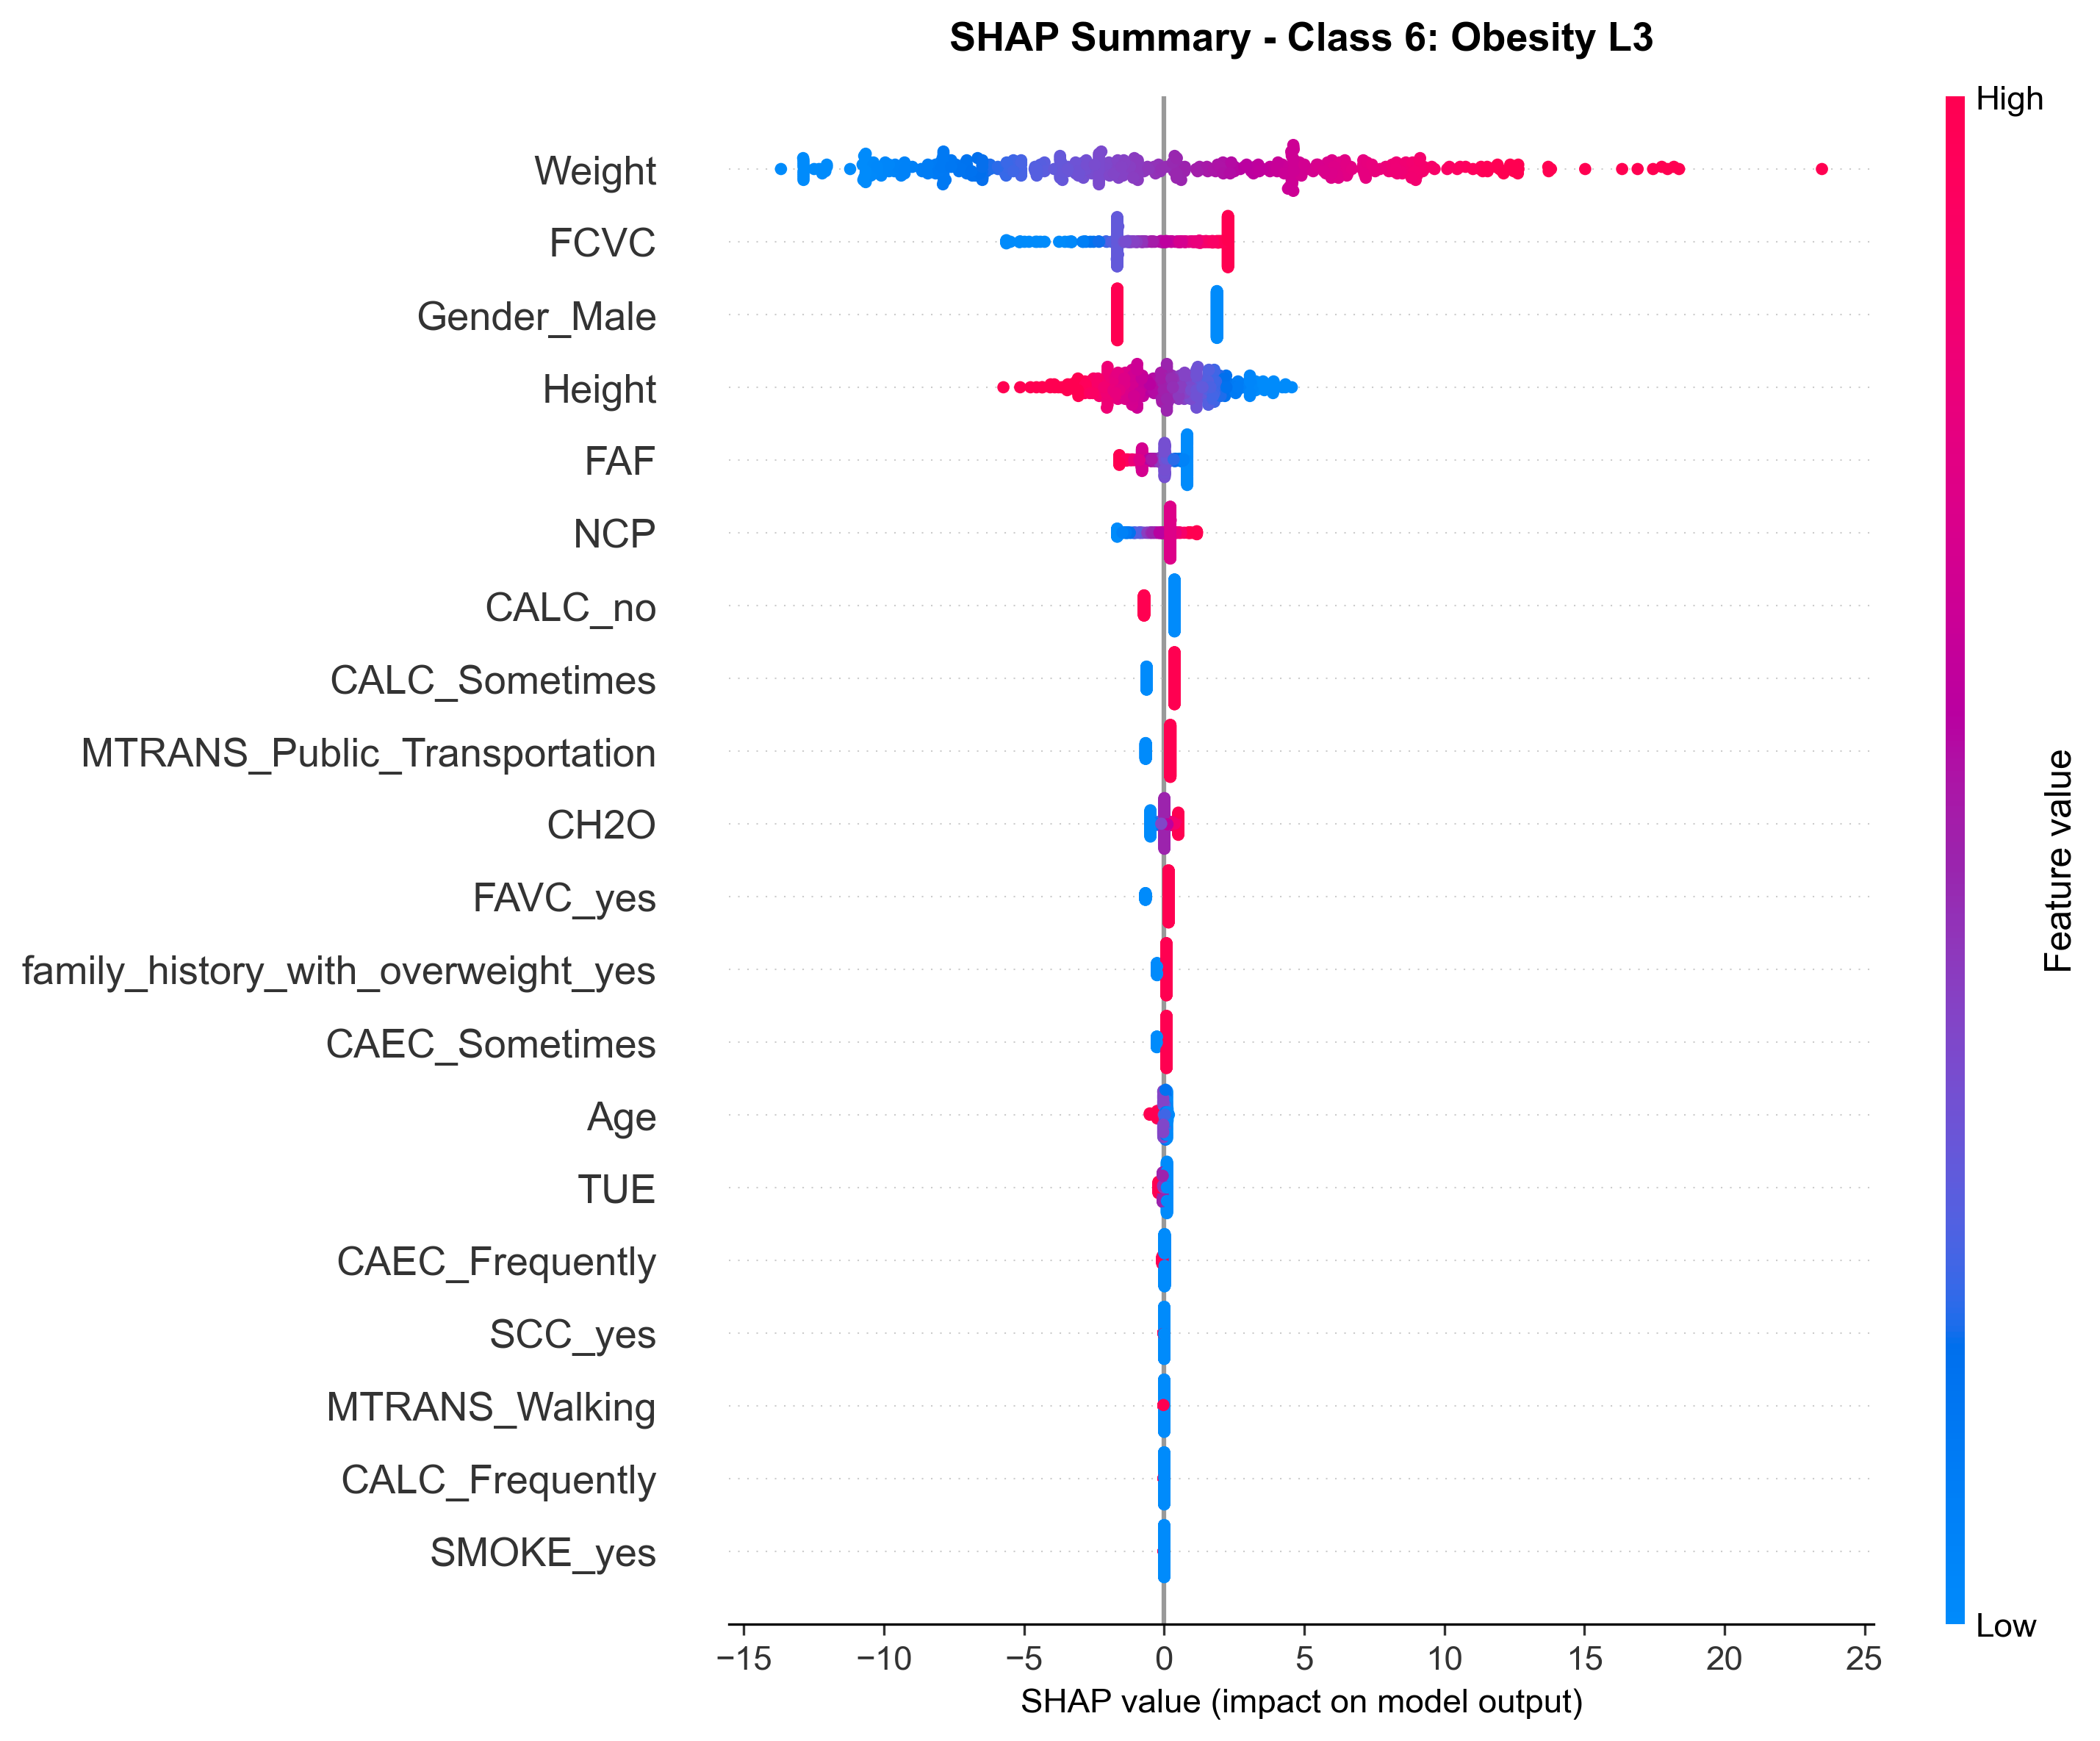

  ✓ Saved: shap_class_6_Obesity_L3_summary.png


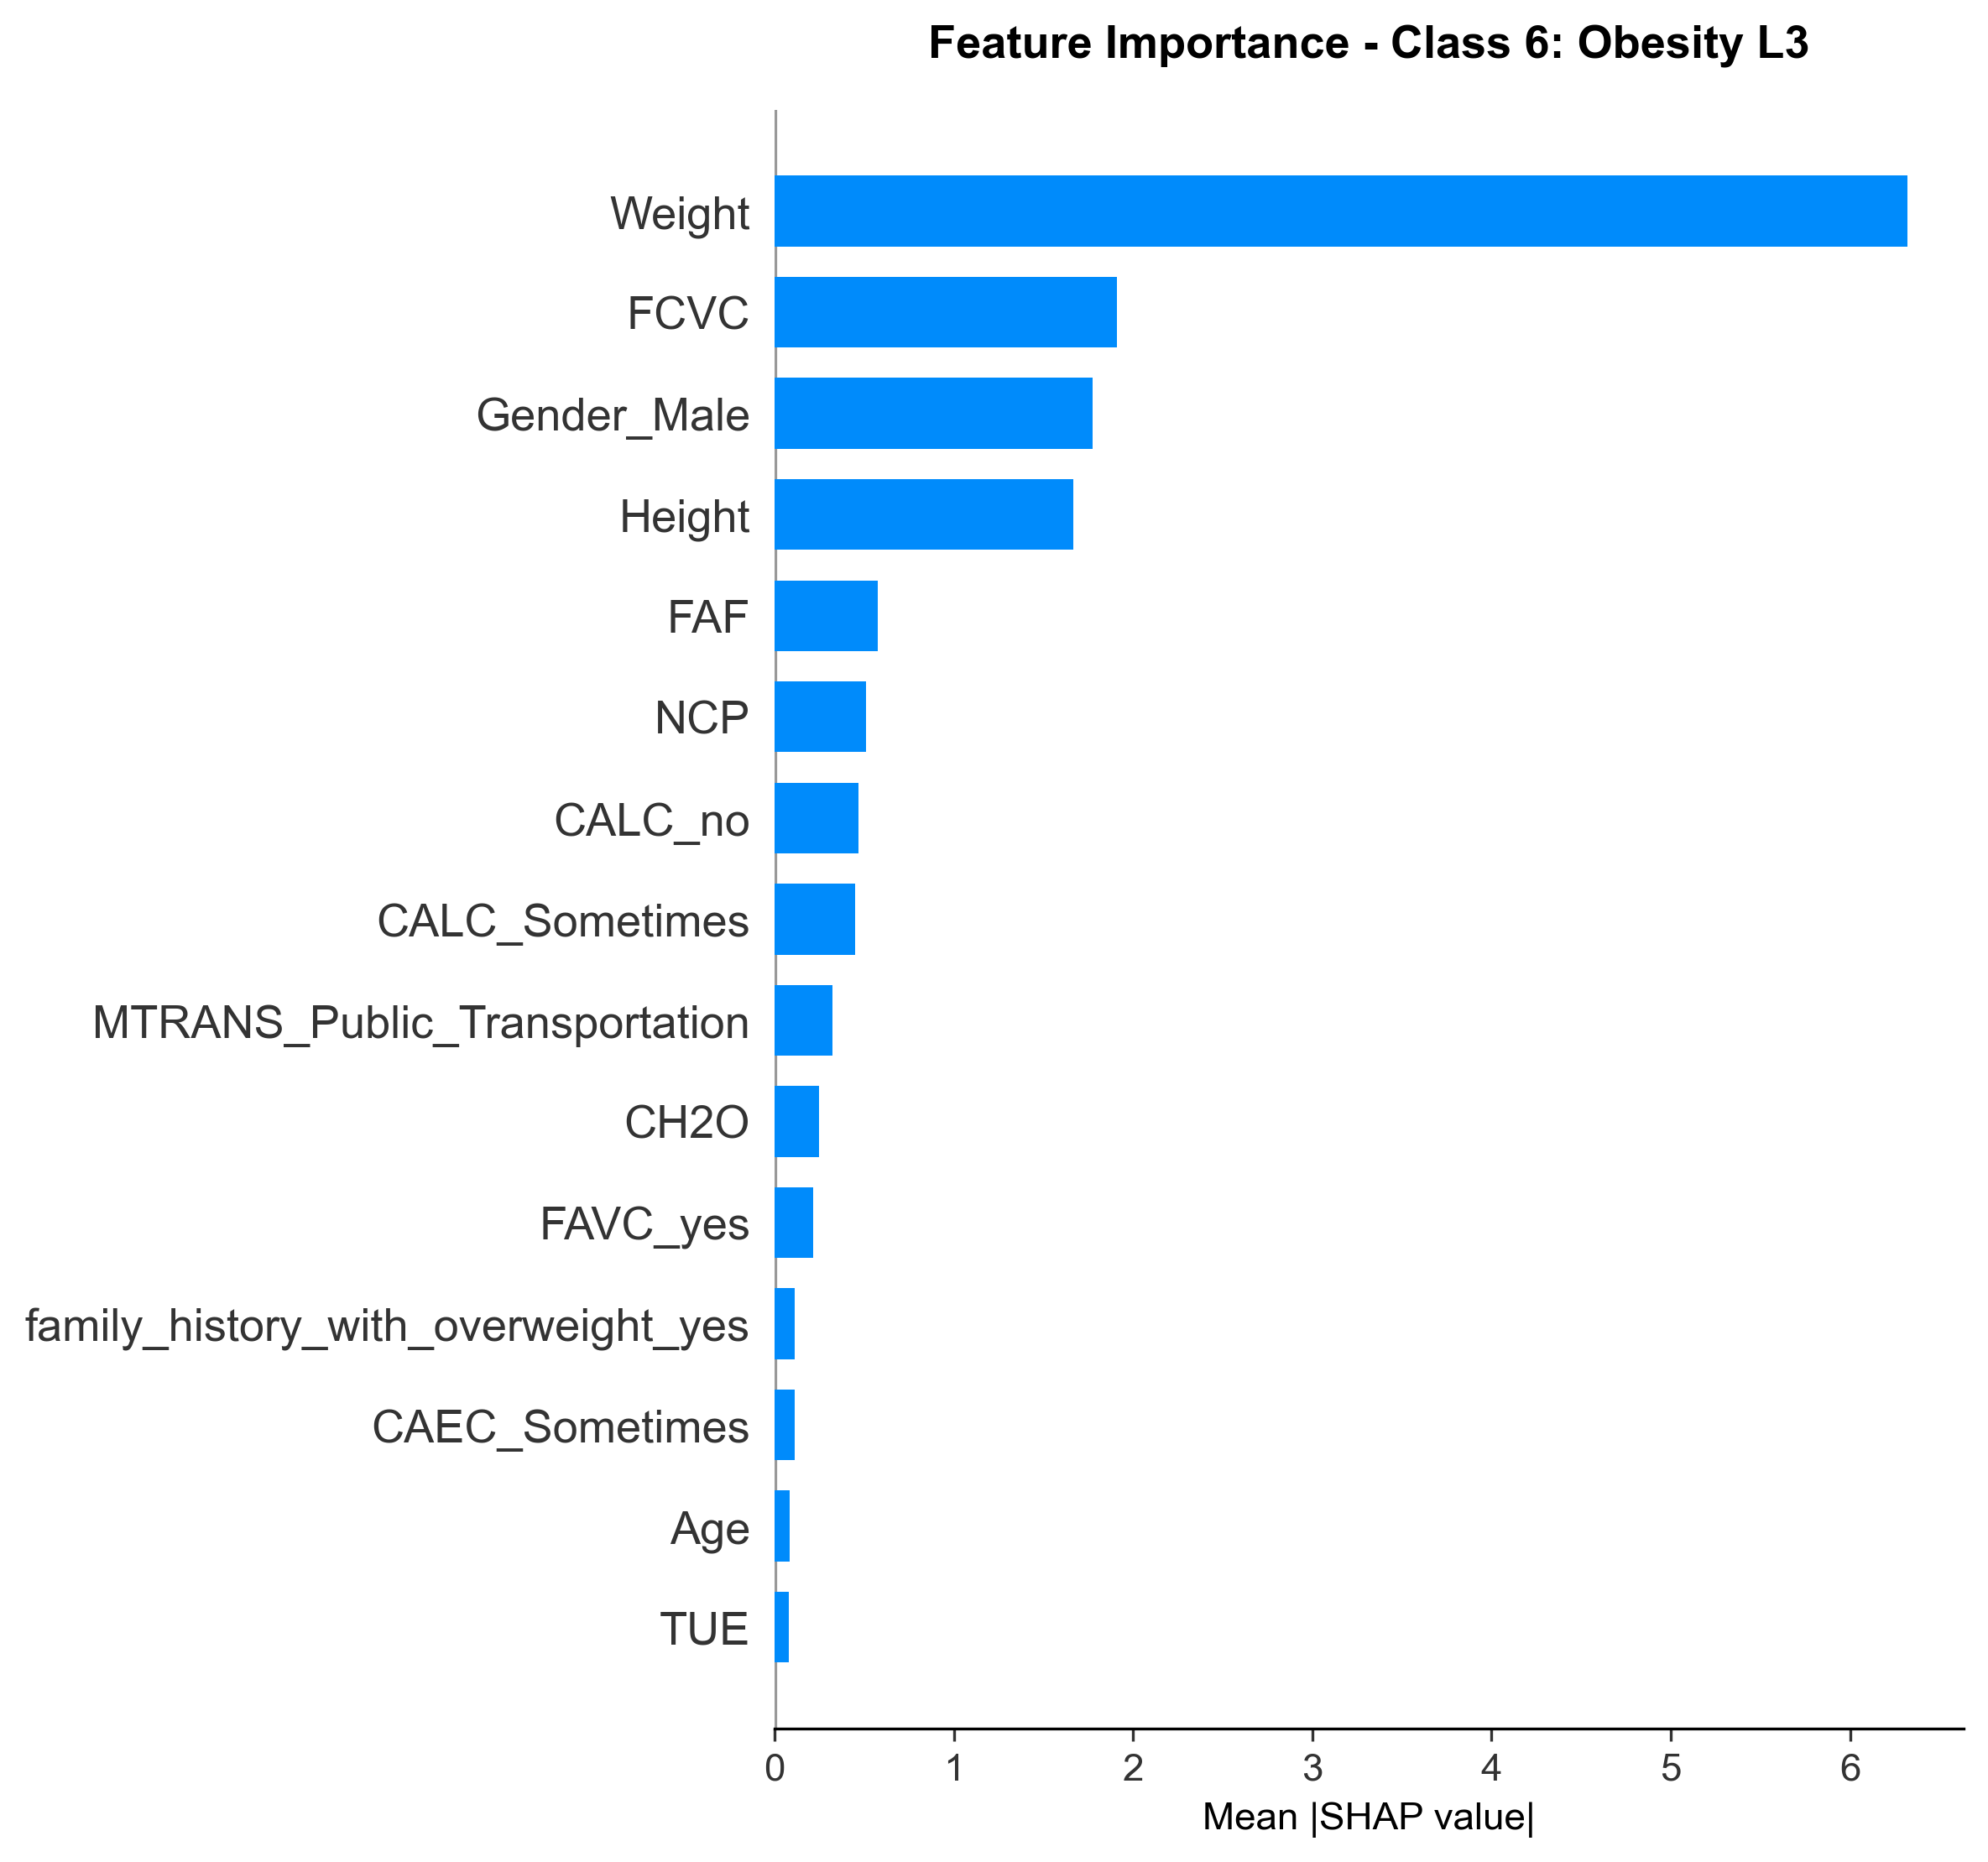

  ✓ Saved: shap_class_6_Obesity_L3_bar.png


In [28]:
print("\n" + "="*80)
print("GENERATING PER-CLASS SHAP PLOTS")
print("="*80)

for class_idx, class_name in enumerate(class_names):
    print(f"\nProcessing Class {class_idx}: {class_name}")
    
    # Beeswarm plot for this class
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(
        shap_values_list[class_idx],
        X_test_df,
        feature_names=feature_names,
        show=False,
        max_display=20,
        plot_size=(10, 8)
    )
    plt.title(f'SHAP Summary - Class {class_idx}: {class_name}', 
             fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('SHAP value (impact on model output)', fontsize=11)
    plt.tight_layout()
    filename = f'shap_class_{class_idx}_{class_name.replace(" ", "_")}_summary.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {filename}")
    
    # Bar plot for this class (top features)
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(
        shap_values_list[class_idx],
        X_test_df,
        feature_names=feature_names,
        plot_type="bar",
        show=False,
        max_display=15
    )
    plt.title(f'Feature Importance - Class {class_idx}: {class_name}', 
             fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Mean |SHAP value|', fontsize=11)
    plt.tight_layout()
    filename = f'shap_class_{class_idx}_{class_name.replace(" ", "_")}_bar.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {filename}")

### 2.10.7 Per Class top features

In [29]:
print("\n" + "="*80)
print("TOP 5 FEATURES PER CLASS (by mean absolute SHAP)")
print("="*80)

summary_data = []
for class_idx, class_name in enumerate(class_names):
    mean_abs_shap = np.abs(shap_values_list[class_idx]).mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[-5:][::-1]
    
    print(f"\n{class_name} (Class {class_idx}):")
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}. {feature_names[idx]}: {mean_abs_shap[idx]:.4f}")
        summary_data.append({
            'Class': class_name,
            'Rank': rank,
            'Feature': feature_names[idx],
            'Mean_|SHAP|': mean_abs_shap[idx]
        })

# Create summary DataFrame
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('shap_top_features_summary.csv', index=False)
print(f"\n✓ Saved: shap_top_features_summary.csv")



TOP 5 FEATURES PER CLASS (by mean absolute SHAP)

Underweight (Class 0):
  1. Weight: 10.5494
  2. Height: 2.7854
  3. Age: 0.6368
  4. CAEC_Frequently: 0.3955
  5. family_history_with_overweight_yes: 0.2725

Healthy (Class 1):
  1. Weight: 5.7610
  2. Height: 1.4389
  3. CAEC_Sometimes: 0.5076
  4. FAF: 0.3006
  5. FCVC: 0.2473

Overweight L1 (Class 2):
  1. Weight: 2.3175
  2. Height: 0.8384
  3. FCVC: 0.4218
  4. MTRANS_Public_Transportation: 0.2509
  5. Age: 0.2444

Overweight L2 (Class 3):
  1. Gender_Male: 0.4667
  2. Age: 0.3506
  3. FAVC_yes: 0.3151
  4. FCVC: 0.3026
  5. family_history_with_overweight_yes: 0.2940

Obesity L1 (Class 4):
  1. Weight: 4.1809
  2. Height: 1.4805
  3. FCVC: 0.6014
  4. FAVC_yes: 0.2836
  5. CH2O: 0.2650

Obesity L2 (Class 5):
  1. Weight: 8.1952
  2. Height: 2.0337
  3. Gender_Male: 1.7505
  4. Age: 0.8833
  5. CH2O: 0.4328

Obesity L3 (Class 6):
  1. Weight: 6.3185
  2. FCVC: 1.9106
  3. Gender_Male: 1.7720
  4. Height: 1.6665
  5. FAF: 0.5754

✓

### 2.10.8. Dependence plots for top features


BONUS: Creating dependence plots for most important features

Top 3 most important features globally:
  1. Weight: 5.3413
  2. Height: 1.4802
  3. Gender_Male: 0.6896

Creating dependence plot for: Weight


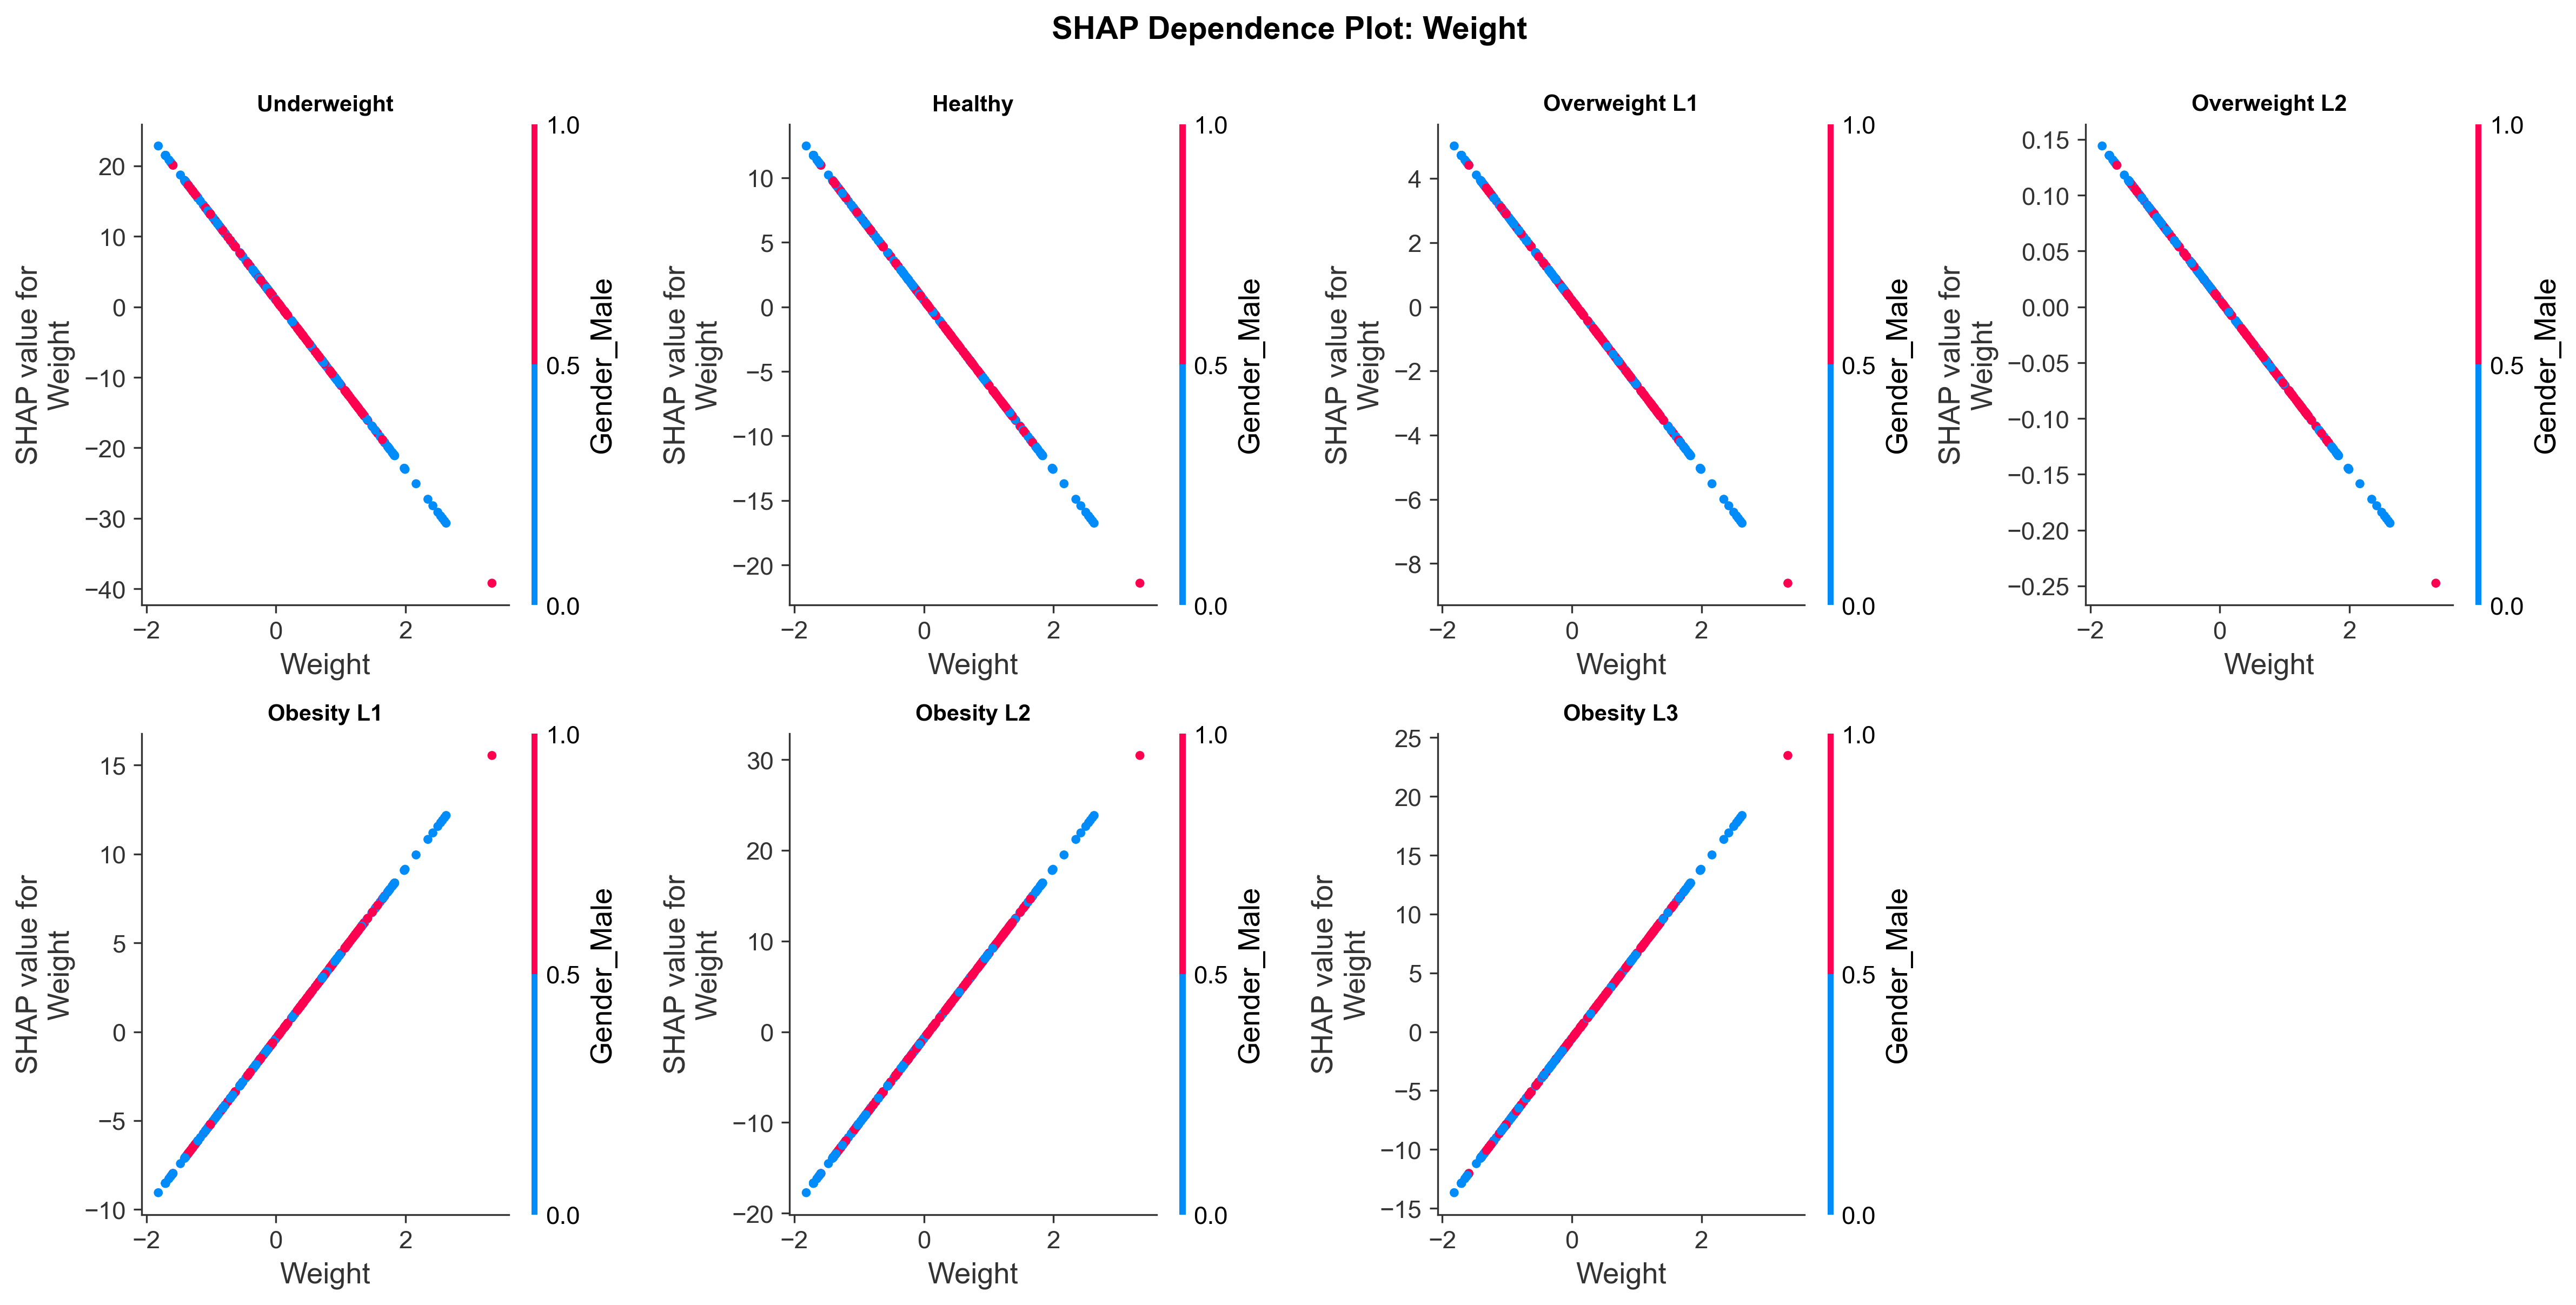

  ✓ Saved: shap_dependence_Weight.png

Creating dependence plot for: Height


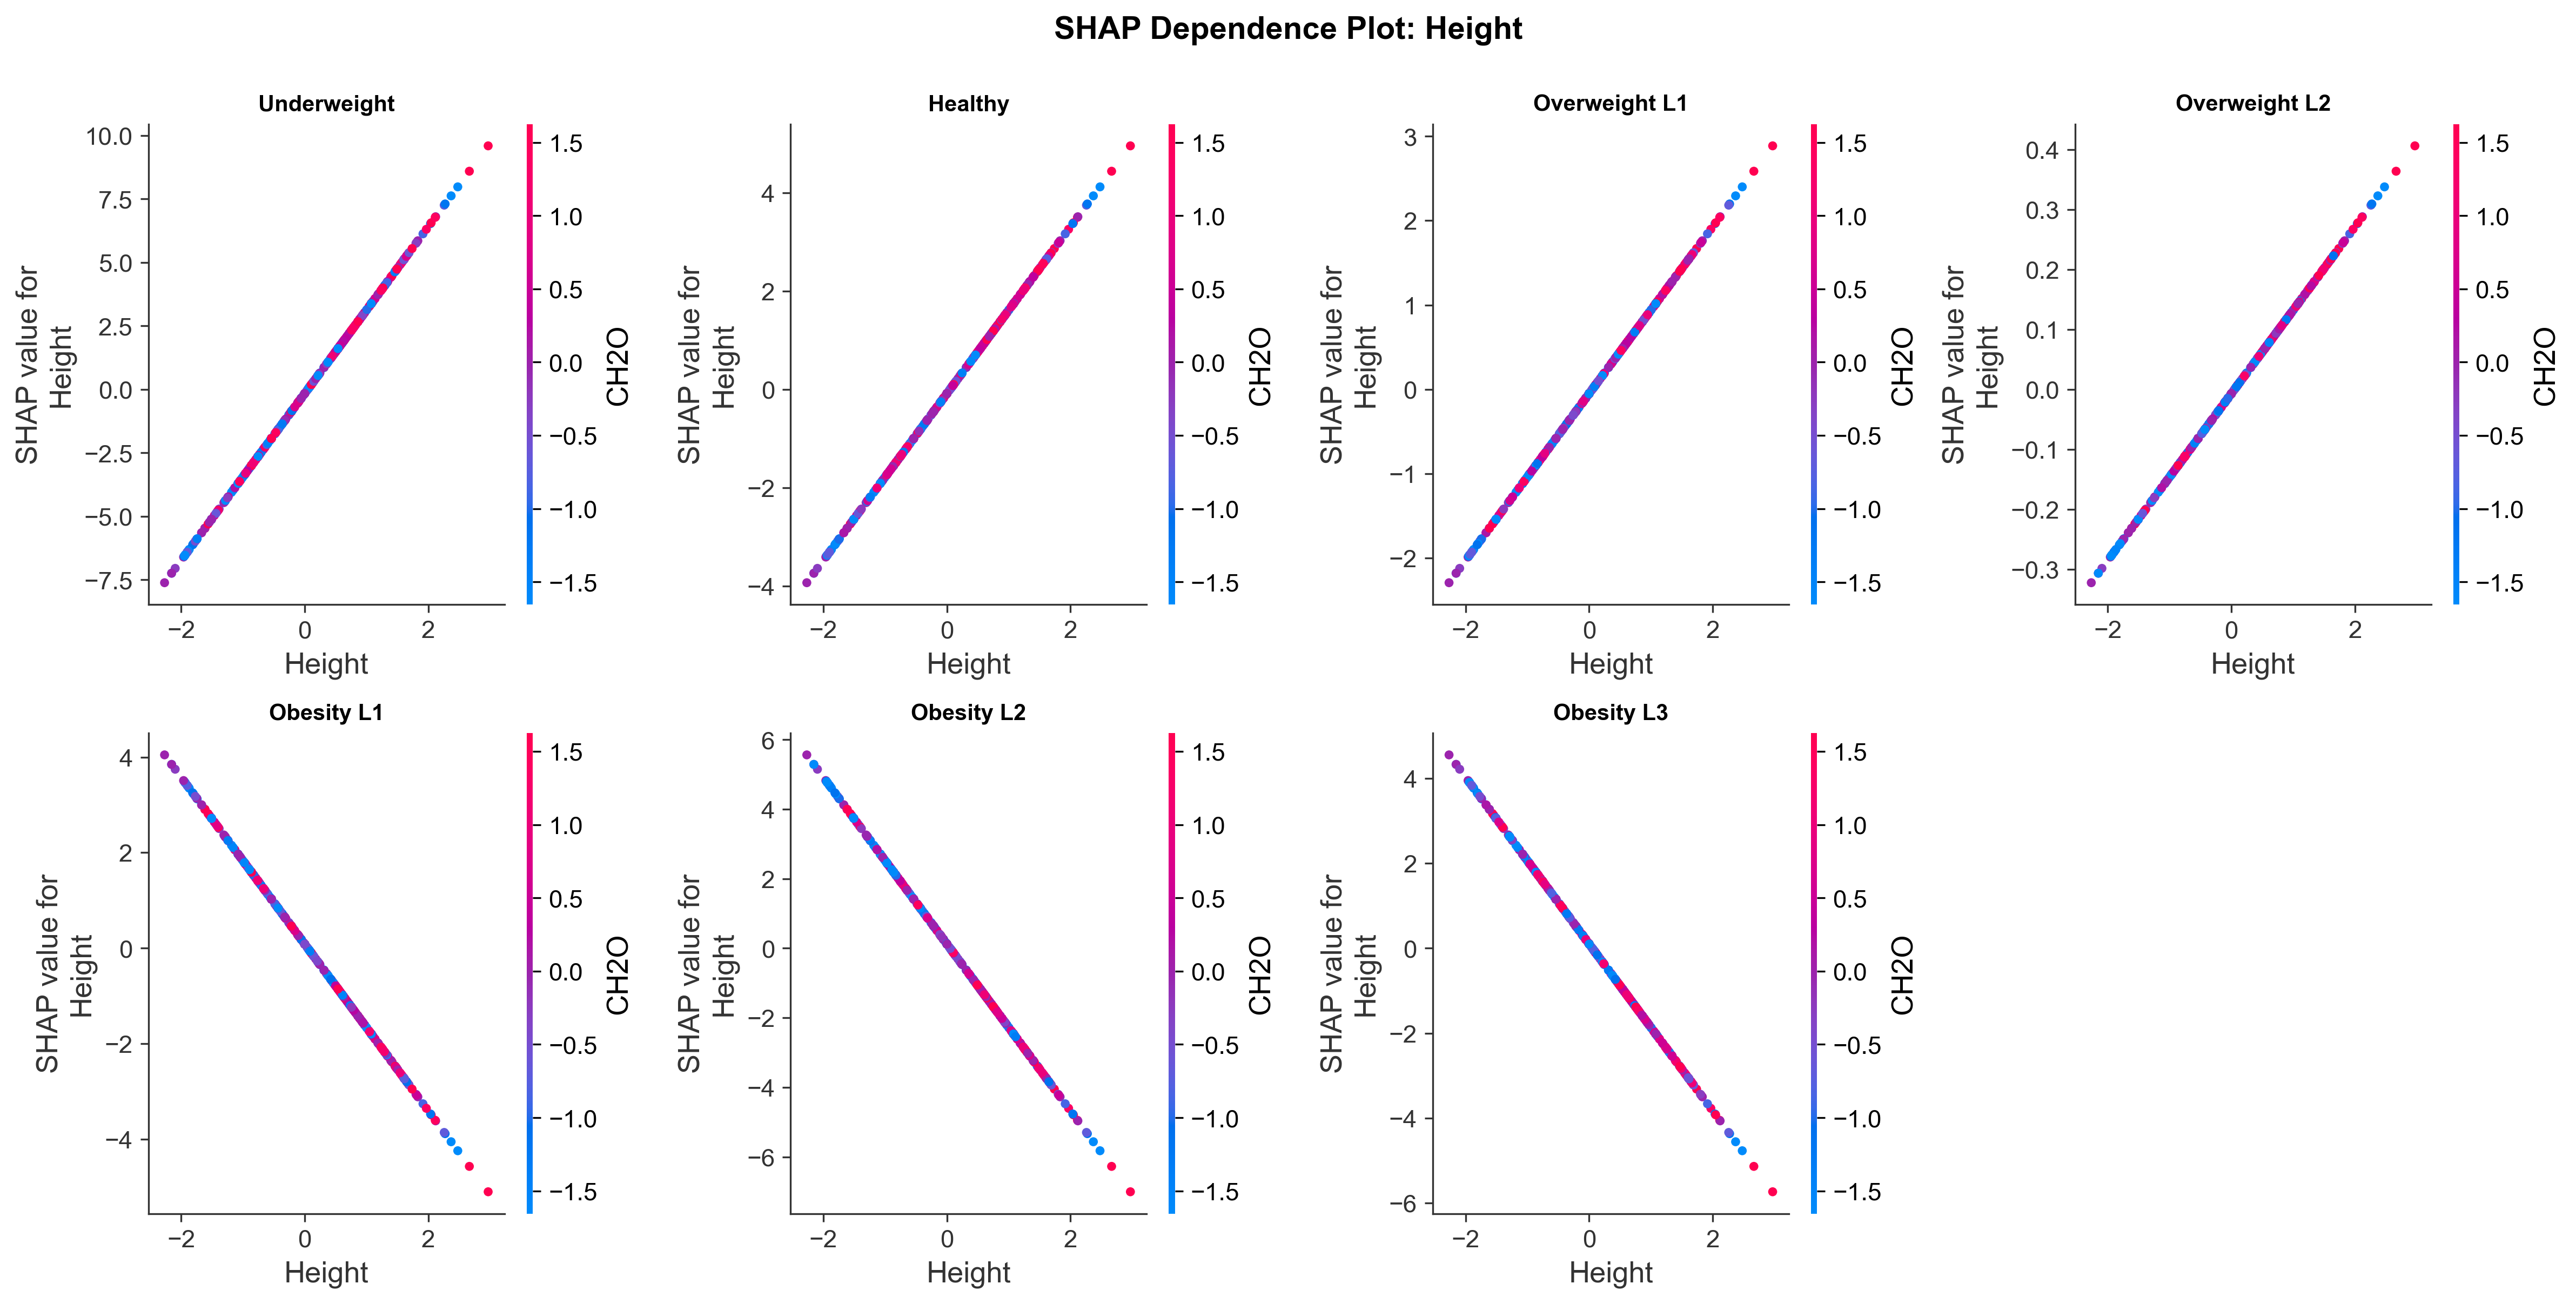

  ✓ Saved: shap_dependence_Height.png

Creating dependence plot for: Gender_Male


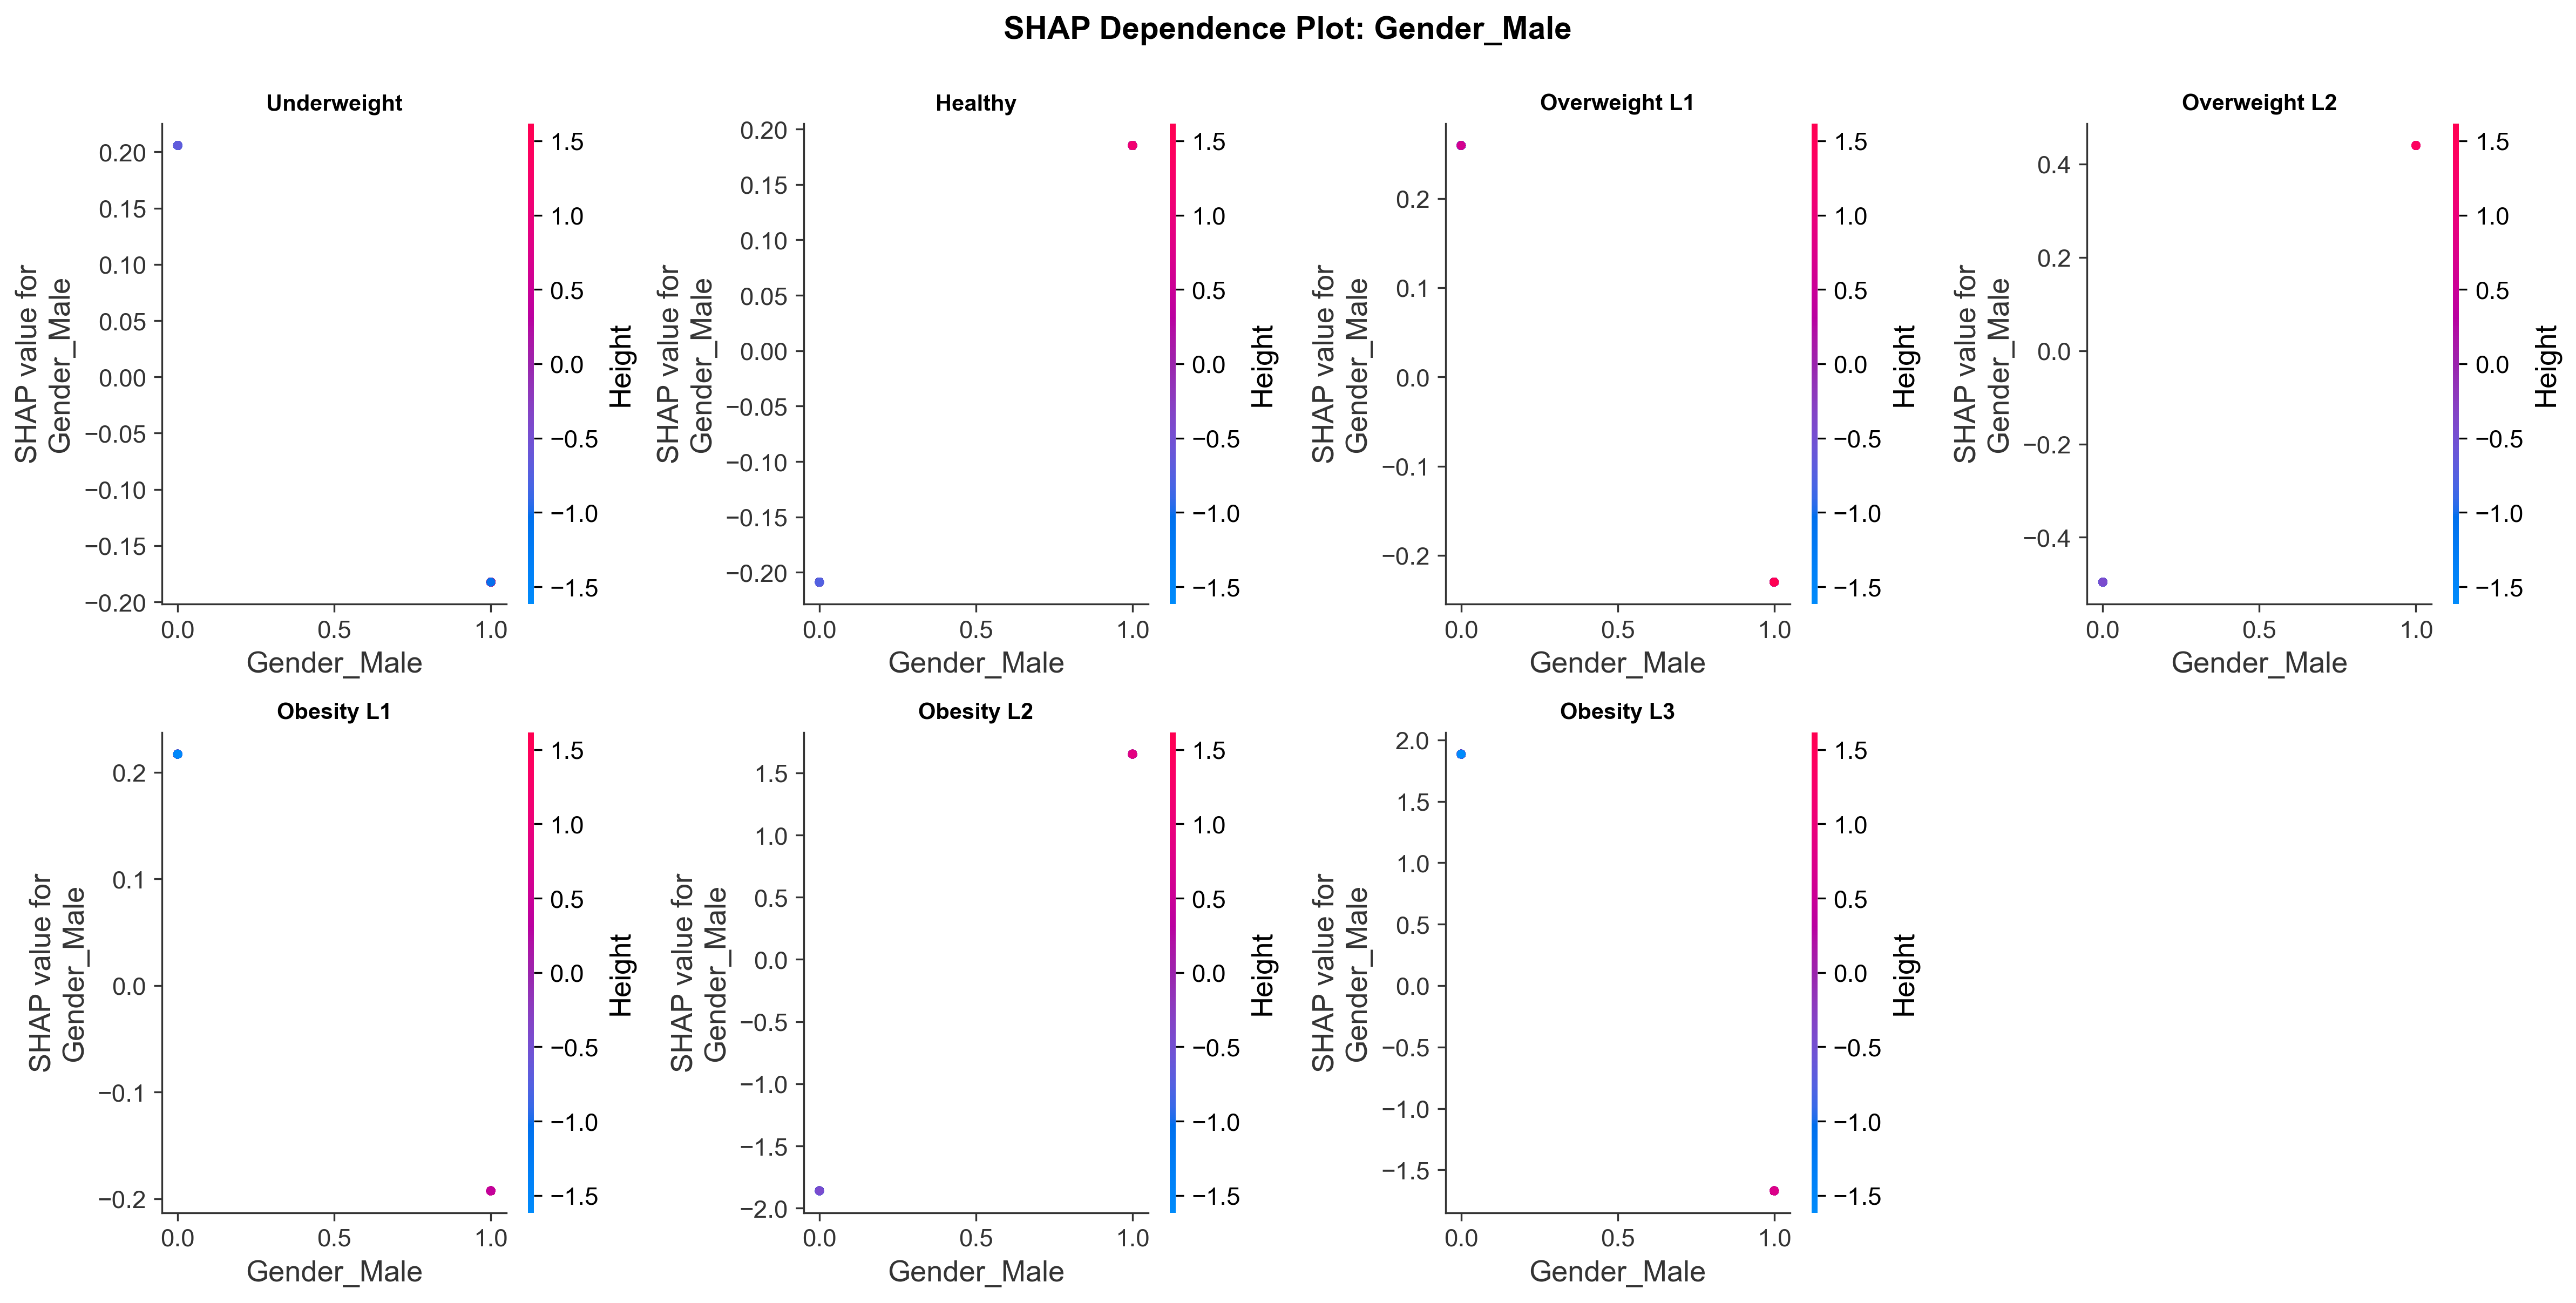

  ✓ Saved: shap_dependence_Gender_Male.png

SHAP ANALYSIS COMPLETE!

Generated files:
  • shap_global_summary.png
  • shap_global_importance_bar.png
  • shap_class_[0-6]_[ClassName]_summary.png (7 files)
  • shap_class_[0-6]_[ClassName]_bar.png (7 files)
  • shap_top_features_summary.csv
  • shap_dependence_[FeatureName].png (3 files)

Total: 20 publication-grade visualizations + 1 CSV summary


In [30]:
print("\n" + "="*80)
print("BONUS: Creating dependence plots for most important features")
print("="*80)

# Find globally most important features
# Calculate mean absolute SHAP value across all classes and all samples
# Stack all classes: each is (n_samples, n_features), stack to (n_classes, n_samples, n_features)
stacked_shap = np.stack(shap_values_list, axis=0)  # (7, 423, 23)
# Take mean absolute value across classes and samples
global_importance = np.abs(stacked_shap).mean(axis=(0, 1))  # (23,)
top_3_features = np.argsort(global_importance)[-3:][::-1]

print(f"\nTop 3 most important features globally:")
for i, feat_idx in enumerate(top_3_features, 1):
    print(f"  {i}. {feature_names[feat_idx]}: {global_importance[feat_idx]:.4f}")

for feat_idx in top_3_features:
    feat_name = feature_names[feat_idx]
    print(f"\nCreating dependence plot for: {feat_name}")
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for class_idx, class_name in enumerate(class_names):
        shap.dependence_plot(
            feat_idx,
            shap_values_list[class_idx],
            X_test_df,
            feature_names=feature_names,
            show=False,
            ax=axes[class_idx]
        )
        axes[class_idx].set_title(f'{class_name}', fontsize=10, fontweight='bold')
    
    # Hide the extra subplot
    axes[7].axis('off')
    
    plt.suptitle(f'SHAP Dependence Plot: {feat_name}', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    filename = f'shap_dependence_{feat_name.replace(" ", "_")}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {filename}")

print("\n" + "="*80)
print("SHAP ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  • shap_global_summary.png")
print("  • shap_global_importance_bar.png")
print("  • shap_class_[0-6]_[ClassName]_summary.png (7 files)")
print("  • shap_class_[0-6]_[ClassName]_bar.png (7 files)")
print("  • shap_top_features_summary.csv")
print("  • shap_dependence_[FeatureName].png (3 files)")
print(f"\nTotal: 20 publication-grade visualizations + 1 CSV summary")